(mmm_time_varying_media_example)=
# MMM with time-varying media baseline
## Introduction
In the domain of Marketing Mix Modeling (MMM), understanding the impact of various marketing activities on a target variable and other key performance indicators is crucial. Traditional regression models often neglect the temporal dynamics of marketing activities, potentially leading to biased or incomplete insights. This notebook aims to showcase the difference between a conventional regression model that does not account for time variation and a more sophisticated model that incorporates time as a key component through a Gaussian process.
The objective is to determine the contribution of each marketing activity to the overall target variable or desired outcome. This process typically involves two critical transformations:
1. **Saturation Function**: This function models the diminishing returns of marketing inputs. As more resources are allocated to a specific channel, the incremental benefit tends to decrease.
   
2. **Adstock Function**: This function captures the carryover effect of marketing activities over time, recognizing that the impact of a marketing effort extends beyond the immediate period in which it occurs.
The standard approach in MMM applies these transformations to the marketing inputs, resulting in a contribution to the outcome.
## Time-Dependent MMM Model
In real-world scenarios, the effectiveness of marketing activities is not static but varies over time due to factors like competitive actions, and market dynamics. To account for this, we introduce a time-dependent component into the MMM framework using a Gaussian Process, specifically a [Hilbert Space GP](https://www.pymc.io/projects/docs/en/stable/api/gp/generated/pymc.gp.HSGP.html). This allows us to capture the hidden latent temporal variation of the marketing contributions.
## Model Specification
In `pymc-marketing` we provide an API for a Bayesian media mix model (MMM) specification following [Jin, Yuxue, et al. “Bayesian methods for media mix modeling with carryover and shape effects.” (2017)](https://research.google/pubs/pub46001/) as a base model. Concretely, given a time series target variable $y_{t}$ (e.g. sales or conversions), media variables $x_{m, t}$ (e.g. impressions, clicks or costs) and a set of control covariates $z_{c, t}$ (e.g. holidays, special events) we consider a linear model of the form 
$$
y_{t} = \alpha + \sum_{m=1}^{M}\beta_{m}f(x_{m, t}) +  \sum_{c=1}^{C}\gamma_{c}z_{c, t} + \varepsilon_{t},
$$
where $\alpha$ is the intercept, $f$ is a media transformation function and $\varepsilon_{t}$ is the error term which we assume is normally distributed. The function $f$ encodes the contribution of media on the target variable. Typically we consider two types of transformation: adstock (carry-over) and saturation effects.
When `time_media_varying` is set to `True`, we capture a single latent process that multiplies all channels. We assume all channels share the same time-dependent fluctuations, contrasting with implementations where each channel has an independent latent process. The modified model can be represented as:
$$
y_{t} = \alpha + \lambda_{t} \cdot \sum_{m=1}^{M}\beta_{m}f(x_{m, t}) \ +  \sum_{c=1}^{C}\gamma_{c}z_{c, t} + \varepsilon_{t},
$$
where $\lambda_{t}$ is the time-varying component modeled as a latent process. This shared time-dependent variation $\lambda_{t}$ allows us to capture the overall temporal effects that influence all media channels simultaneously.
## Objective
This notebook will:
1. Illustrate the formulation of a standard MMM model without time variation.
2. Extend the model to include a time component using HSGP.
3. Compare the results and insights derived from both models, highlighting the importance of incorporating time variation in capturing the true impact of marketing activities.
By the end of this notebook, you will have a comprehensive understanding of the advantages of using time-dependent MMM models in capturing the dynamic nature of marketing effectiveness, leading to more accurate and actionable insights.
## Prerequisite Knowledge
The notebook assumes the reader has knowledge of the essential functionalities of PyMC-Marketing. If one is unfamiliar, the ["MMM Example Notebook"](https://www.pymc-marketing.io/en/stable/notebooks/mmm/mmm_example.html) serves as an excellent starting point, offering a comprehensive introduction to media mix models in this context.
---
## Part I: Data Generation Process
In Part I of this notebook we focus on the data generating process. We want to construct the target variable $y_{t}$ (sales) by adding each of the components described in the *Business Problem* section.
> Note: Model components are built out of this notebook, we'll show how they combine together to generate the target.
## Prepare Notebook


In [1]:
import warnings

import arviz as az
import arviz_base
import arviz_plots as azp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pymc_extras.prior import Prior

from pymc_marketing.mmm import MMM, GeometricAdstock, MichaelisMentenSaturation
from pymc_marketing.paths import data_dir

warnings.filterwarnings("ignore")
az.style.use("arviz-vibrant")
plt.rcParams["figure.figsize"] = [12, 7]

arviz_base.rcParams["plot.max_subplots"] = 500
plt.rcParams["figure.dpi"] = 100

%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = "retina"

### 1. Date Range
First we set a time range for our data. We consider a bit more than 2 years of data at weekly granularity.


In [2]:
# Creating variables
seed: int = sum(map(ord, "Time Media Contributions are amazing"))
rng: np.random.Generator = np.random.default_rng(seed=seed)
# date range
min_date = pd.to_datetime("2018-04-01")
max_date = pd.to_datetime("2021-09-01")
df = pd.read_csv(data_dir / "media_tvp_data.csv", index_col=0)
df["date_week"] = pd.to_datetime(df["date_week"])
n = df.shape[0]
print(f"Number of observations: {n}")

Number of observations: 179


### 2. Media Costs Data
Now we generate synthetic data from two channels $x_1$ and $x_2$. We refer to it as the raw signal as it is going to be the input at the modeling phase. We expect the contribution of each channel to be different, based on the carryover and saturation parameters.


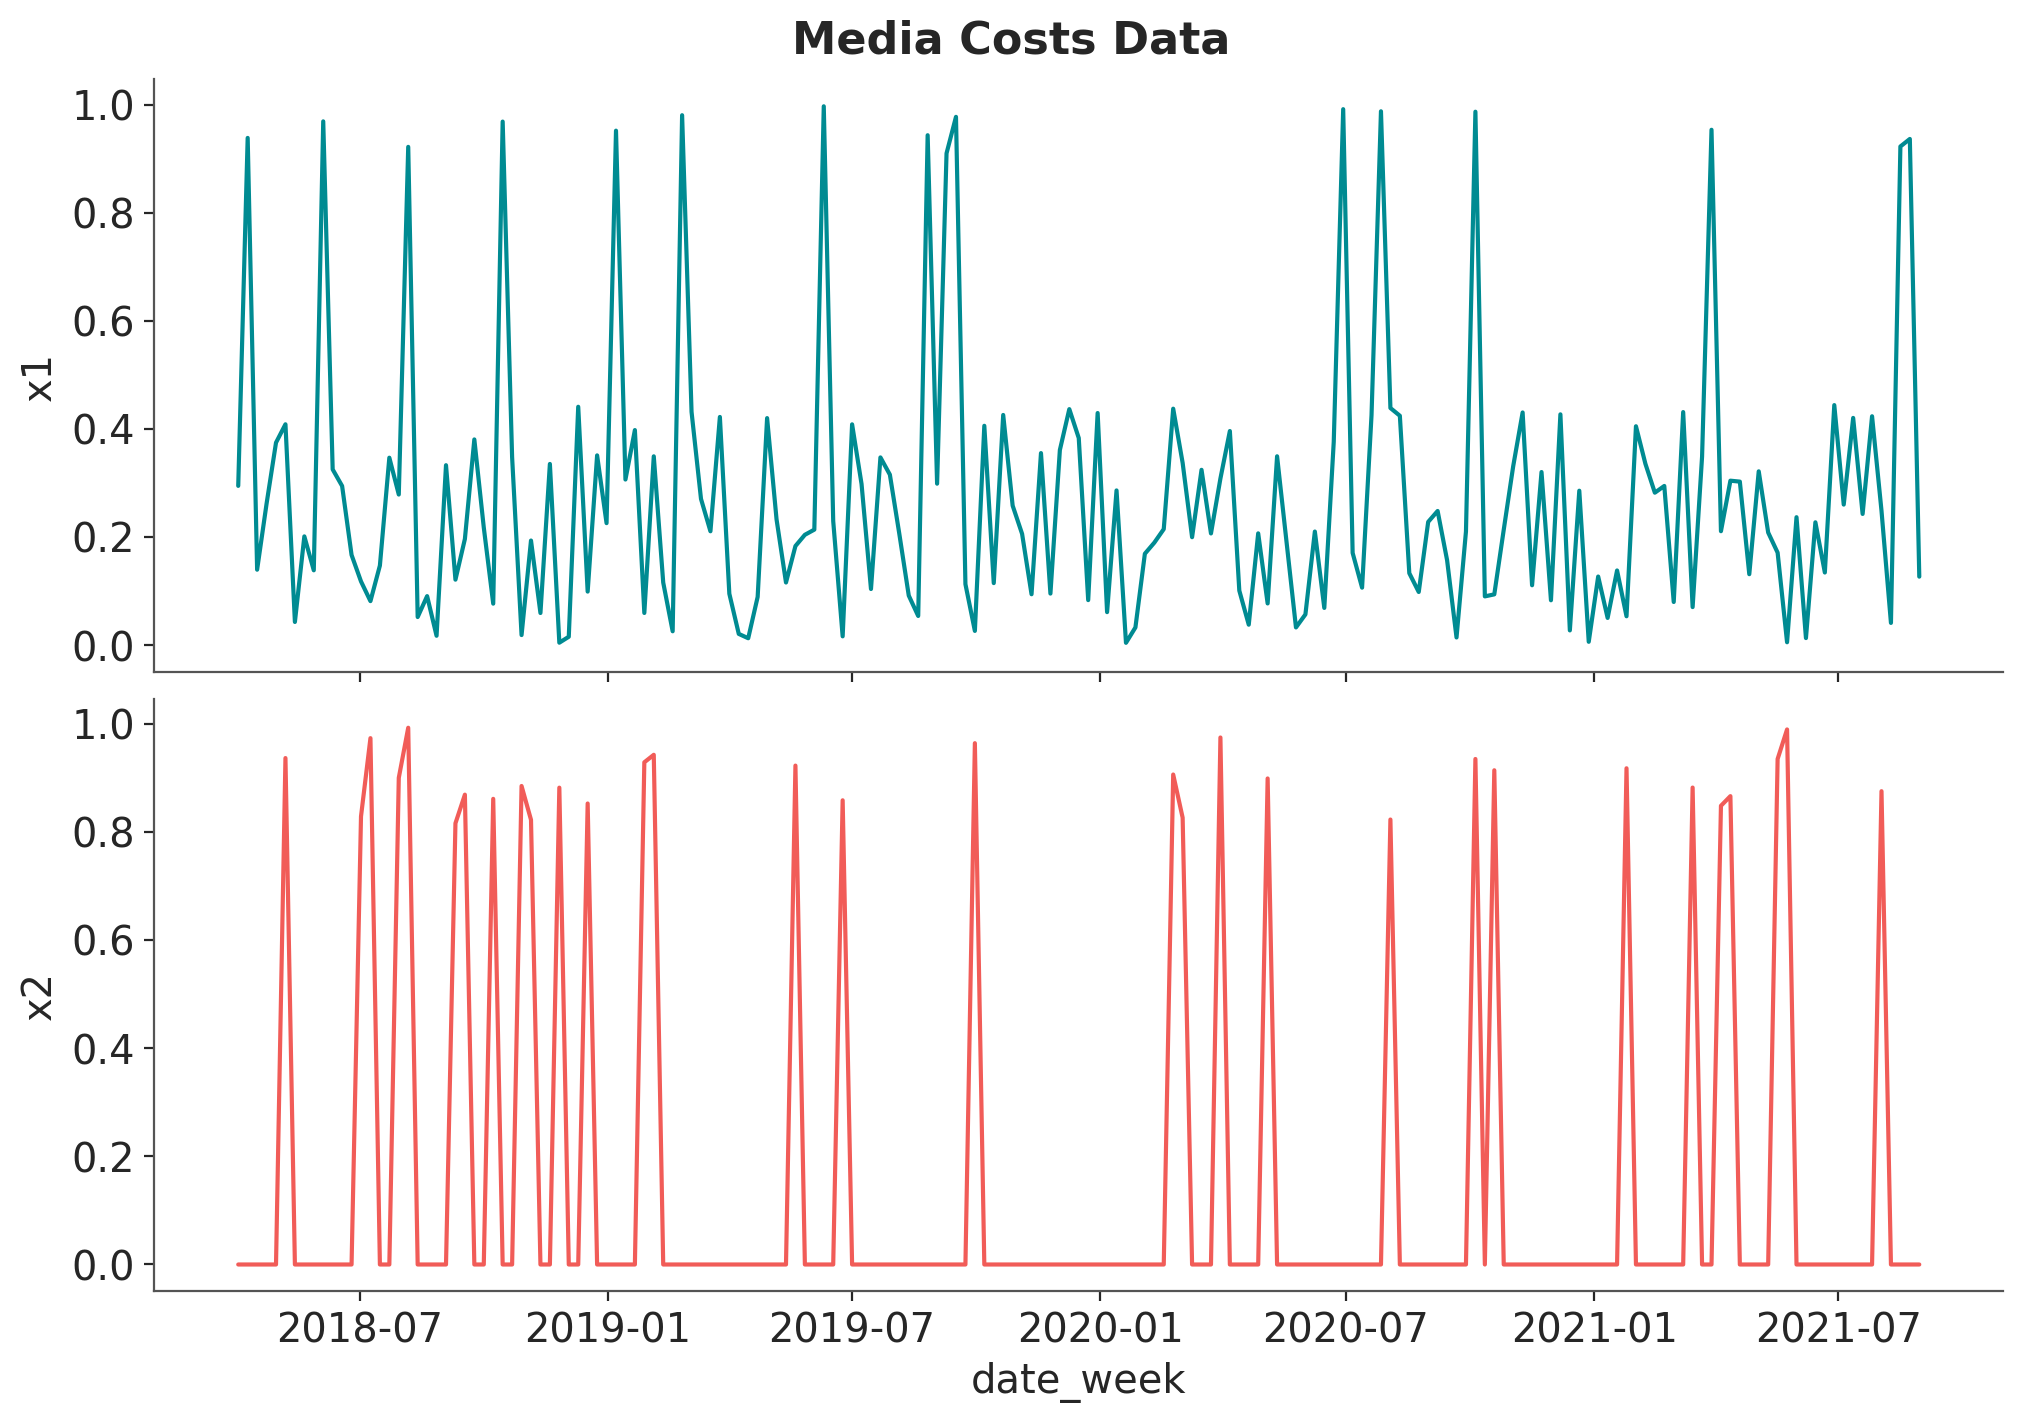

In [3]:
fig, ax = plt.subplots(
    nrows=2, ncols=1, figsize=(10, 7), sharex=True, sharey=True, layout="constrained"
)
sns.lineplot(x="date_week", y="x1", data=df, color="C0", ax=ax[0])
sns.lineplot(x="date_week", y="x2", data=df, color="C1", ax=ax[1])
ax[1].set(xlabel="date_week")
fig.suptitle("Media Costs Data", fontsize=16);

**Remark:** By design, $x_{1}$ should resemble a typical paid social channel and $x_{2}$ a offline (e.g. TV) spend time series.


### 4. Control Variables
We add two *events* where there was a remarkable peak in our target variable. We assume they are independent an not seasonal (e.g. launch of a particular product). 


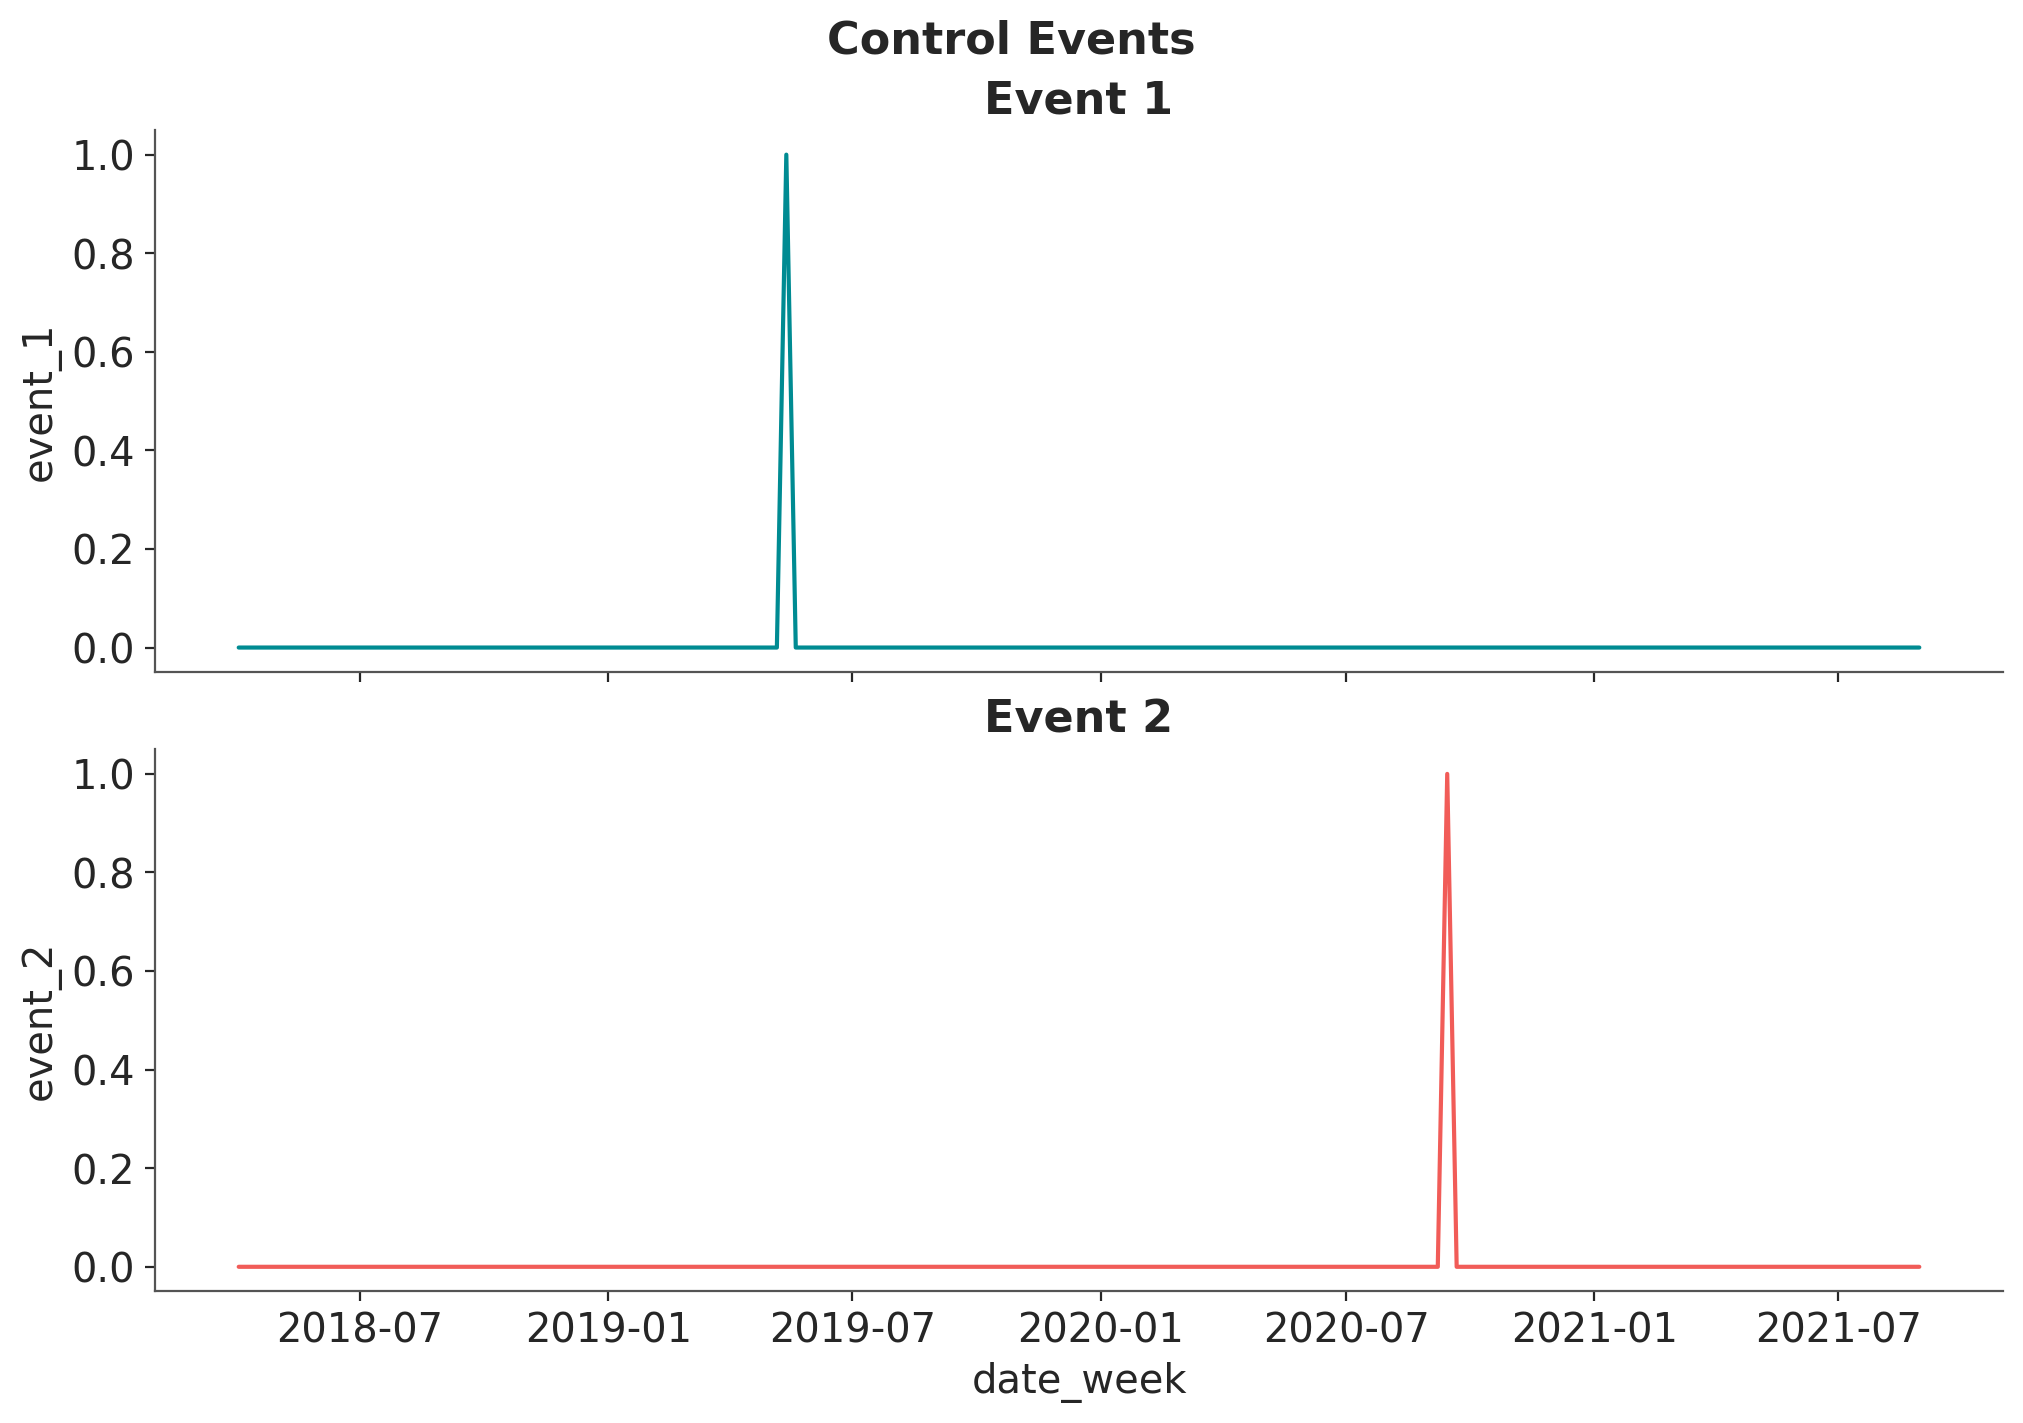

In [4]:
fig, ax = plt.subplots(
    nrows=2, ncols=1, figsize=(10, 7), sharex=True, sharey=True, layout="constrained"
)
sns.lineplot(x="date_week", y="event_1", data=df, color="C0", ax=ax[0])
ax[0].set_title("Event 1")
sns.lineplot(x="date_week", y="event_2", data=df, color="C1", ax=ax[1])
ax[1].set_title("Event 2")
ax[1].set(xlabel="date_week")
fig.suptitle("Control Events", fontsize=16);

### 5. Temporal Hidden Latent Process
To illustrate the impact of time-varying media performance in our model, we generate a synthetic signal that modifies the base contribution. This signal, `hidden_latent_media_fluctuation`, is designed to simulate the natural fluctuations in media performance over time. 


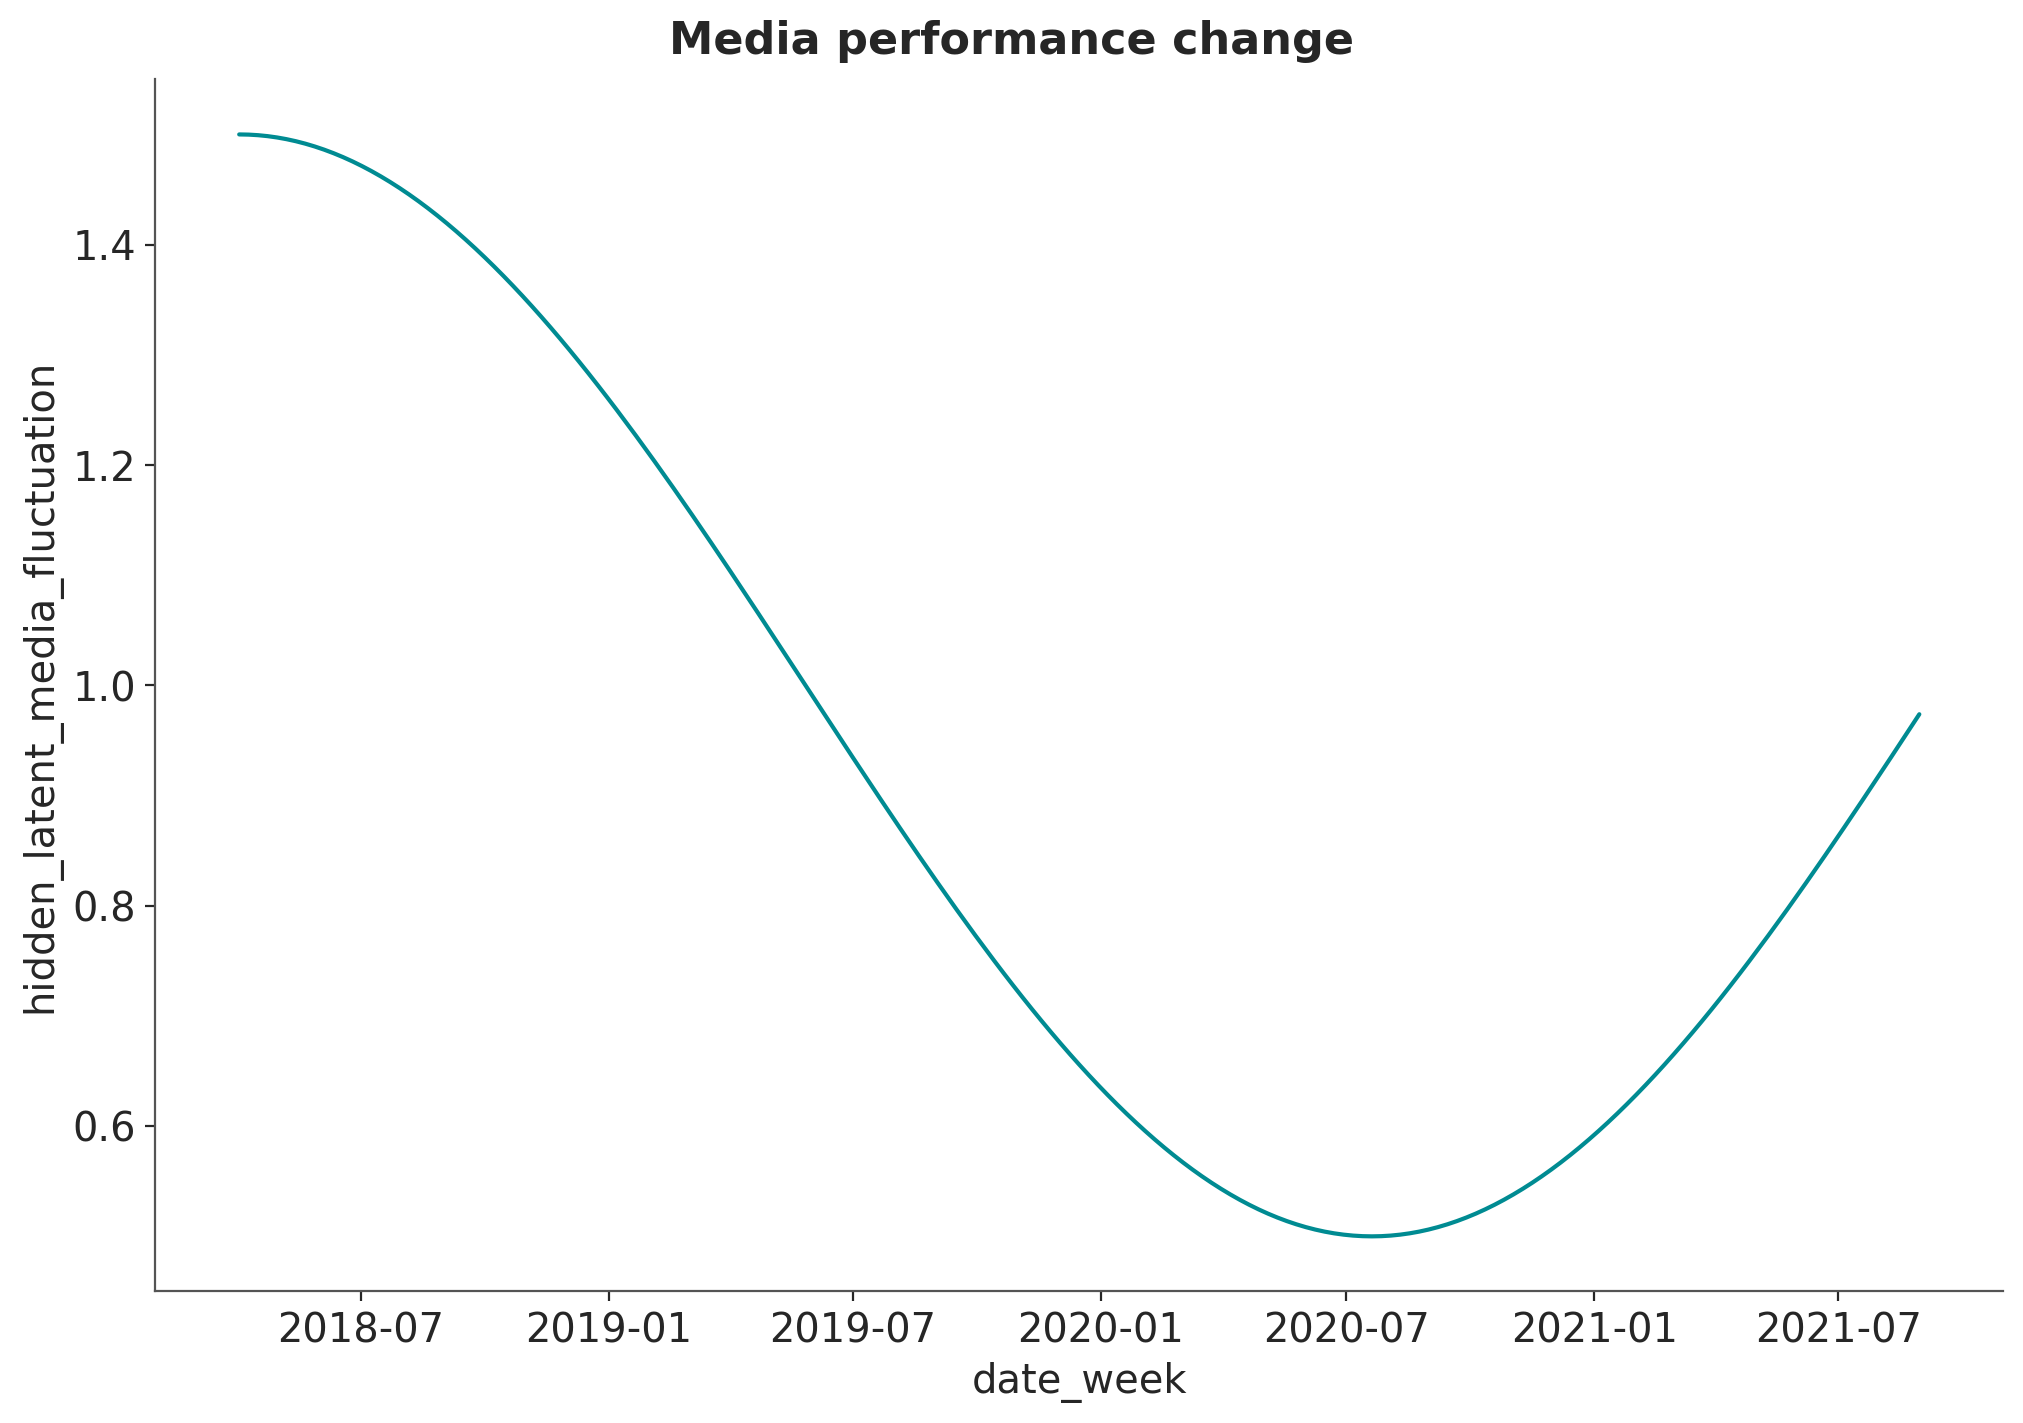

In [5]:
fig, ax = plt.subplots(
    nrows=1, ncols=1, figsize=(10, 7), sharex=True, sharey=True, layout="constrained"
)
sns.lineplot(x="date_week", y="hidden_latent_media_fluctuation", data=df, color="C0")
ax.set(xlabel="date_week")
fig.suptitle("Media performance change", fontsize=16);

By centering the signal around 1, we'll maintain the base contribution as the average effect while allowing for periodic increases and decreases. This approach mirrors real-world scenarios where marketing effectiveness can vary, but the overall trend remains consistent.
This synthetic signal is essential for demonstrating the efficacy of our time-dependent MMM model, which should recover this signal as much as possible.


### 6. Target Variable
Finally, we need to create our target variable. In order to do create, we'll use the PyMC `do` [operator](https://www.pymc-labs.com/blog-posts/causal-analysis-with-pymc-answering-what-if-with-the-new-do-operator/) to specify some true parameter values that govern the causal relationships in the model. 
Doing this, we'll draw a simulated target variable (sales) $y$, which assume it is a linear combination of all components in the model. We also add some Gaussian noise.


In [6]:
# Real values
real_alpha = [3, 5]
real_lam = [0.3, 0.5]
adstock_max_lag = 8
yearly_seasonality = 2
true_params = {
    "intercept_contribution": 6.0,
    "adstock_alpha": np.array([0.5, 0.4]),
    "saturation_alpha": np.array(real_alpha),
    "saturation_lam": np.array(real_lam),
    "media_temporal_latent_multiplier": df["hidden_latent_media_fluctuation"],
    "gamma_fourier": np.array([2.5, -0.5, 1.5, 2.5]),
    "y_sigma": 0.25,
    "gamma_control": np.array([-3.5, 6.25]),
}

Using the grid, the `do` [operator](https://www.pymc-labs.com/blog-posts/causal-analysis-with-pymc-answering-what-if-with-the-new-do-operator/), with a dummy model from the MMM class, we can build the true model. We'll no go into those details, but we can unpack this a little bit.
The do-function takes a pymc.Model object and a dict of parameter values. It then returns a new model where the original random variables (RVs) have been converted to constant nodes taking on the specified values.
Meaning if we pick the node for the intercept, the value should match our grid.


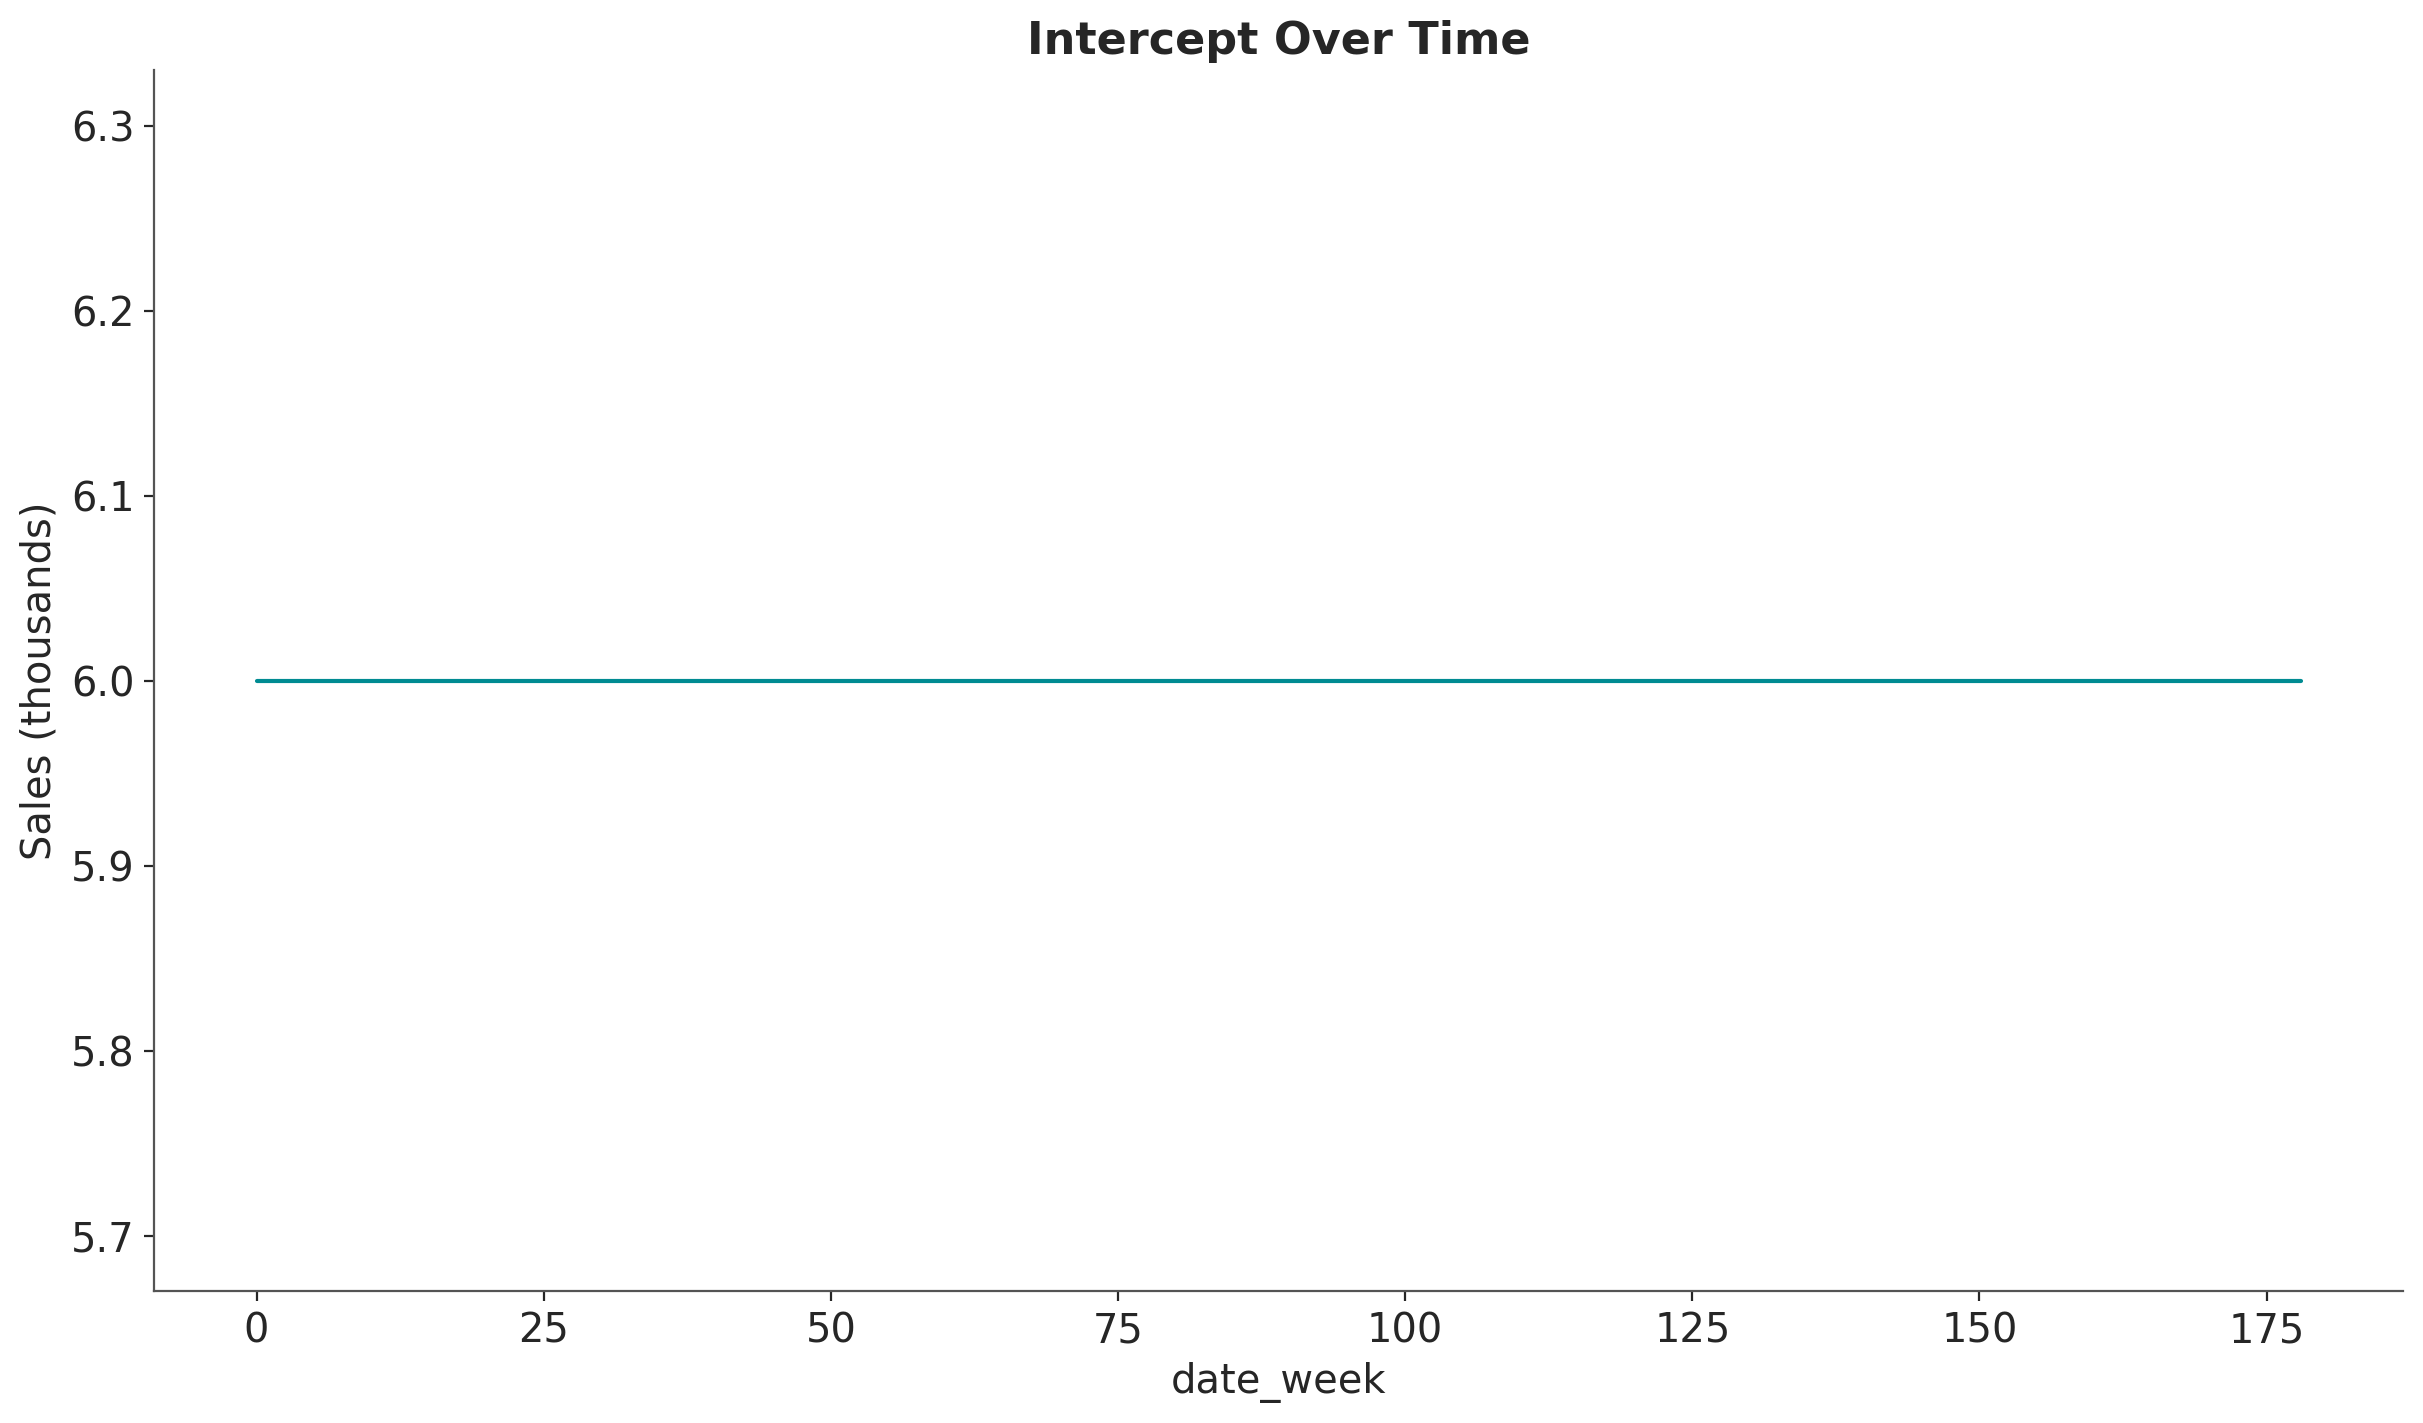

In [7]:
plt.plot(df["intercept"])
plt.title("Intercept Over Time")
plt.xlabel("date_week")
plt.ylabel("Sales (thousands)");

As you can see, the intercept is aligned with the previously added data, having a constant value of `6`. But how looks our total contribution after transformed?


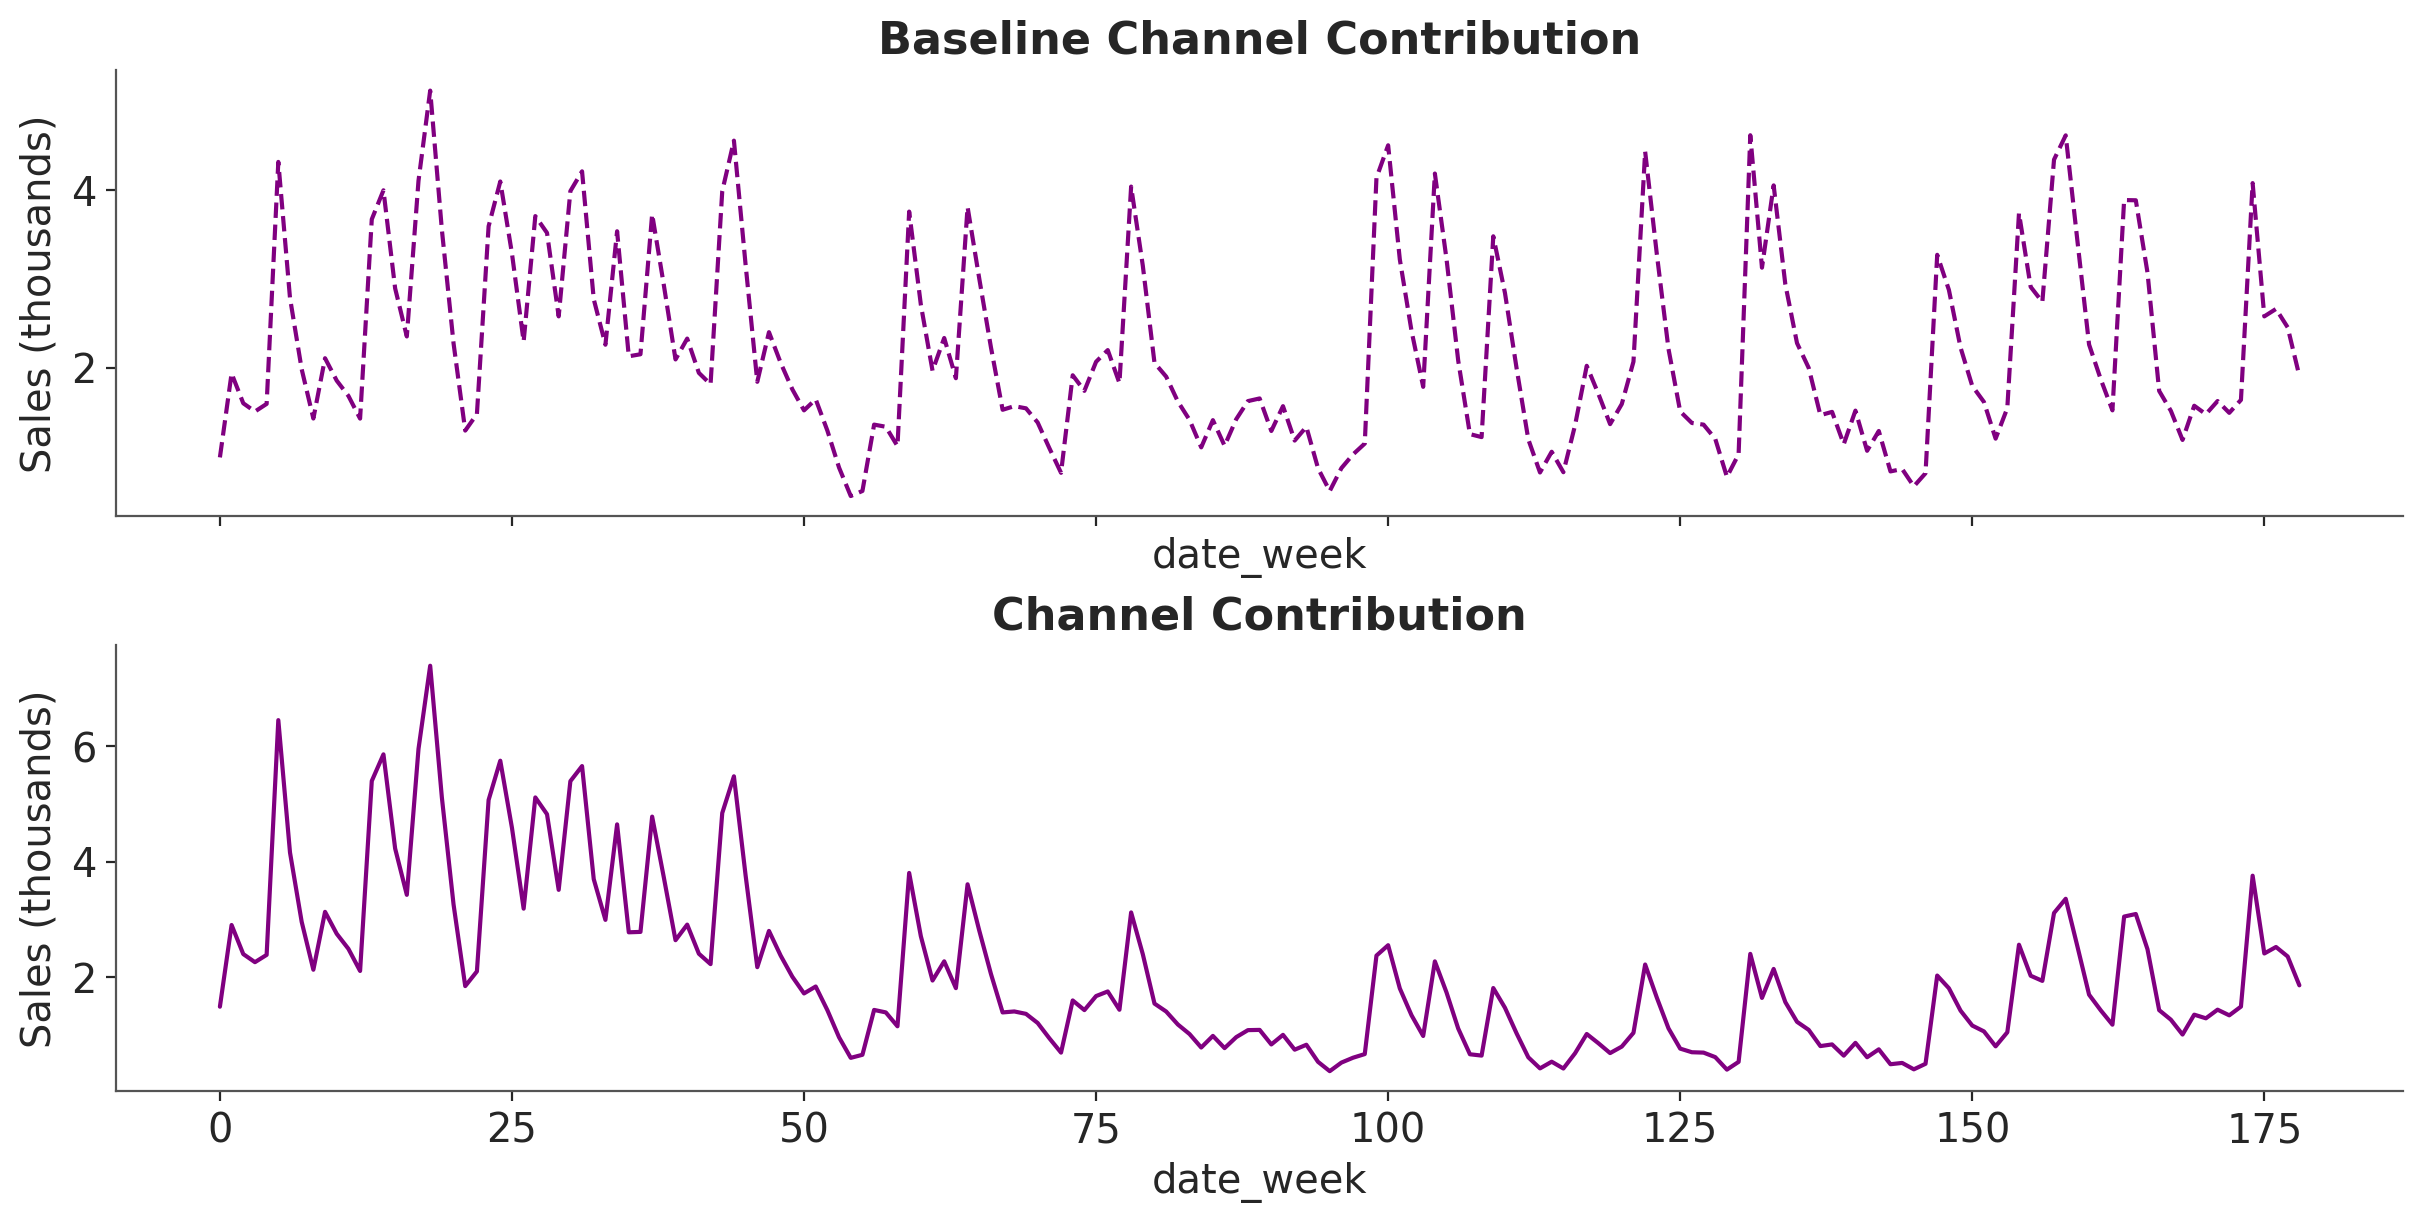

In [8]:
fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
ax[0].plot(df["baseline_channel_contribution"], color="purple", linestyle="--")
ax[0].set_title("Baseline Channel Contribution")
ax[0].set_xlabel("date_week")
ax[0].set_ylabel("Sales (thousands)")
ax[1].plot(df["channel_contribution"], color="purple")
ax[1].set_title("Channel Contribution")
ax[1].set_xlabel("date_week")
ax[1].set_ylabel("Sales (thousands)");

**Baseline Channel Contributions**
The left plot, titled "Baseline Channel Contributions," shows the contributions of the media channels before considering the time-varying effects. The values are generated by summing the baseline channel contributions drawn from the true model. 
**Channel Contributions with Time Variation**
The right plot, titled "Channel Contributions," displays the media channel contributions after incorporating the time-varying media performance signal. These contributions reflect the impact of the latent temporal process, represented by `hidden_latent_media_fluctuation`, which modifies the baseline contributions. This modification captures the natural fluctuations in media performance over time, as influenced by various marketing dynamics.


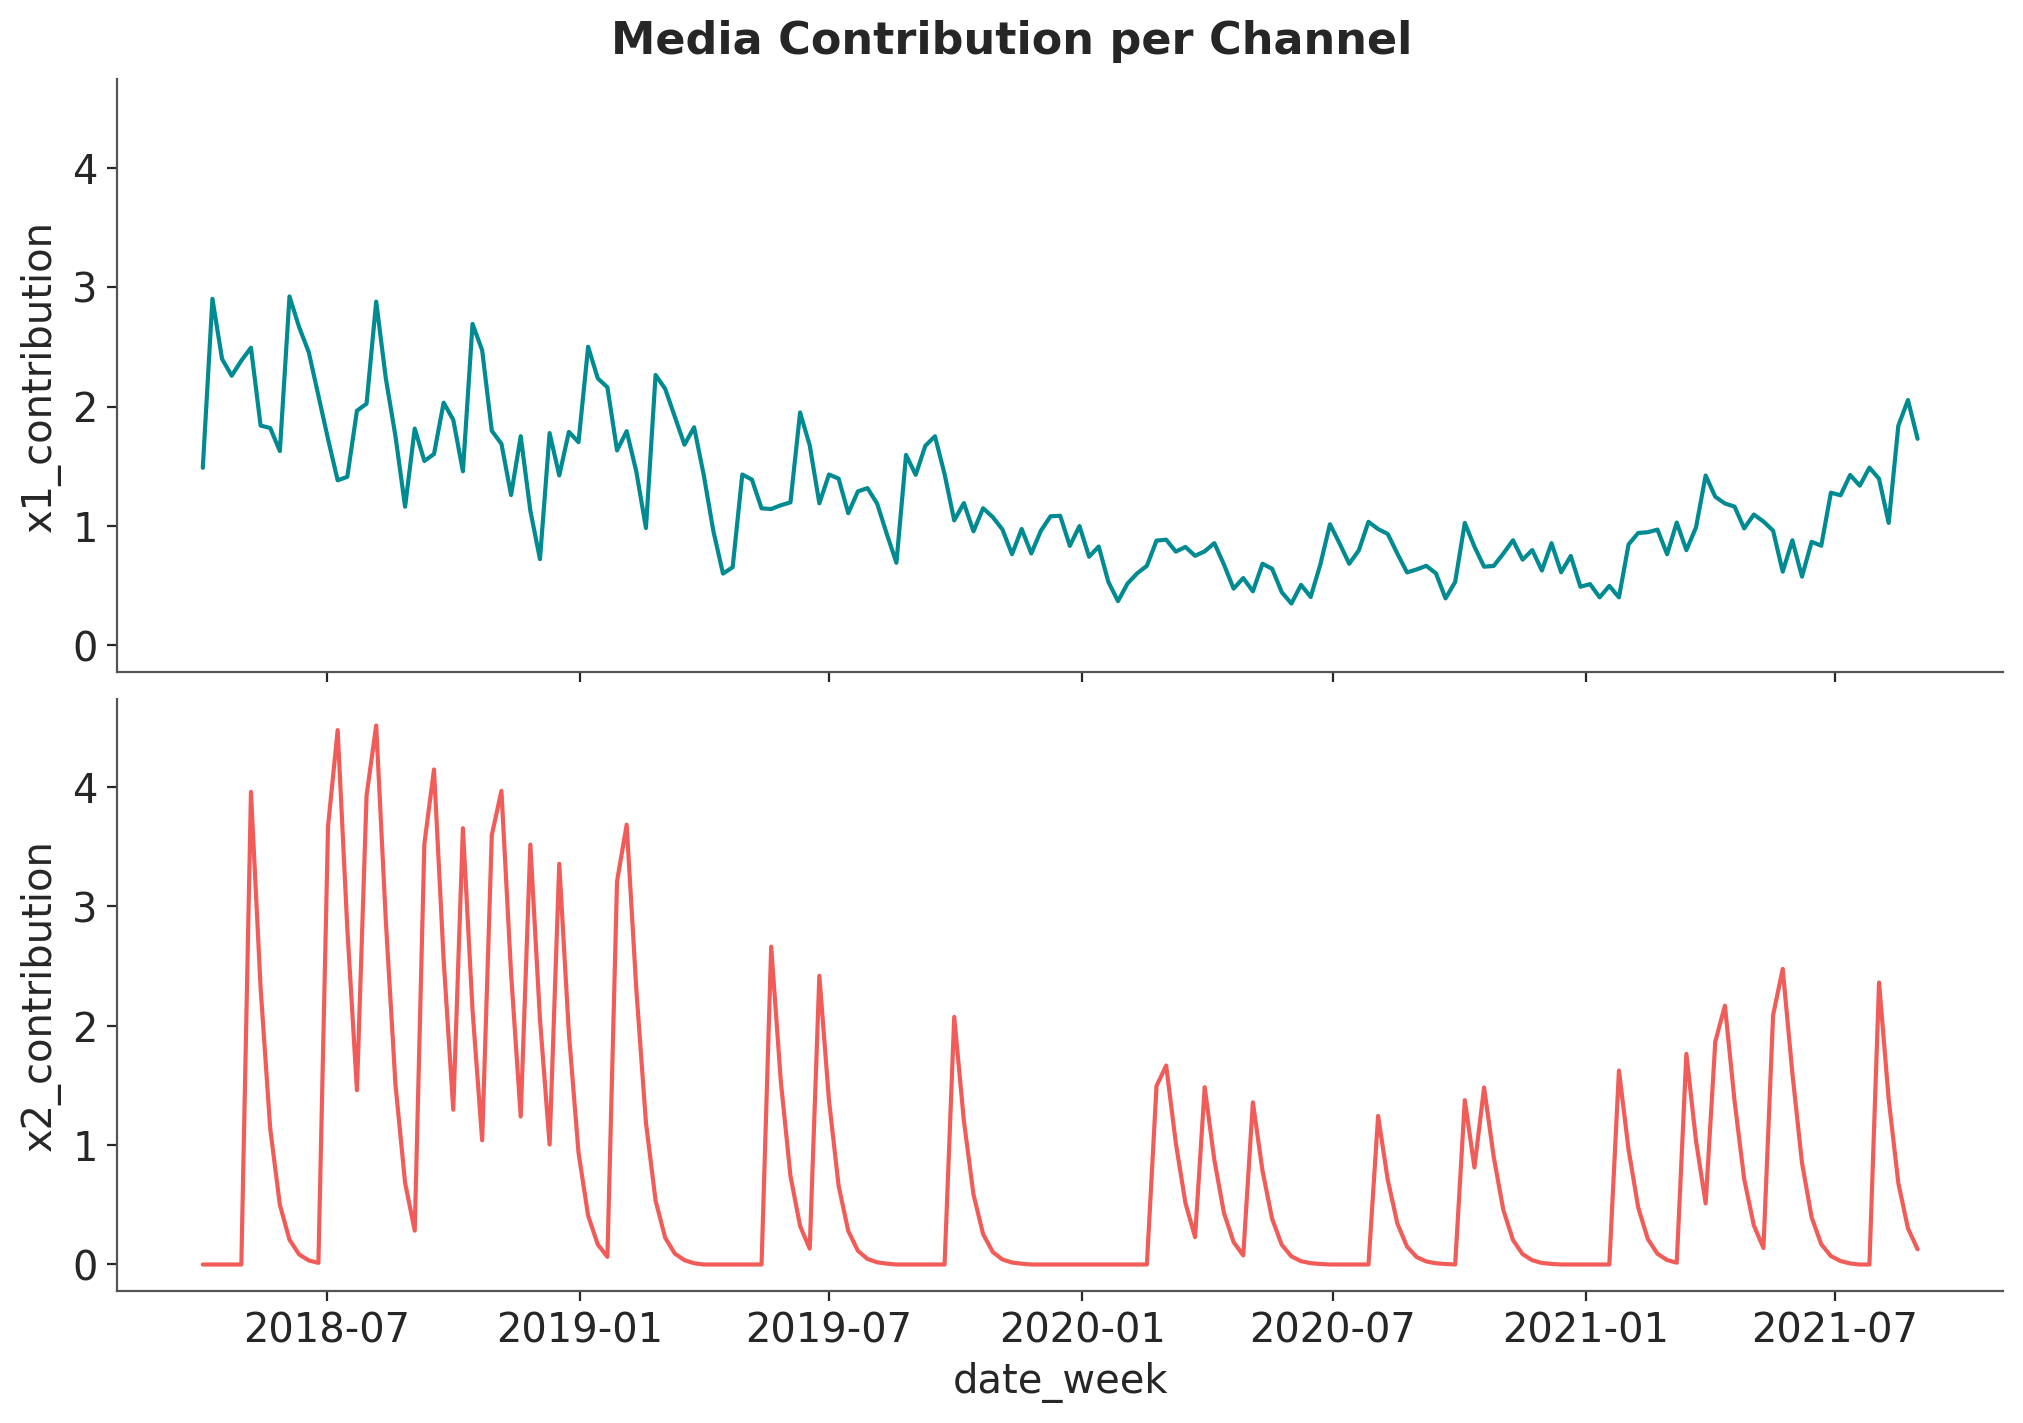

In [9]:
fig, ax = plt.subplots(
    nrows=2, ncols=1, figsize=(10, 7), sharex=True, sharey=True, layout="constrained"
)
sns.lineplot(x="date_week", y="x1_contribution", data=df, color="C0", ax=ax[0])
sns.lineplot(x="date_week", y="x2_contribution", data=df, color="C1", ax=ax[1])
ax[1].set(xlabel="date_week")
fig.suptitle("Media Contribution per Channel", fontsize=16);

### 7. Trend \& Seasonal Components
We can also observe the contribution of our control events, as well as the seasonality added when making the true model.


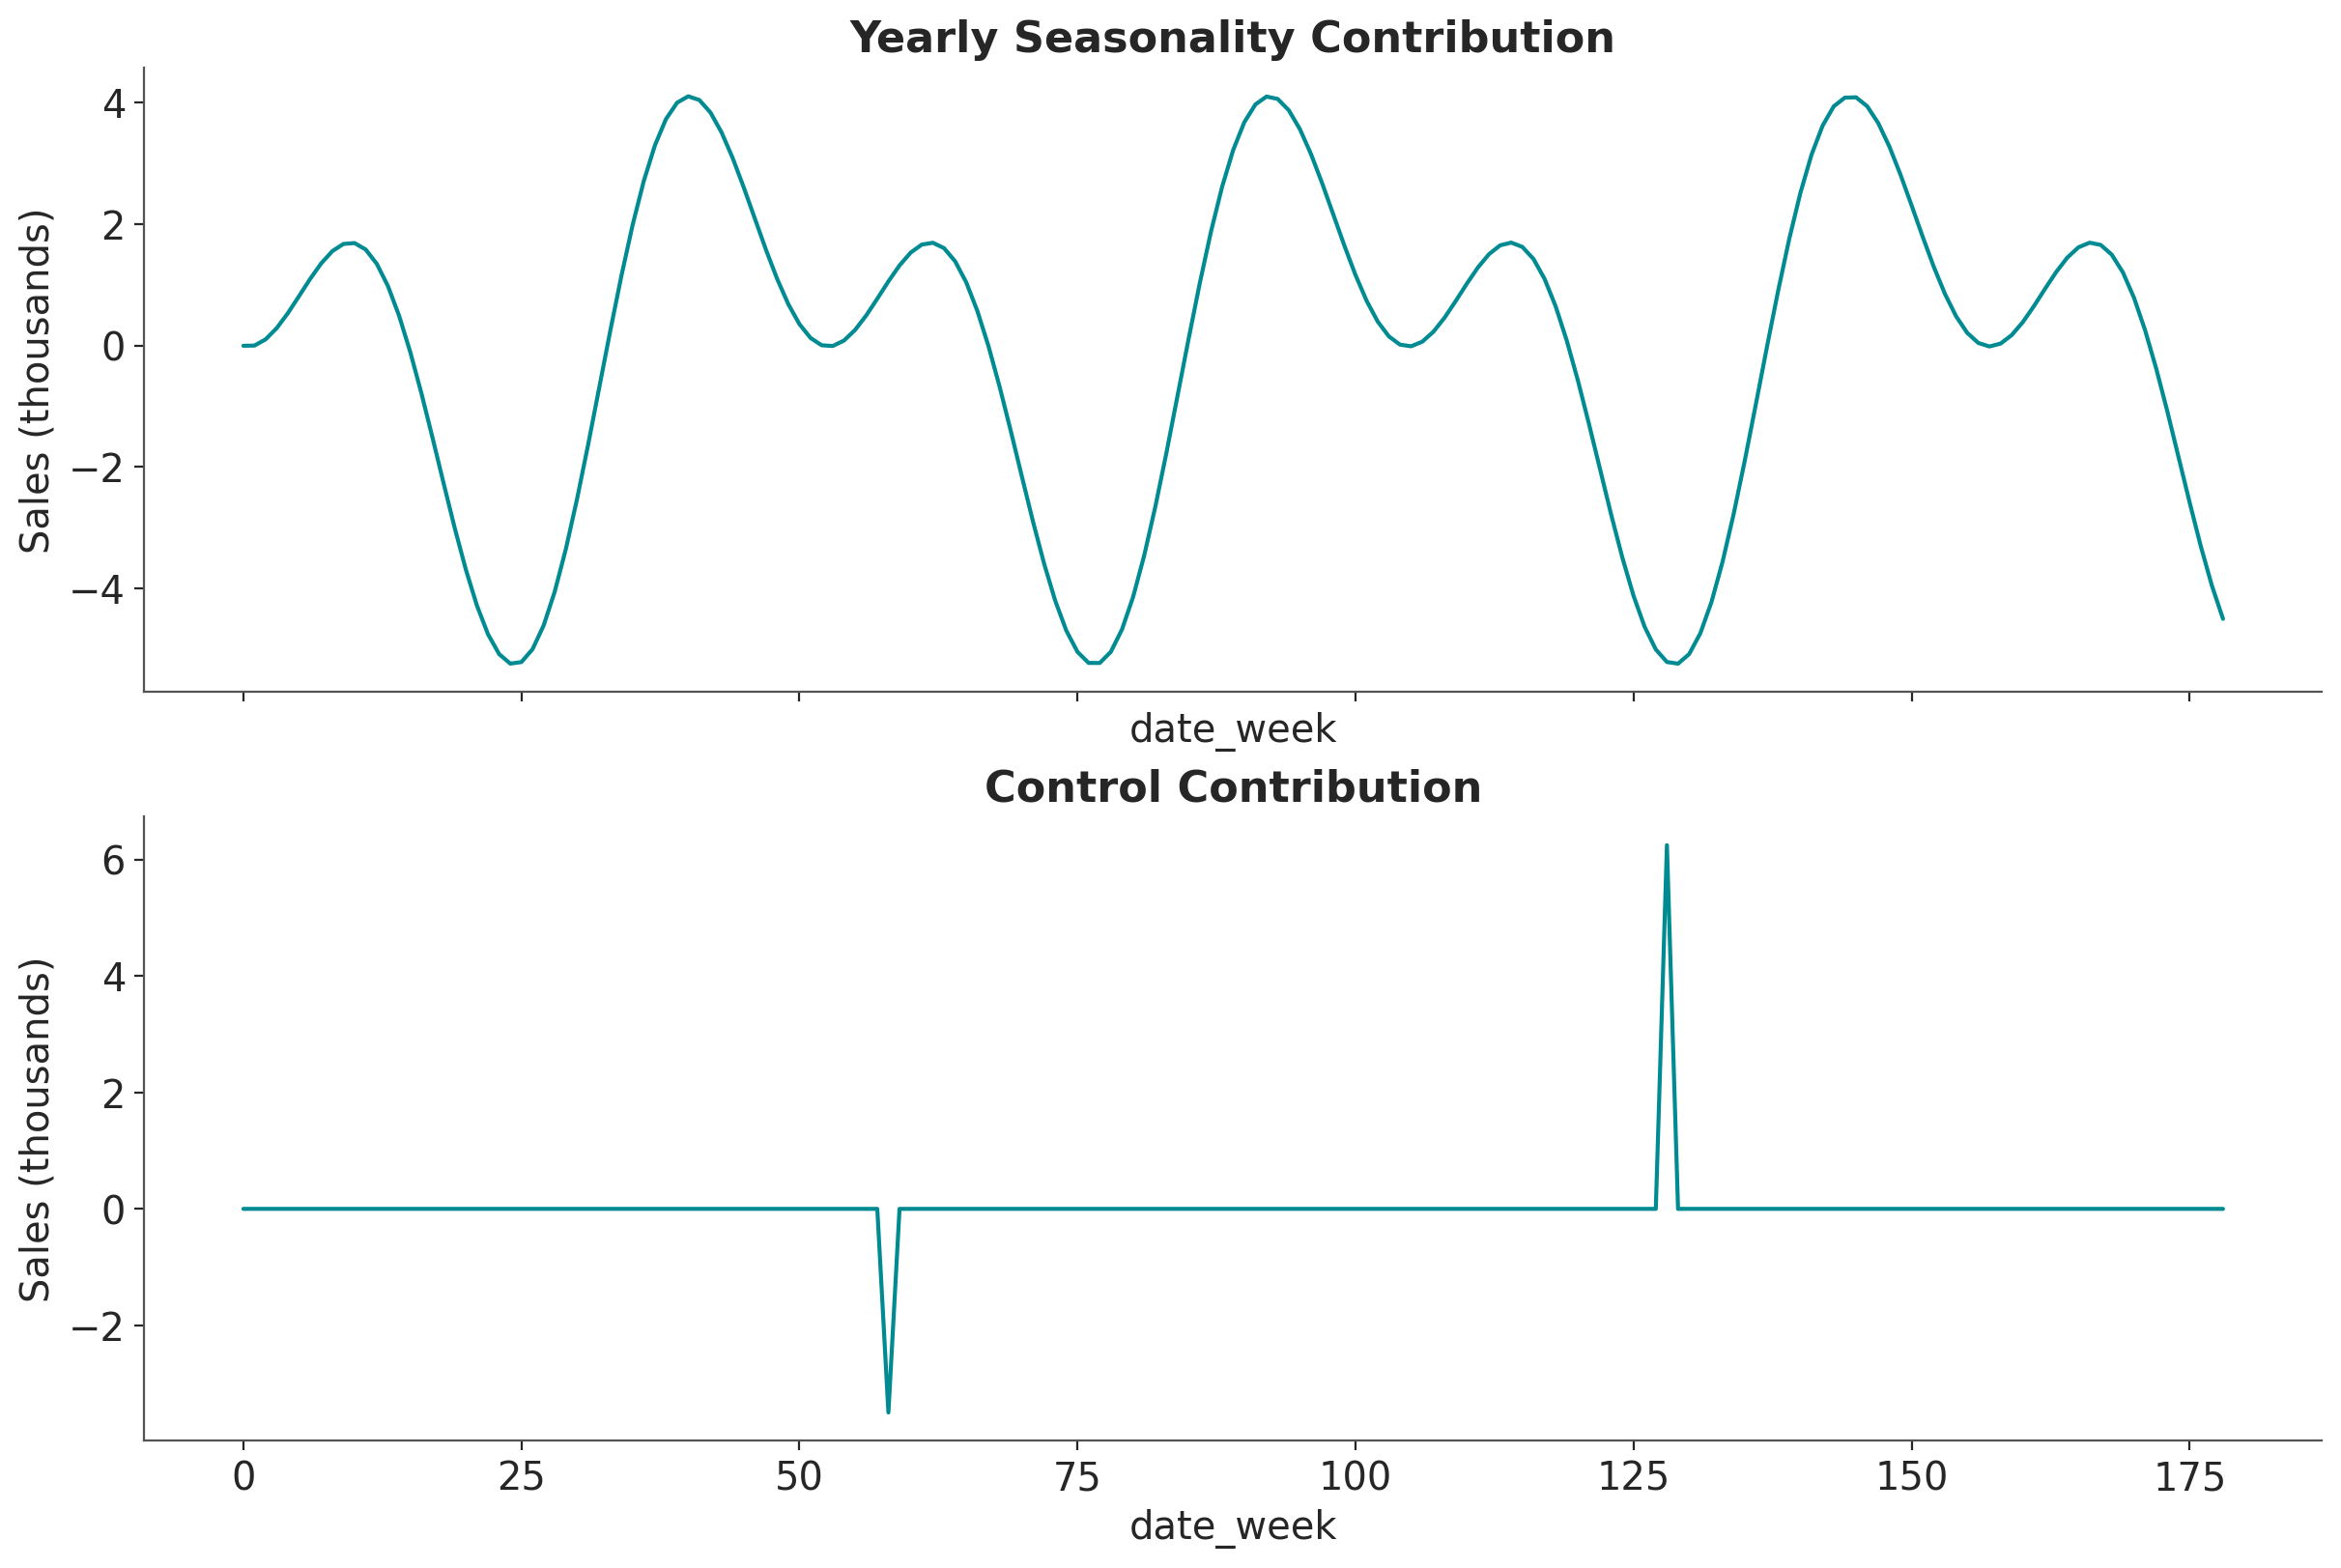

In [10]:
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(12, 8), sharex=True)
ax1.plot(df["yearly_seasonality_contribution"])
ax1.set_title("Yearly Seasonality Contribution")
ax1.set_xlabel("date_week")
ax1.set_ylabel("Sales (thousands)")
ax2.plot(df["control_contribution"])
ax2.set_title("Control Contribution")
ax2.set_xlabel("date_week")
ax2.set_ylabel("Sales (thousands)");

Finally, we can visualize the true target given all the previous componets!


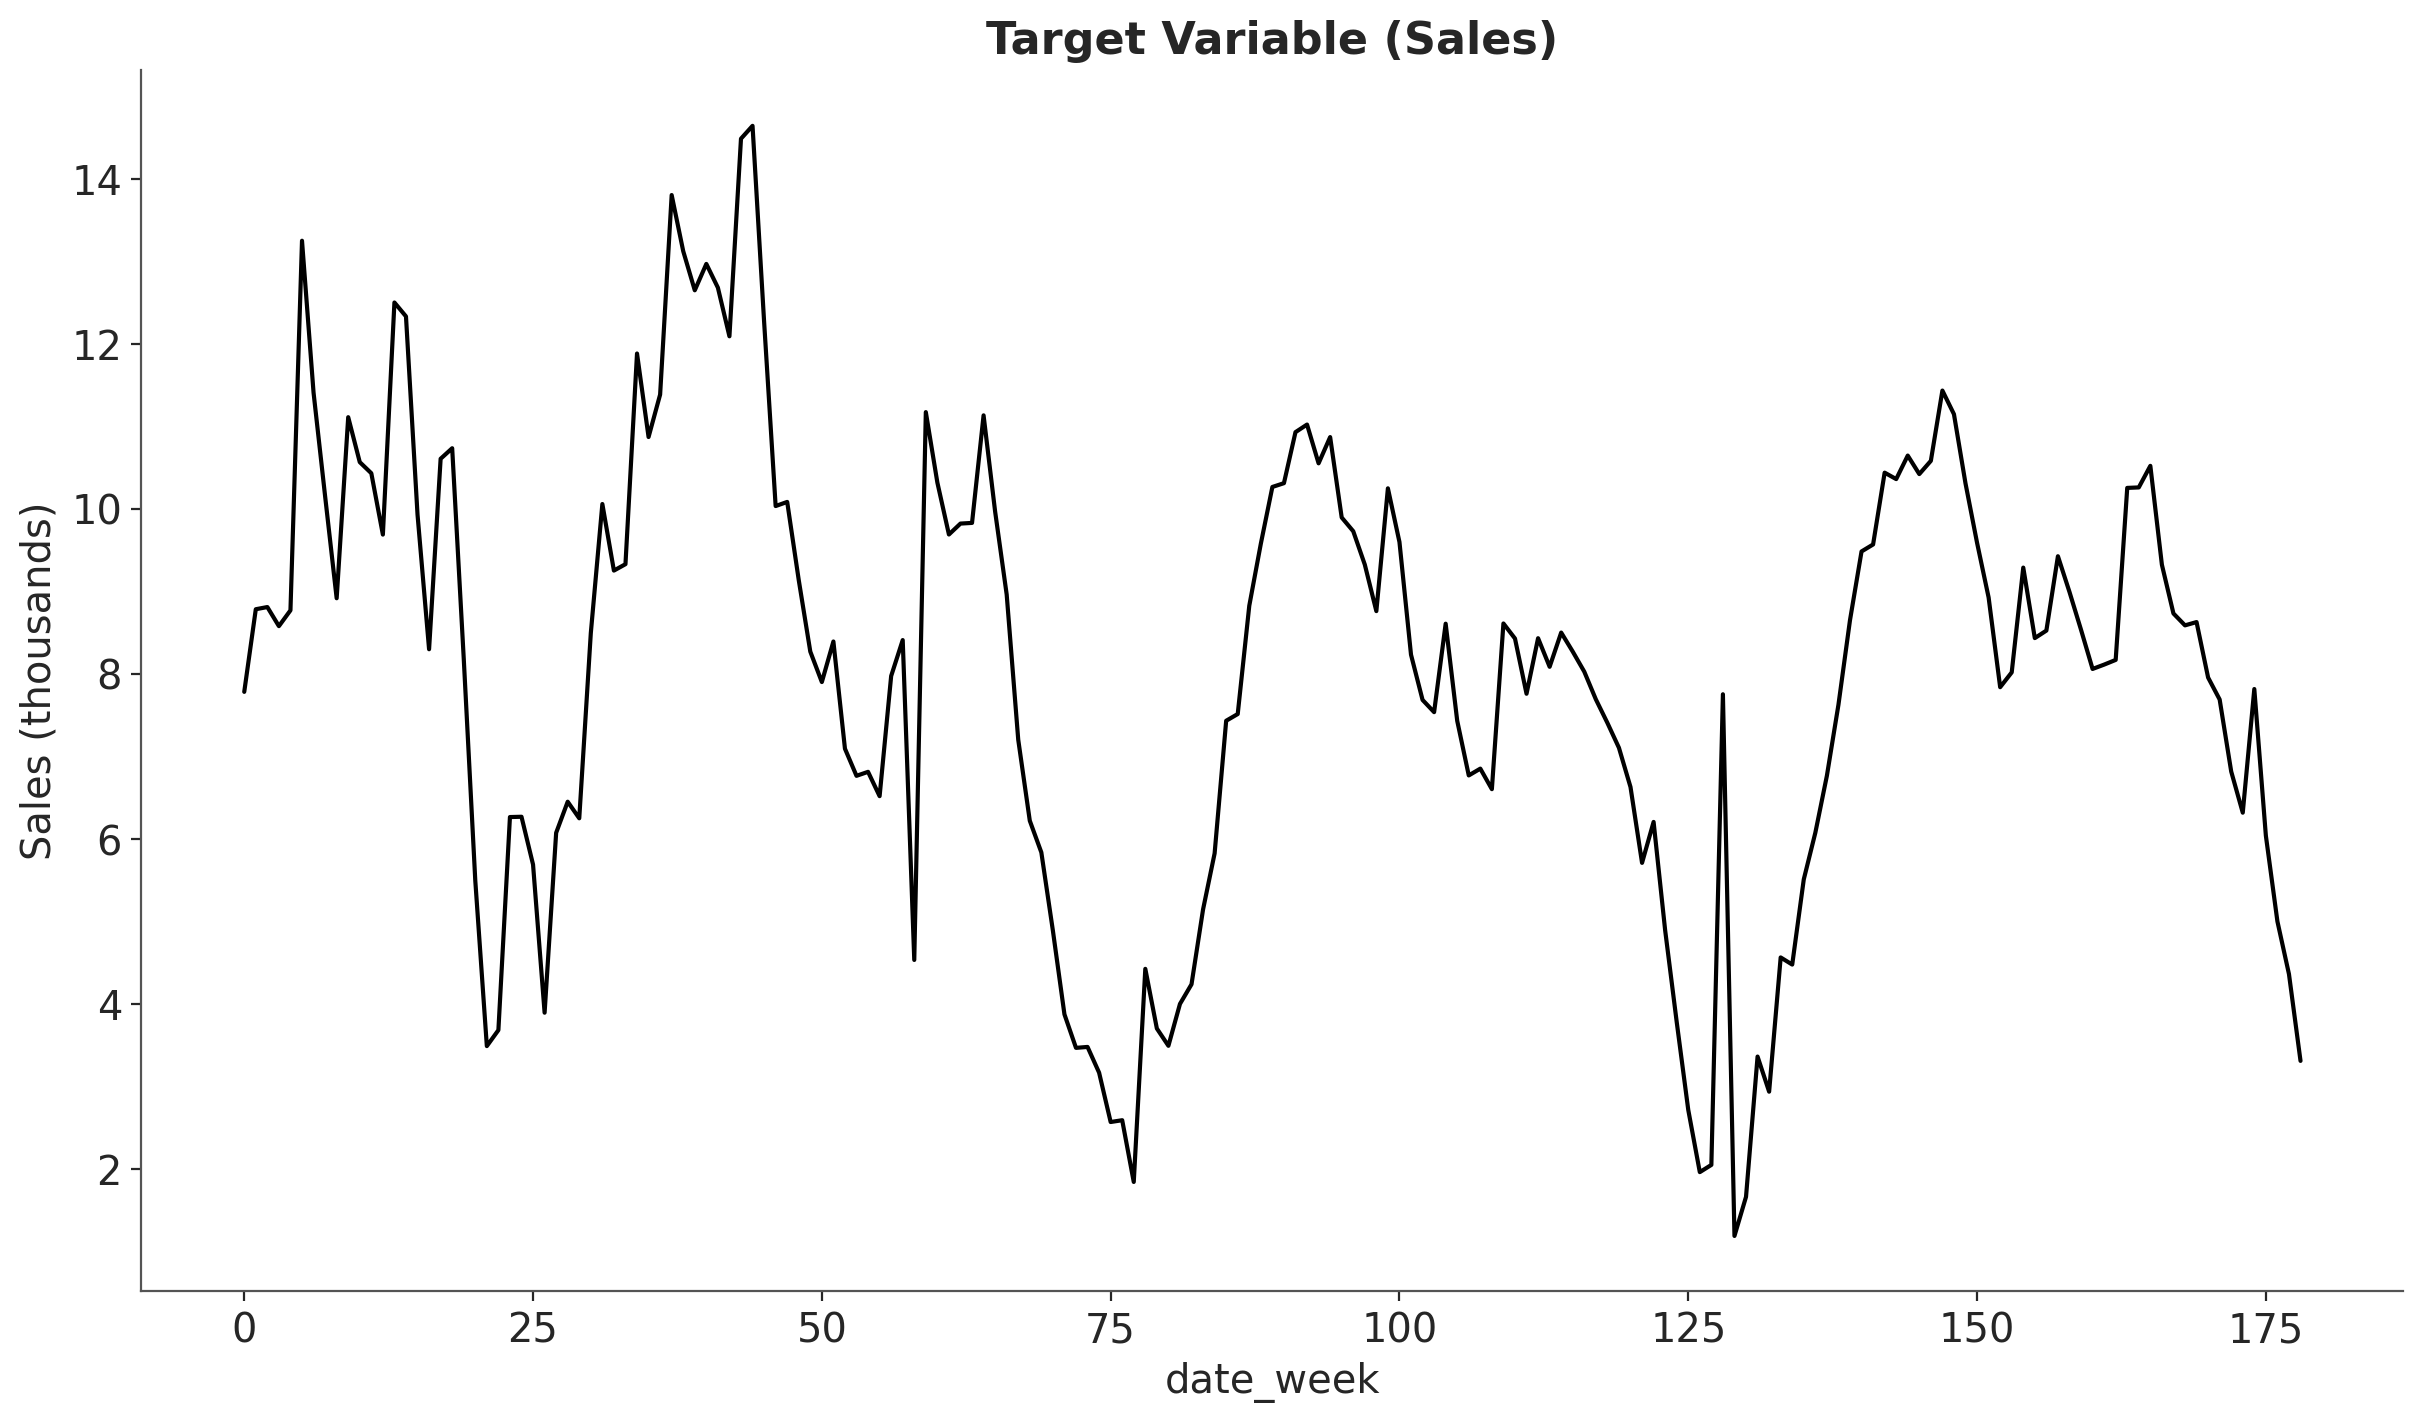

In [11]:
plt.plot(df["y"], color="black")
plt.title("Target Variable (Sales)")
plt.xlabel("date_week")
plt.ylabel("Sales (thousands)");

Now with everything in place, we are going to separate our dataset to leave the real data estimated by the true model inside `df` and we will create a new dataset called `data` which will have all the necessary columns but will not have any information about true relationships. Similar to how it would happen in real life.


In [12]:
data = df[["date_week", "x1", "x2", "event_1", "event_2", "y"]].copy()
X = data.drop("y", axis=1)
y = data["y"]

As we discussed previously, we want to compare a model without variant coefficients to see how much it deviates from reality. For this we will create the MMM object that will receive all the necessary parameters to build our model, which should estimate the relationships of the true model.


In [13]:
basic_mmm = MMM(
    date_column="date_week",
    target_column="y",
    channel_columns=["x1", "x2"],
    control_columns=["event_1", "event_2"],
    yearly_seasonality=yearly_seasonality,
    adstock=GeometricAdstock(l_max=adstock_max_lag).set_dims_for_all_priors("channel"),
    saturation=MichaelisMentenSaturation().set_dims_for_all_priors("channel"),
)
basic_mmm.fit(
    X=X,
    y=y,
    target_accept=0.92,
    draws=500,
    random_seed=rng,
)

NUTS[nutpie]: [adstock_alpha, saturation_lam, saturation_alpha, gamma_fourier, gamma_control, y_sigma, intercept_contribution]


Output()

Output()

<xarray.DataTree>
Group: /
│   Attributes: (12/24)
│       id:                         6fc280aa9772a174
│       model_type:                 MMMM (Multi-Dimensional Marketing Mix Model)
│       version:                    0.0.2
│       sampler_config:             {}
│       model_config:               {"intercept": {"dist": "Normal", "kwargs": {"...
│       __serialization_version__:  1
│       ...                         ...
│       scaling:                    {"__type__": "pymc_marketing.mmm.scaling.Scal...
│       dag:                        null
│       treatment_nodes:            null
│       outcome_node:               null
│       mu_effects:                 []
│       cost_per_unit:              null
├── Group: /posterior
│       Dimensions:                                  (chain: 4, draw: 500,
│                                                     fourier_mode: 4, control: 2,
│                                                     channel: 2, date: 179)
│       Coordinates:
│         * chain                                    (chain) int64 32B 0 1 2 3
│         * draw                                     (draw) int64 4kB 0 1 2 ... 498 499
│         * fourier_mode                             (fourier_mode) object 32B 'sin_1...
│         * control                                  (control) object 16B 'event_1' '...
│         * channel                                  (channel) object 16B 'x1' 'x2'
│         * date                                     (date) datetime64[ns] 1kB 2018-0...
│       Data variables:
│           gamma_fourier                            (chain, draw, fourier_mode) float64 64kB ...
│           gamma_control                            (chain, draw, control) float64 32kB ...
│           intercept_contribution                   (chain, draw) float64 16kB 0.423...
│           adstock_alpha                            (chain, draw, channel) float64 32kB ...
│           saturation_lam                           (chain, draw, channel) float64 32kB ...
│           saturation_alpha                         (chain, draw, channel) float64 32kB ...
│           y_sigma                                  (chain, draw) float64 16kB 0.055...
│           total_media_contribution_original_scale  (chain, draw) float64 16kB 319.6...
│           yearly_seasonality_contribution          (chain, draw, date) float64 3MB ...
│           fourier_contribution                     (chain, draw, date, fourier_mode) float64 11MB ...
│           control_contribution                     (chain, draw, date, control) float64 6MB ...
│           channel_contribution                     (chain, draw, date, channel) float64 6MB ...
│       Attributes:
│           created_at:                 2026-07-08T08:12:50.955759+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           sample_dims:                ['chain', 'draw']
│           inference_library:          nutpie
│           inference_library_version:  0.16.10
│           sampling_time:              0.9355409145355225
│           tuning_steps:               400
│           pymc_marketing_version:     1.0.0.dev0
├── Group: /sample_stats
│       Dimensions:                   (chain: 4, draw: 500)
│       Coordinates:
│         * chain                     (chain) int64 32B 0 1 2 3
│         * draw                      (draw) int64 4kB 0 1 2 3 4 ... 495 496 497 498 499
│       Data variables: (12/20)
│           depth                     (chain, draw) uint64 16kB 4 5 4 4 4 ... 5 4 4 4 5
│           maxdepth_reached          (chain, draw) bool 2kB False False ... False False
│           step_size                 (chain, draw) float64 16kB 0.2008 ... 0.2278
│           transformation_update_id  (chain, draw) int64 16kB 0 0 0 0 0 0 ... 0 0 0 0 0
│           step_size_bar             (chain, draw) float64 16kB 0.2072 ... 0.2131
│           mean_tree_accept          (chain, draw) float64 16kB 0.8493 ...

As we can see the model found divergencies!🤯
The occurrence of divergences in our Bayesian MMM highlights the strengths and robustness of the Bayesian framework in hypothesis testing and model validation. Bayesian models are structural and adhere to certain assumptions about the data-generating process. When these assumptions are violated or the model structure does not fit the data well, divergences and sampling problems can arise.
This characteristic makes the Bayesian approach a powerful tool for:
* **Hypothesis Testing**: By defining clear structural relationships and assumptions, Bayesian models can help test and validate hypotheses about the underlying processes in the data.
* **Model Validation**: Divergences and sampling issues serve as indicators that the model may not be correctly specified, prompting further investigation and refinement.
* **Understanding Complex Systems**: Bayesian methods allow for the incorporation of prior knowledge and the testing of various structural assumptions, making them well-suited for understanding complex, real-world systems.
In this particular case, we can perfectly suspect why the model had divergences. The internal structure from our world model (MMM) is neglecting time when this one is an important factor (we know this because we have carried out the due process of data generation).
---
Despite that, let's take a look at the data that we were able to recover through this basic model.


If we decompose the posterior predictive distribution into the different components, everything becomes clear:


(<Figure size 1600x800 with 1 Axes>,
 array([[<Axes: title={'center': 'Time Series Contributions'}, xlabel='Date', ylabel='Posterior Value'>]],
       dtype=object))

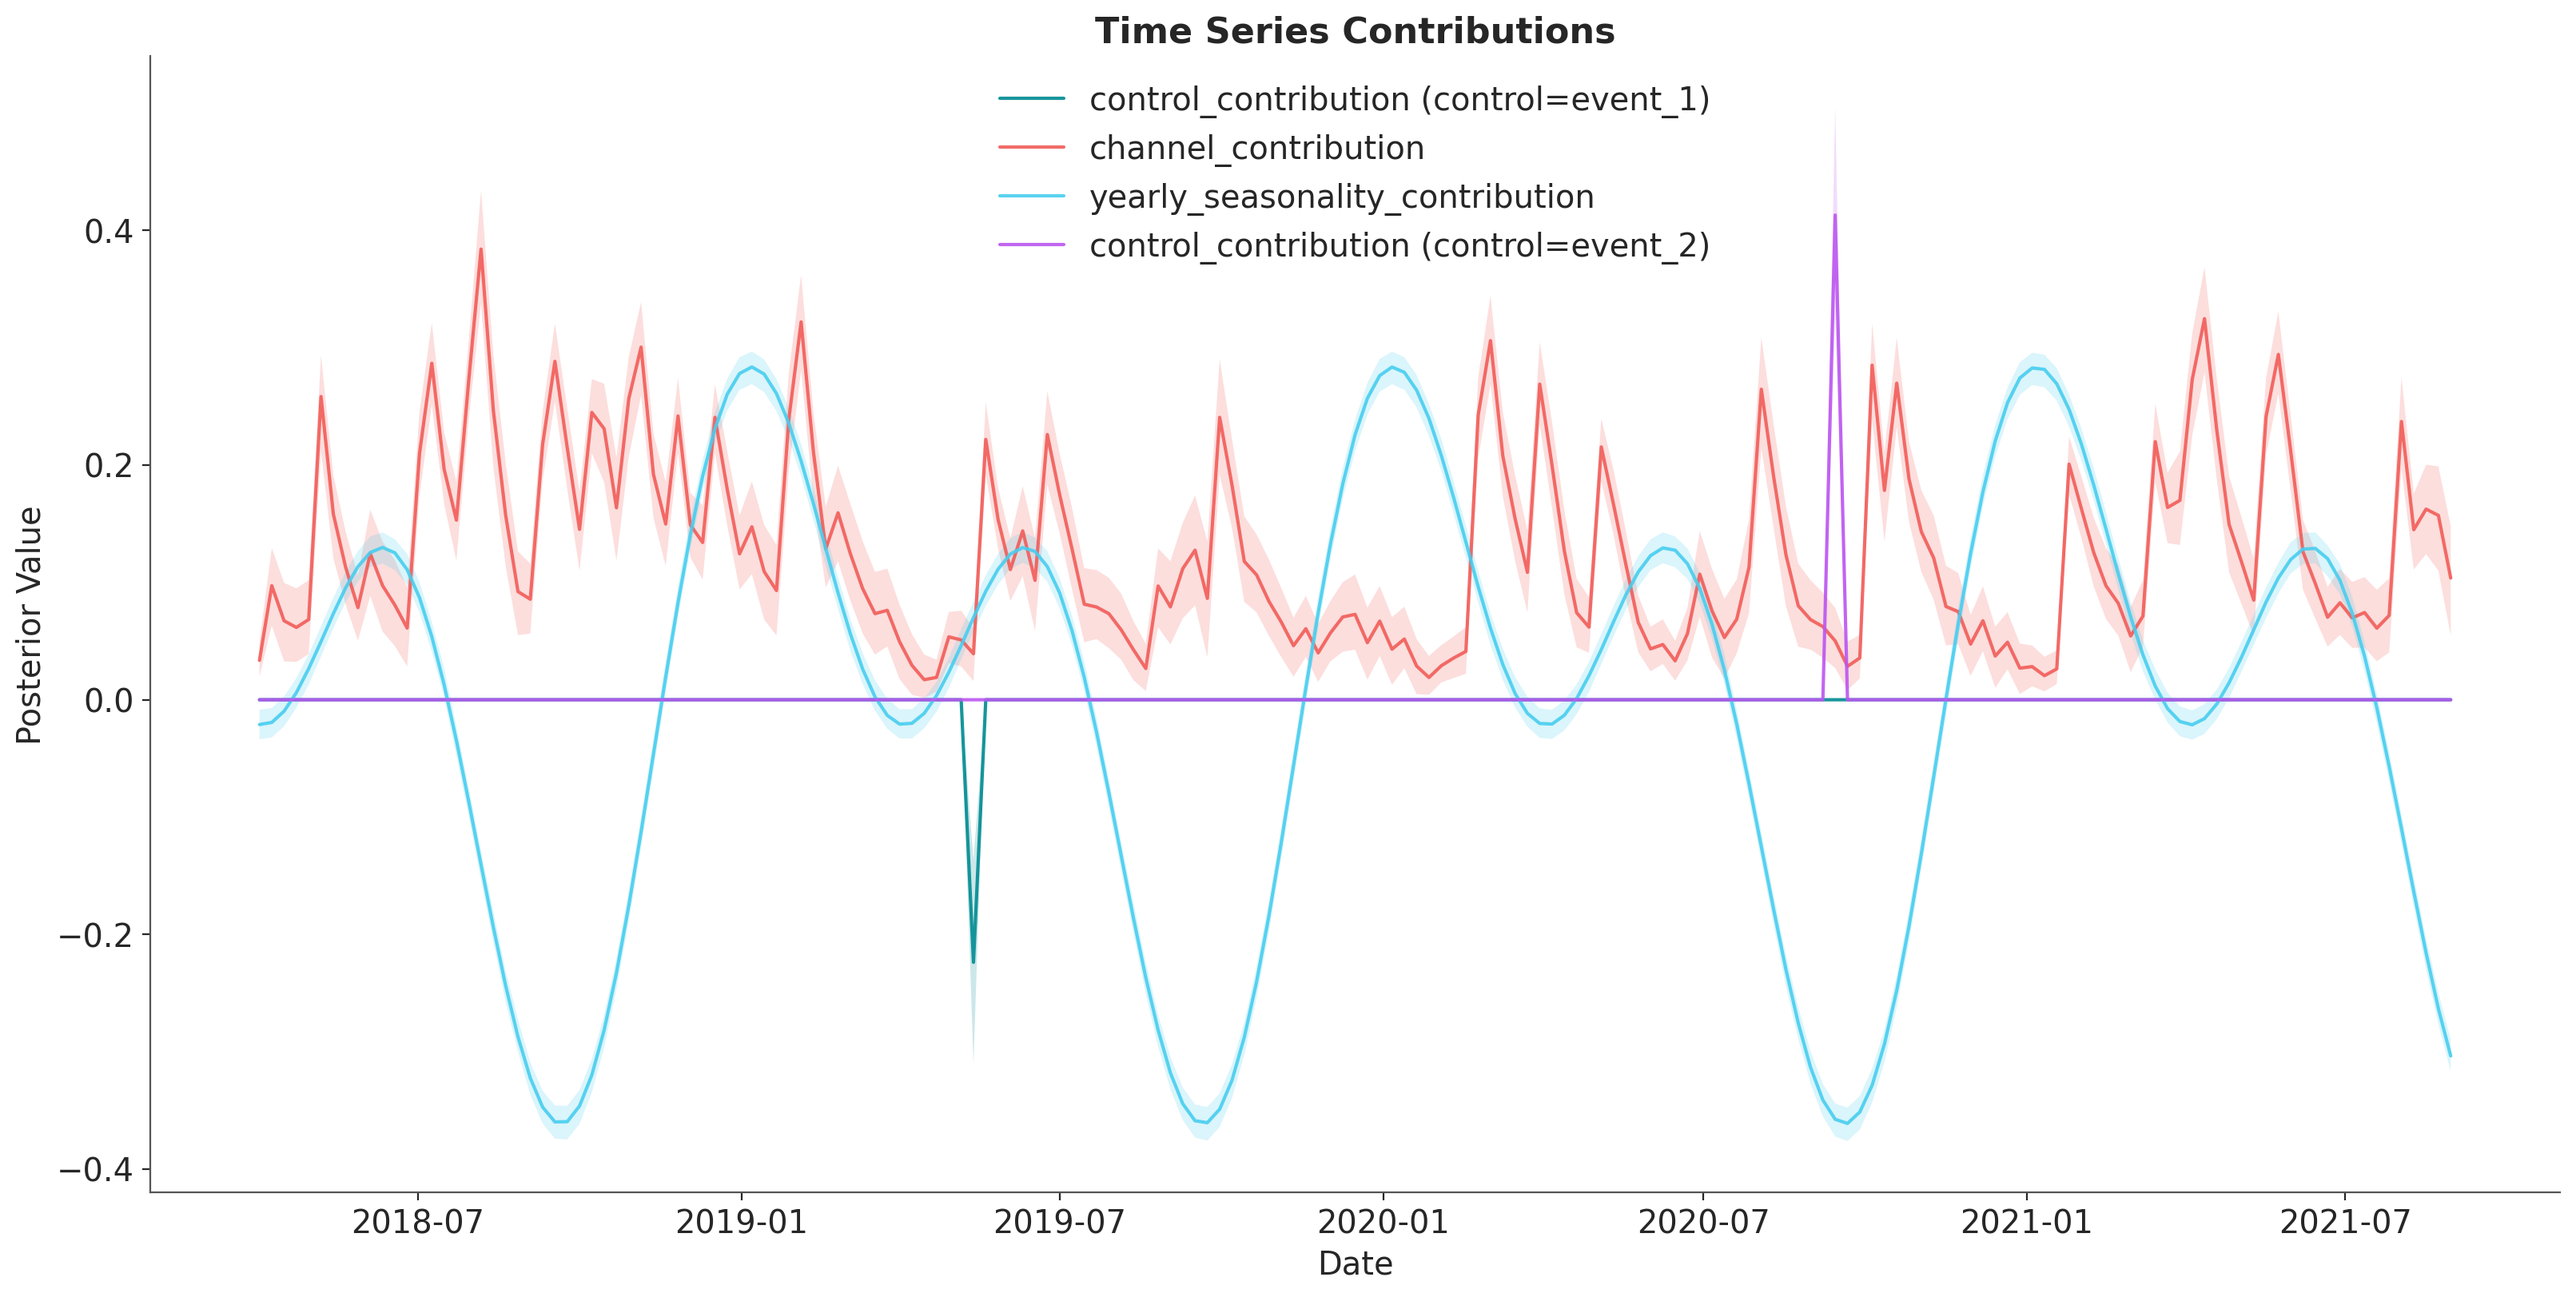

In [14]:
basic_mmm.plot.contributions_over_time(
    var=[
        "control_contribution",
        "channel_contribution",
        "yearly_seasonality_contribution",
    ],
    combine_dims=True,
    figsize=(16, 8),
)

Some contributions end up having more units than the target value, forcing the model to compensate. Resulting in an incorrect decomposition of our marketing activities.
For example, our time series ends up with a long tail of probable values ​​for marketing contributions, this tail being up to 3X greater than the maximum value of our target.


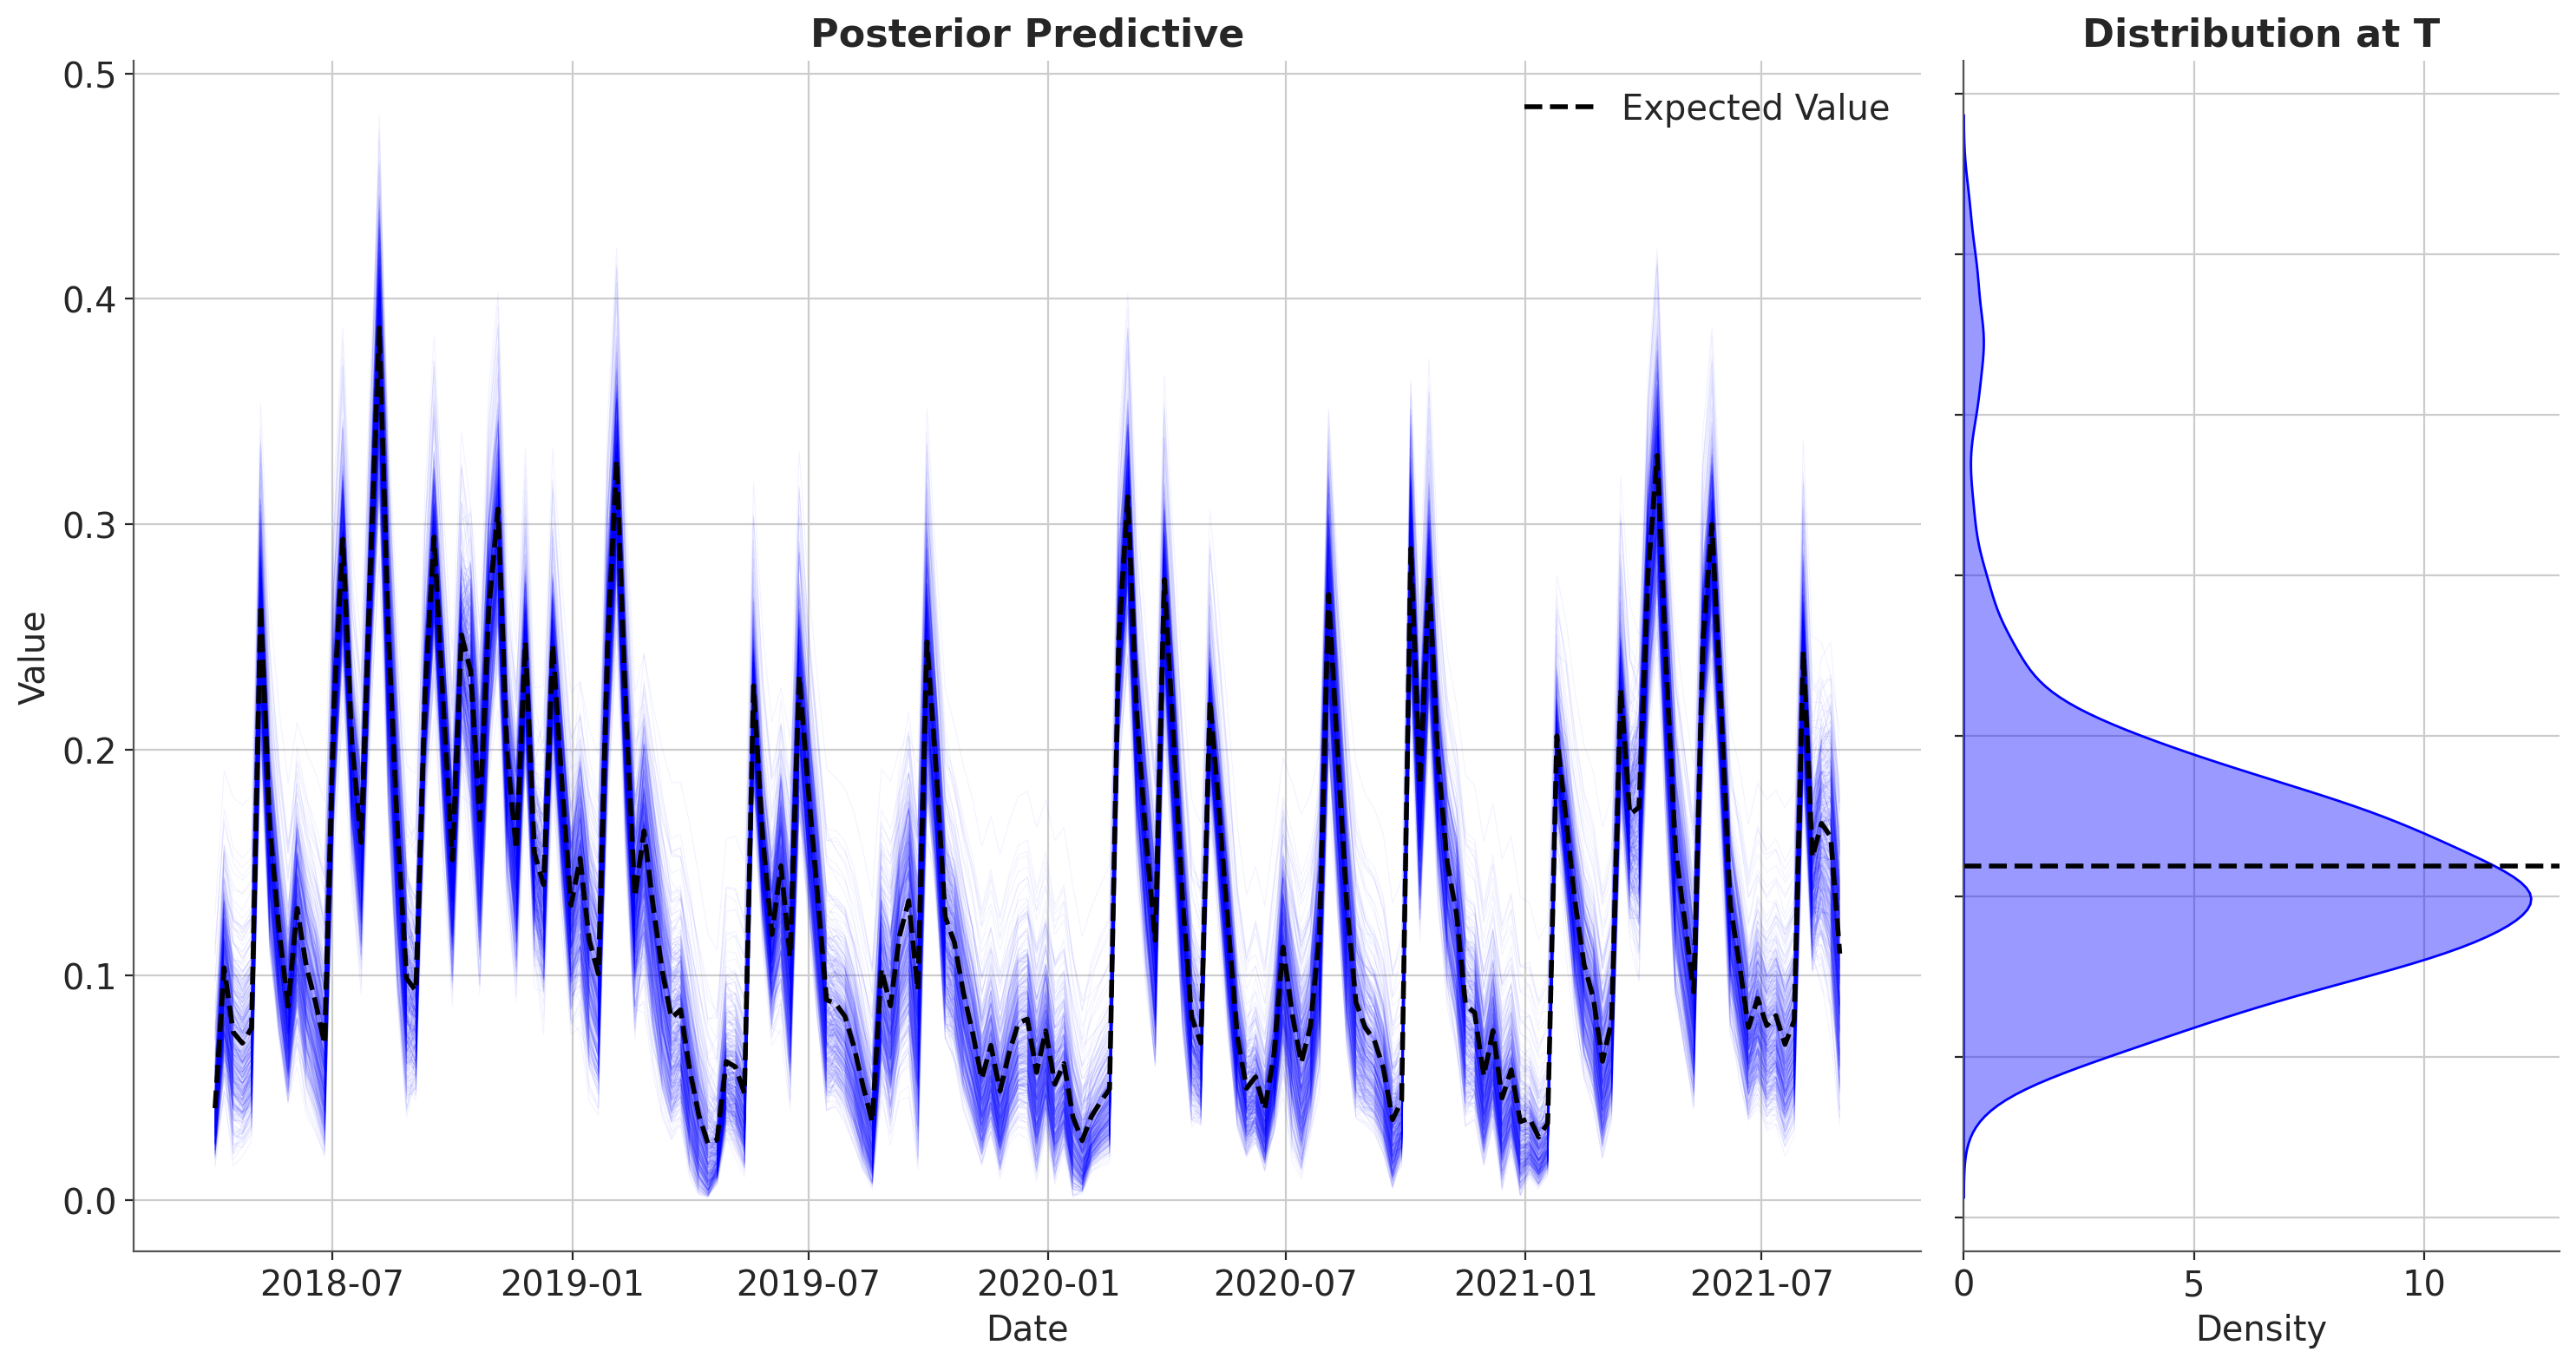

In [15]:
def plot_posterior(
    posterior, figsize=(15, 8), path_color="blue", hist_color="blue", **kwargs
):
    """Plot the posterior distribution of a stochastic process.

    Parameters
    ----------
    posterior : xarray.DataArray
        The posterior distribution with shape (draw, chain, date).
    figsize : tuple
        Size of the figure.
    path_color : str
        Color of the paths in the time series plot.
    hist_color : str
        Color of the histogram.
    **kwargs
        Additional keyword arguments to pass to the plotting functions.
    """
    # Calculate the expected value (mean) across all draws and chains for each date
    expected_value = posterior.mean(dim=("draw", "chain"))
    # Create a figure and a grid of subplots
    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(1, 2, width_ratios=[3, 1])
    # Time series plot
    ax1 = fig.add_subplot(gs[0])
    for chain in range(posterior.shape[1]):
        for draw in range(
            0, posterior.shape[0], 10
        ):  # Plot every 10th draw for performance
            ax1.plot(
                posterior.date,
                posterior[draw, chain],
                color=path_color,
                alpha=0.05,
                linewidth=0.4,
            )
    # Plot expected value with a distinct color
    ax1.plot(
        posterior.date,
        expected_value,
        color="black",
        linestyle="--",
        linewidth=2,
        label="Expected Value",
    )
    ax1.set_title("Posterior Predictive")
    ax1.set_xlabel("Date")
    ax1.set_ylabel("Value")
    ax1.grid(True)
    ax1.legend()
    # KDE plot instead of histogram
    ax2 = fig.add_subplot(gs[1])
    final_values = posterior[:, :, -1].values.flatten()
    sns.kdeplot(
        y=final_values, ax=ax2, color=hist_color, fill=True, alpha=0.4, **kwargs
    )
    # Plot expected value line in KDE plot
    ax2.axhline(
        y=expected_value[-1].values.mean(), color="black", linestyle="--", linewidth=2
    )
    ax2.set_title("Distribution at T")
    ax2.set_xlabel("Density")
    ax2.set_yticklabels([])  # Hide y tick labels to avoid duplication
    ax2.grid(True)
    plt.tight_layout()
    return fig


plot_posterior(
    posterior=basic_mmm.fit_result["channel_contribution"].sum(dim="channel")
);

But why the contributions are over estimated? The contributions are poorly estimated because the parameters of our transformations are also poorly estimated. For example, the parameters that control the maximum effectiveness (At the saturation function) of each channel are much higher than the real ones for both channels.


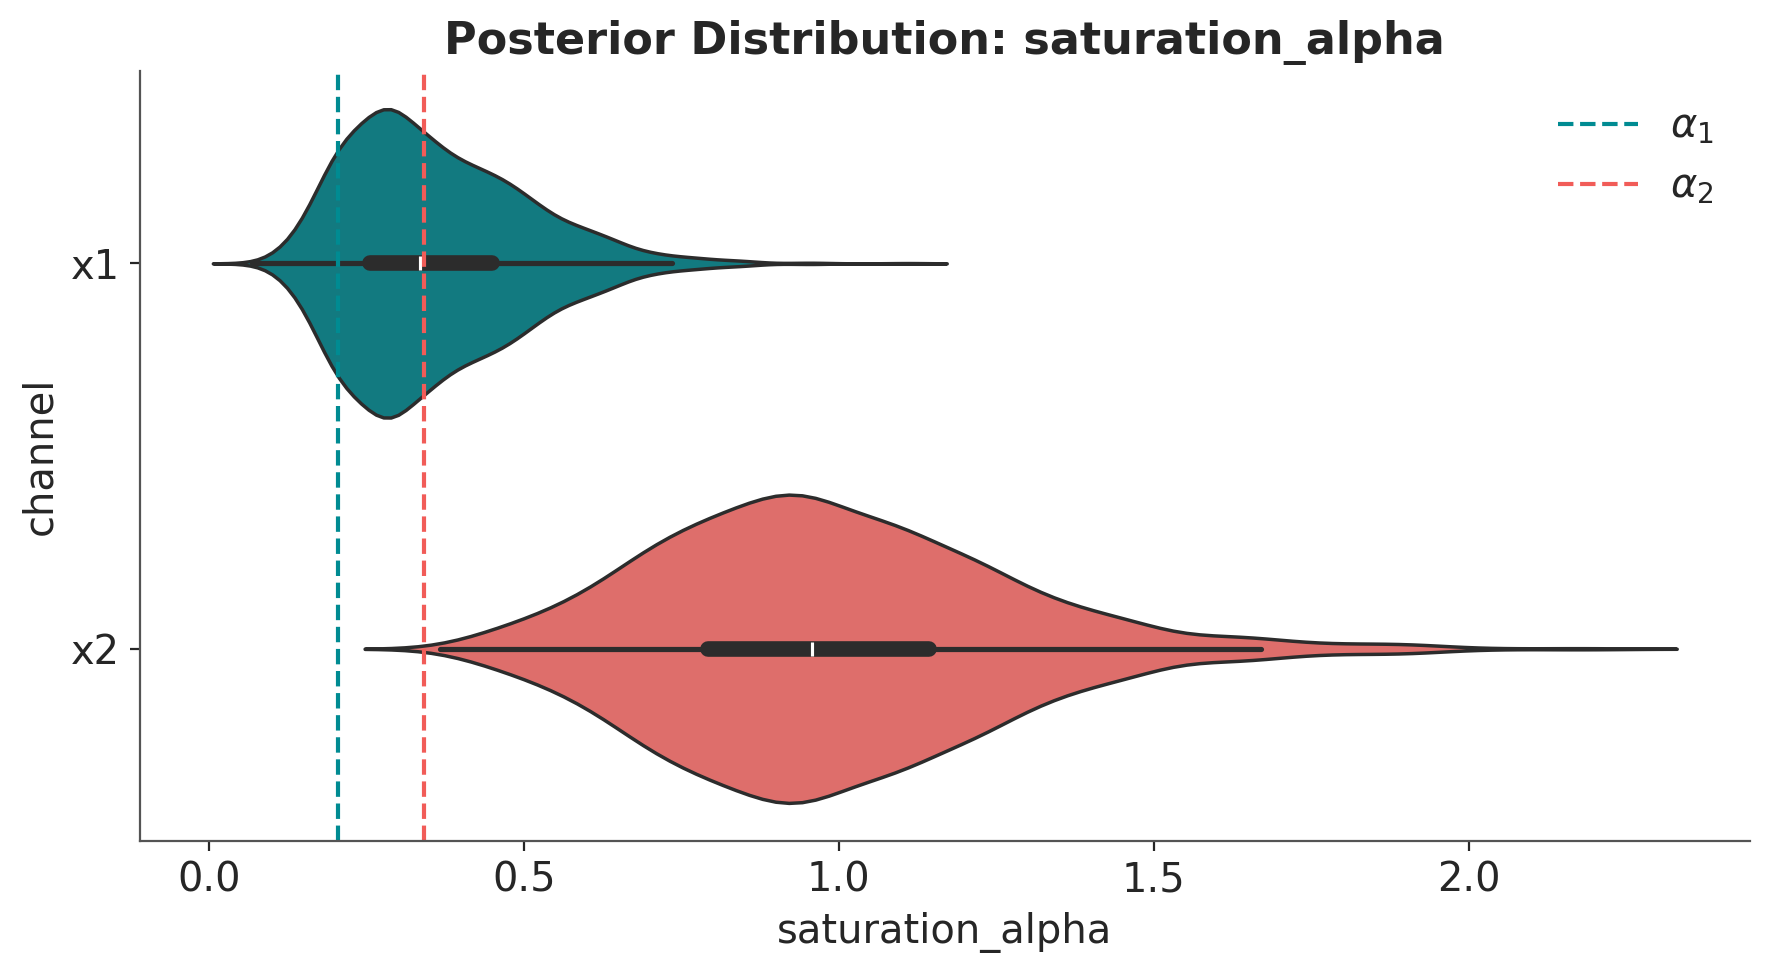

In [16]:
fig = basic_mmm.plot.channel_parameter(param_name="saturation_alpha", figsize=(9, 5))
ax = fig.axes[0]
ax.axvline(
    x=(real_alpha[0] / df.y.max()), color="C0", linestyle="--", label=r"$\alpha_1$"
)
ax.axvline(
    x=(real_alpha[1] / df.y.max()), color="C1", linestyle="--", label=r"$\alpha_2$"
)
ax.legend(loc="upper right");

What would change if we now consider time as a factor in our model?
Now we can do this by adding the following parameter to the initialization of our `time_varying_media` model and changing it to `True`.


In [17]:
from pymc_marketing.hsgp_kwargs import HSGPKwargs

hsgp_kwargs = HSGPKwargs(
    ls_mu=11.0,  # InverseGamma lengthscale prior mean
    ls_sigma=5.0,  # InverseGamma lengthscale prior sigma
)

In [18]:
mmm = MMM(
    date_column="date_week",
    target_column="y",
    channel_columns=["x1", "x2"],
    control_columns=["event_1", "event_2"],
    yearly_seasonality=yearly_seasonality,
    adstock=GeometricAdstock(l_max=adstock_max_lag).set_dims_for_all_priors("channel"),
    saturation=MichaelisMentenSaturation().set_dims_for_all_priors("channel"),
    time_varying_media=True,  # 1. Enable the feature
    model_config={"media_tvp_config": hsgp_kwargs},
)

```{note}
By doing this, now our model config will have a new key `media_tvp_config` with the parameters that control the priors of our HSGP.
```


In [19]:
mmm.model_config["media_tvp_config"]

HSGPKwargs(m=200, L=None, eta_lam=1.0, ls_mu=11.0, ls_sigma=5.0, cov_func=None)

In [20]:
mmm.fit(
    X=X,
    y=y,
    target_accept=0.92,
    draws=500,
    random_seed=rng,
)

NUTS[nutpie]: [media_temporal_latent_multiplier_raw_hsgp_coefs_offset, media_temporal_latent_multiplier_raw_eta, media_temporal_latent_multiplier_raw_ls, adstock_alpha, saturation_lam, saturation_alpha, gamma_fourier, gamma_control, y_sigma, intercept_contribution]


Output()

Output()

<xarray.DataTree>
Group: /
│   Attributes: (12/24)
│       id:                         21963e7e1f0db60c
│       model_type:                 MMMM (Multi-Dimensional Marketing Mix Model)
│       version:                    0.0.2
│       sampler_config:             {}
│       model_config:               {"intercept": {"dist": "Normal", "kwargs": {"...
│       __serialization_version__:  1
│       ...                         ...
│       scaling:                    {"__type__": "pymc_marketing.mmm.scaling.Scal...
│       dag:                        null
│       treatment_nodes:            null
│       outcome_node:               null
│       mu_effects:                 []
│       cost_per_unit:              null
├── Group: /posterior
│       Dimensions:                                                 (chain: 4,
│                                                                    draw: 500,
│                                                                    media_temporal_latent_multiplier_raw_m: 200,
│                                                                    fourier_mode: 4,
│                                                                    control: 2,
│                                                                    channel: 2,
│                                                                    date: 179)
│       Coordinates:
│         * chain                                                   (chain) int64 32B ...
│         * draw                                                    (draw) int64 4kB ...
│         * media_temporal_latent_multiplier_raw_m                  (media_temporal_latent_multiplier_raw_m) int64 2kB ...
│         * fourier_mode                                            (fourier_mode) object 32B ...
│         * control                                                 (control) object 16B ...
│         * channel                                                 (channel) object 16B ...
│         * date                                                    (date) datetime64[ns] 1kB ...
│       Data variables: (12/20)
│           media_temporal_latent_multiplier_raw_hsgp_coefs_offset  (chain, draw, media_temporal_latent_multiplier_raw_m) float64 3MB ...
│           gamma_fourier                                           (chain, draw, fourier_mode) float64 64kB ...
│           gamma_control                                           (chain, draw, control) float64 32kB ...
│           intercept_contribution                                  (chain, draw) float64 16kB ...
│           media_temporal_latent_multiplier_raw_eta                (chain, draw) float64 16kB ...
│           media_temporal_latent_multiplier_raw_ls                 (chain, draw) float64 16kB ...
│           ...                                                      ...
│           channel_contribution                                    (chain, draw, date, channel) float64 6MB ...
│           media_temporal_latent_multiplier                        (chain, draw, date) float64 3MB ...
│           media_temporal_latent_multiplier_f_mean                 (chain, draw) float64 16kB ...
│           media_temporal_latent_multiplier_raw                    (chain, draw, date) float64 3MB ...
│           media_temporal_latent_multiplier_raw_hsgp_coefs         (chain, draw, media_temporal_latent_multiplier_raw_m) float64 3MB ...
│           baseline_channel_contribution                           (chain, draw, date, channel) float64 6MB ...
│       Attributes:
│           created_at:                 2026-07-08T08:12:58.230722+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           sample_dims:                ['chain', 'draw']
│           inference_library:          nutpie
│           inference_library_version:  0.16.10
│           sampling_time:              1.6581308841705322
│           tuning_steps:               400
│           pymc_marketing_version:

We got less divergences, this is a good sign! 🚀 
Let's check our samples!


In [21]:
az.summary(
    data=mmm.fit_result,
    var_names=[
        "intercept_contribution",
        "y_sigma",
        "gamma_control",
        "gamma_fourier",
    ],
)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
intercept_contribution,0.4126,0.0075,0.4,0.42,274,367,1.01,0.00045,0.00032
y_sigma,0.0166,0.00094,0.015,0.018,2505,1316,1.00,1.9e-05,1.5e-05
gamma_control[event_1],-0.2512,0.0175,-0.28,-0.22,2369,1319,1.00,0.00036,0.00026
gamma_control[event_2],0.4321,0.0171,0.4,0.46,3059,1571,1.00,0.00031,0.00021
gamma_fourier[sin_1],0.1693,0.0031,0.16,0.17,666,896,1.00,0.00012,9.6e-05
gamma_fourier[sin_2],-0.03236,0.00194,-0.035,-0.029,1990,1486,1.00,4.4e-05,3.3e-05
gamma_fourier[cos_1],0.1003,0.0028,0.096,0.1,1019,1152,1.00,8.7e-05,6.8e-05
gamma_fourier[cos_2],0.172,0.00198,0.17,0.18,1429,1486,1.00,5.2e-05,3.6e-05


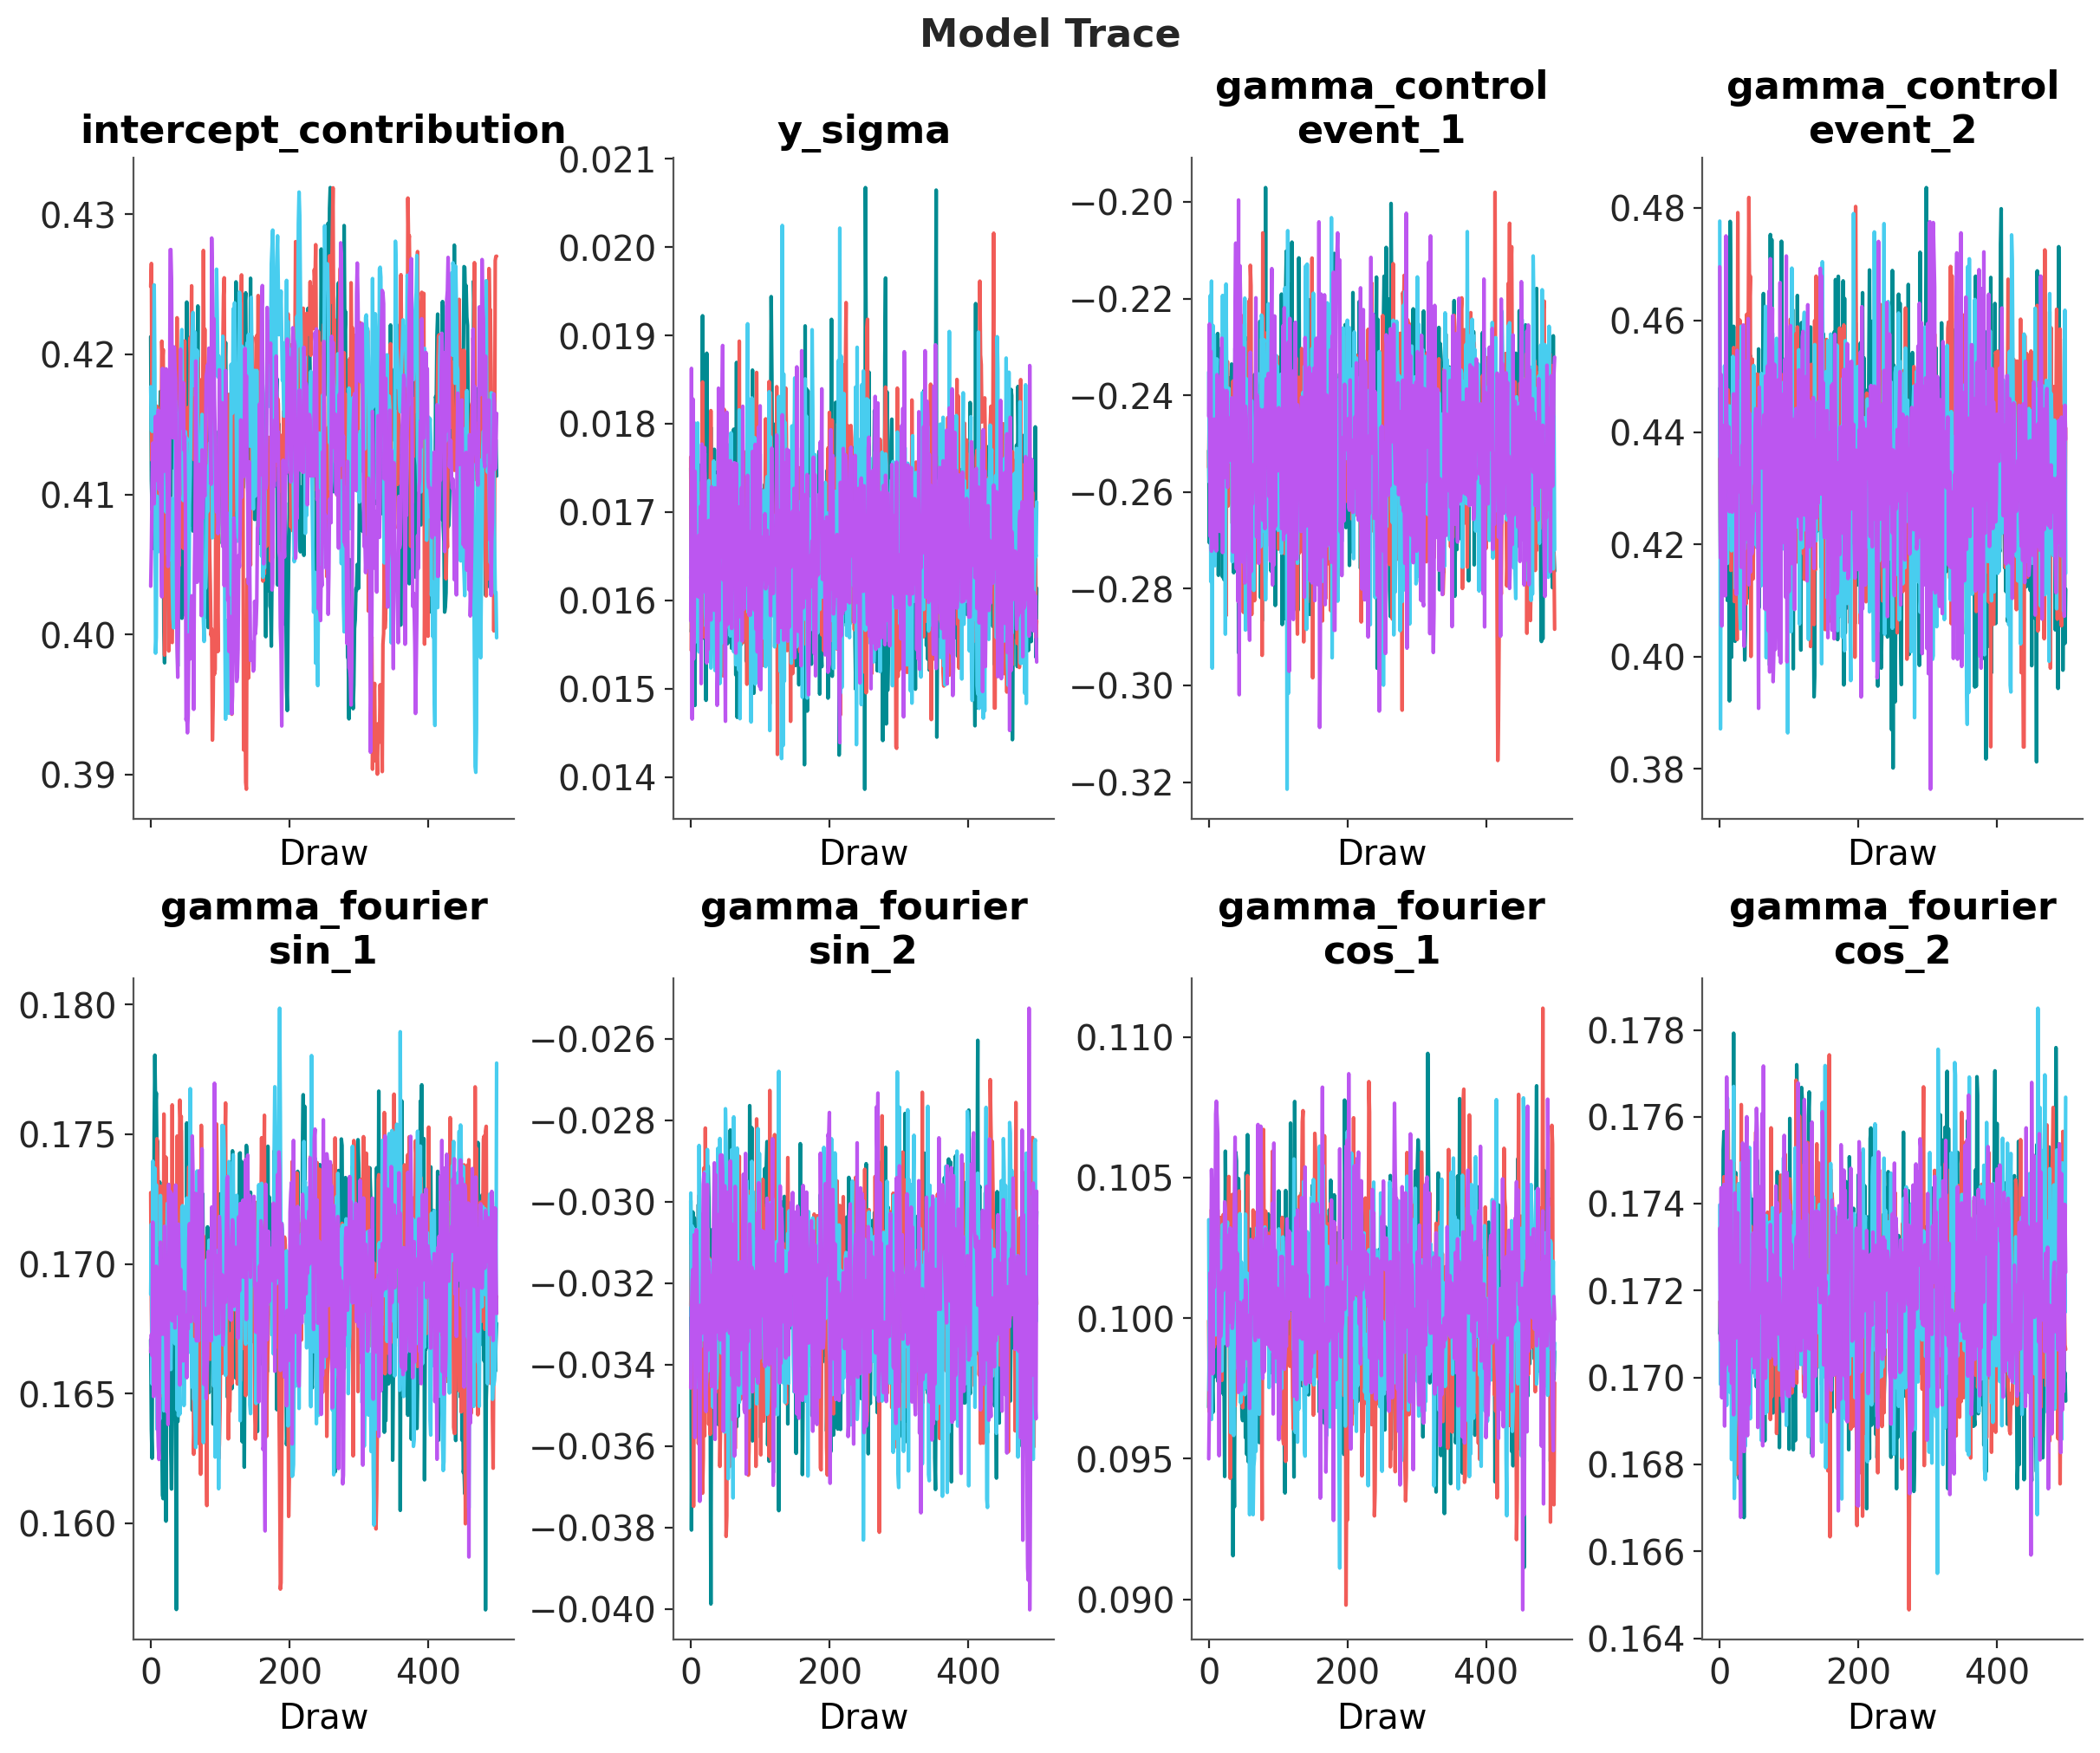

In [22]:
_ = azp.plot_trace(
    mmm.fit_result,
    var_names=[
        "intercept_contribution",
        "y_sigma",
        "gamma_control",
        "gamma_fourier",
    ],
    figure_kwargs={"figsize": (12, 10), "layout": "constrained"},
)
plt.gcf().suptitle("Model Trace", fontsize=16);

In [23]:
az.summary(
    data=mmm.fit_result,
    var_names=["adstock_alpha", "saturation_lam", "saturation_alpha"],
)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
adstock_alpha[x1],0.499,0.037,0.44,0.56,573,844,1.01,0.0016,0.0011
adstock_alpha[x2],0.345,0.029,0.3,0.39,194,273,1.01,0.0021,0.0016
saturation_lam[x1],0.32,0.08,0.21,0.47,182,234,1.01,0.006,0.0047
saturation_lam[x2],0.37,0.082,0.24,0.51,168,204,1.01,0.0062,0.0044
saturation_alpha[x1],0.186,0.016,0.16,0.21,233,283,1.01,0.001,0.00082
saturation_alpha[x2],0.257,0.026,0.22,0.3,166,214,1.01,0.002,0.0014


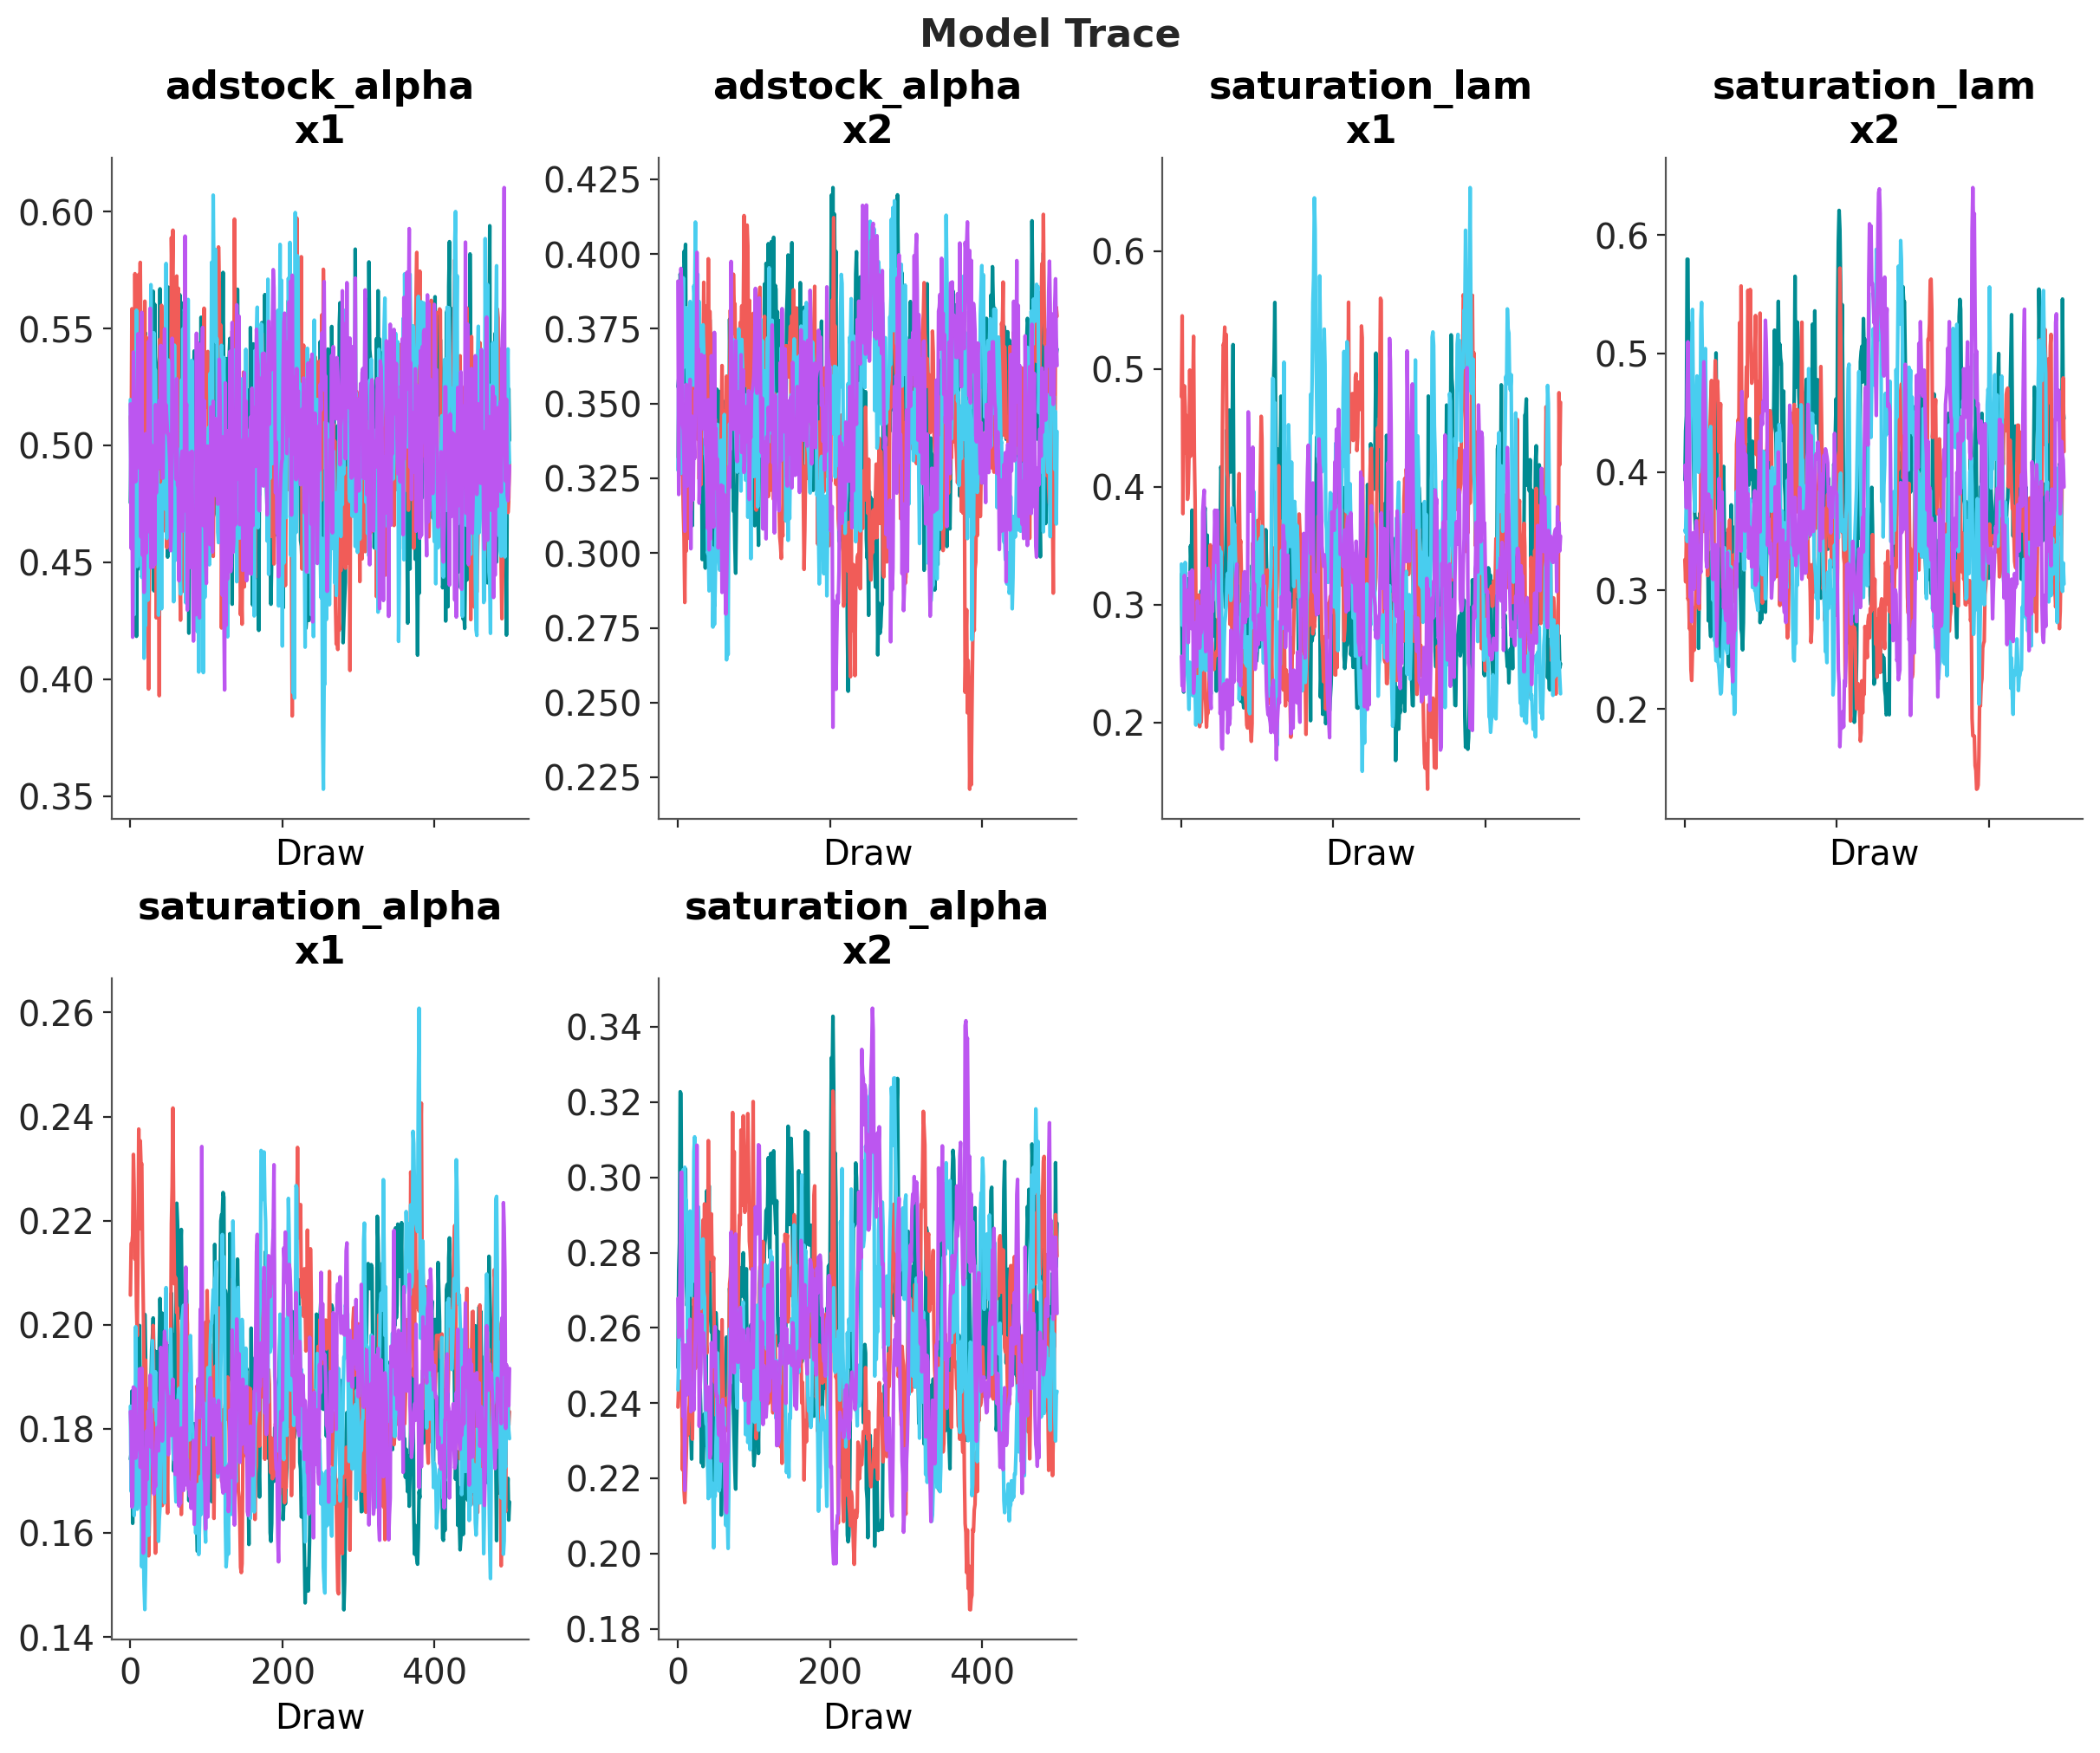

In [24]:
_ = azp.plot_trace(
    mmm.fit_result,
    var_names=["adstock_alpha", "saturation_lam", "saturation_alpha"],
    figure_kwargs={"figsize": (12, 10), "layout": "constrained"},
)
plt.gcf().suptitle("Model Trace", fontsize=16);

In [25]:
az.summary(
    data=mmm.fit_result,
    var_names=[
        "media_temporal_latent_multiplier_raw_eta",
        "media_temporal_latent_multiplier_raw_ls",
        "media_temporal_latent_multiplier_raw_hsgp_coefs",
    ],
)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
media_temporal_latent_multiplier_raw_eta,0.7,0.4,0.33,1.4,46,87,1.08,0.054,0.081
media_temporal_latent_multiplier_raw_ls,55,20,30,91,81,166,1.06,2.1,1.8
media_temporal_latent_multiplier_raw_hsgp_coefs[0],1,9,-9.4,16,148,116,1.03,1,1.9
media_temporal_latent_multiplier_raw_hsgp_coefs[1],6.4,2.1,3.7,10,150,164,1.03,0.2,0.24
media_temporal_latent_multiplier_raw_hsgp_coefs[2],5.9,3,2.2,11,93,136,1.02,0.39,0.78
...,...,...,...,...,...,...,...,...,...
media_temporal_latent_multiplier_raw_hsgp_coefs[195],1e-06,0.000164,-0.00023,0.00022,4308,1035,1.01,2.3e-06,4e-06
media_temporal_latent_multiplier_raw_hsgp_coefs[196],-5e-06,0.00017,-0.00026,0.00023,3404,1001,1.01,3e-06,5.1e-06
media_temporal_latent_multiplier_raw_hsgp_coefs[197],-3e-06,0.00016,-0.00024,0.00022,2891,1113,1.00,3.3e-06,5.9e-06
media_temporal_latent_multiplier_raw_hsgp_coefs[198],2e-06,0.000153,-0.0002,0.00021,3218,1109,1.00,2.7e-06,4.5e-06


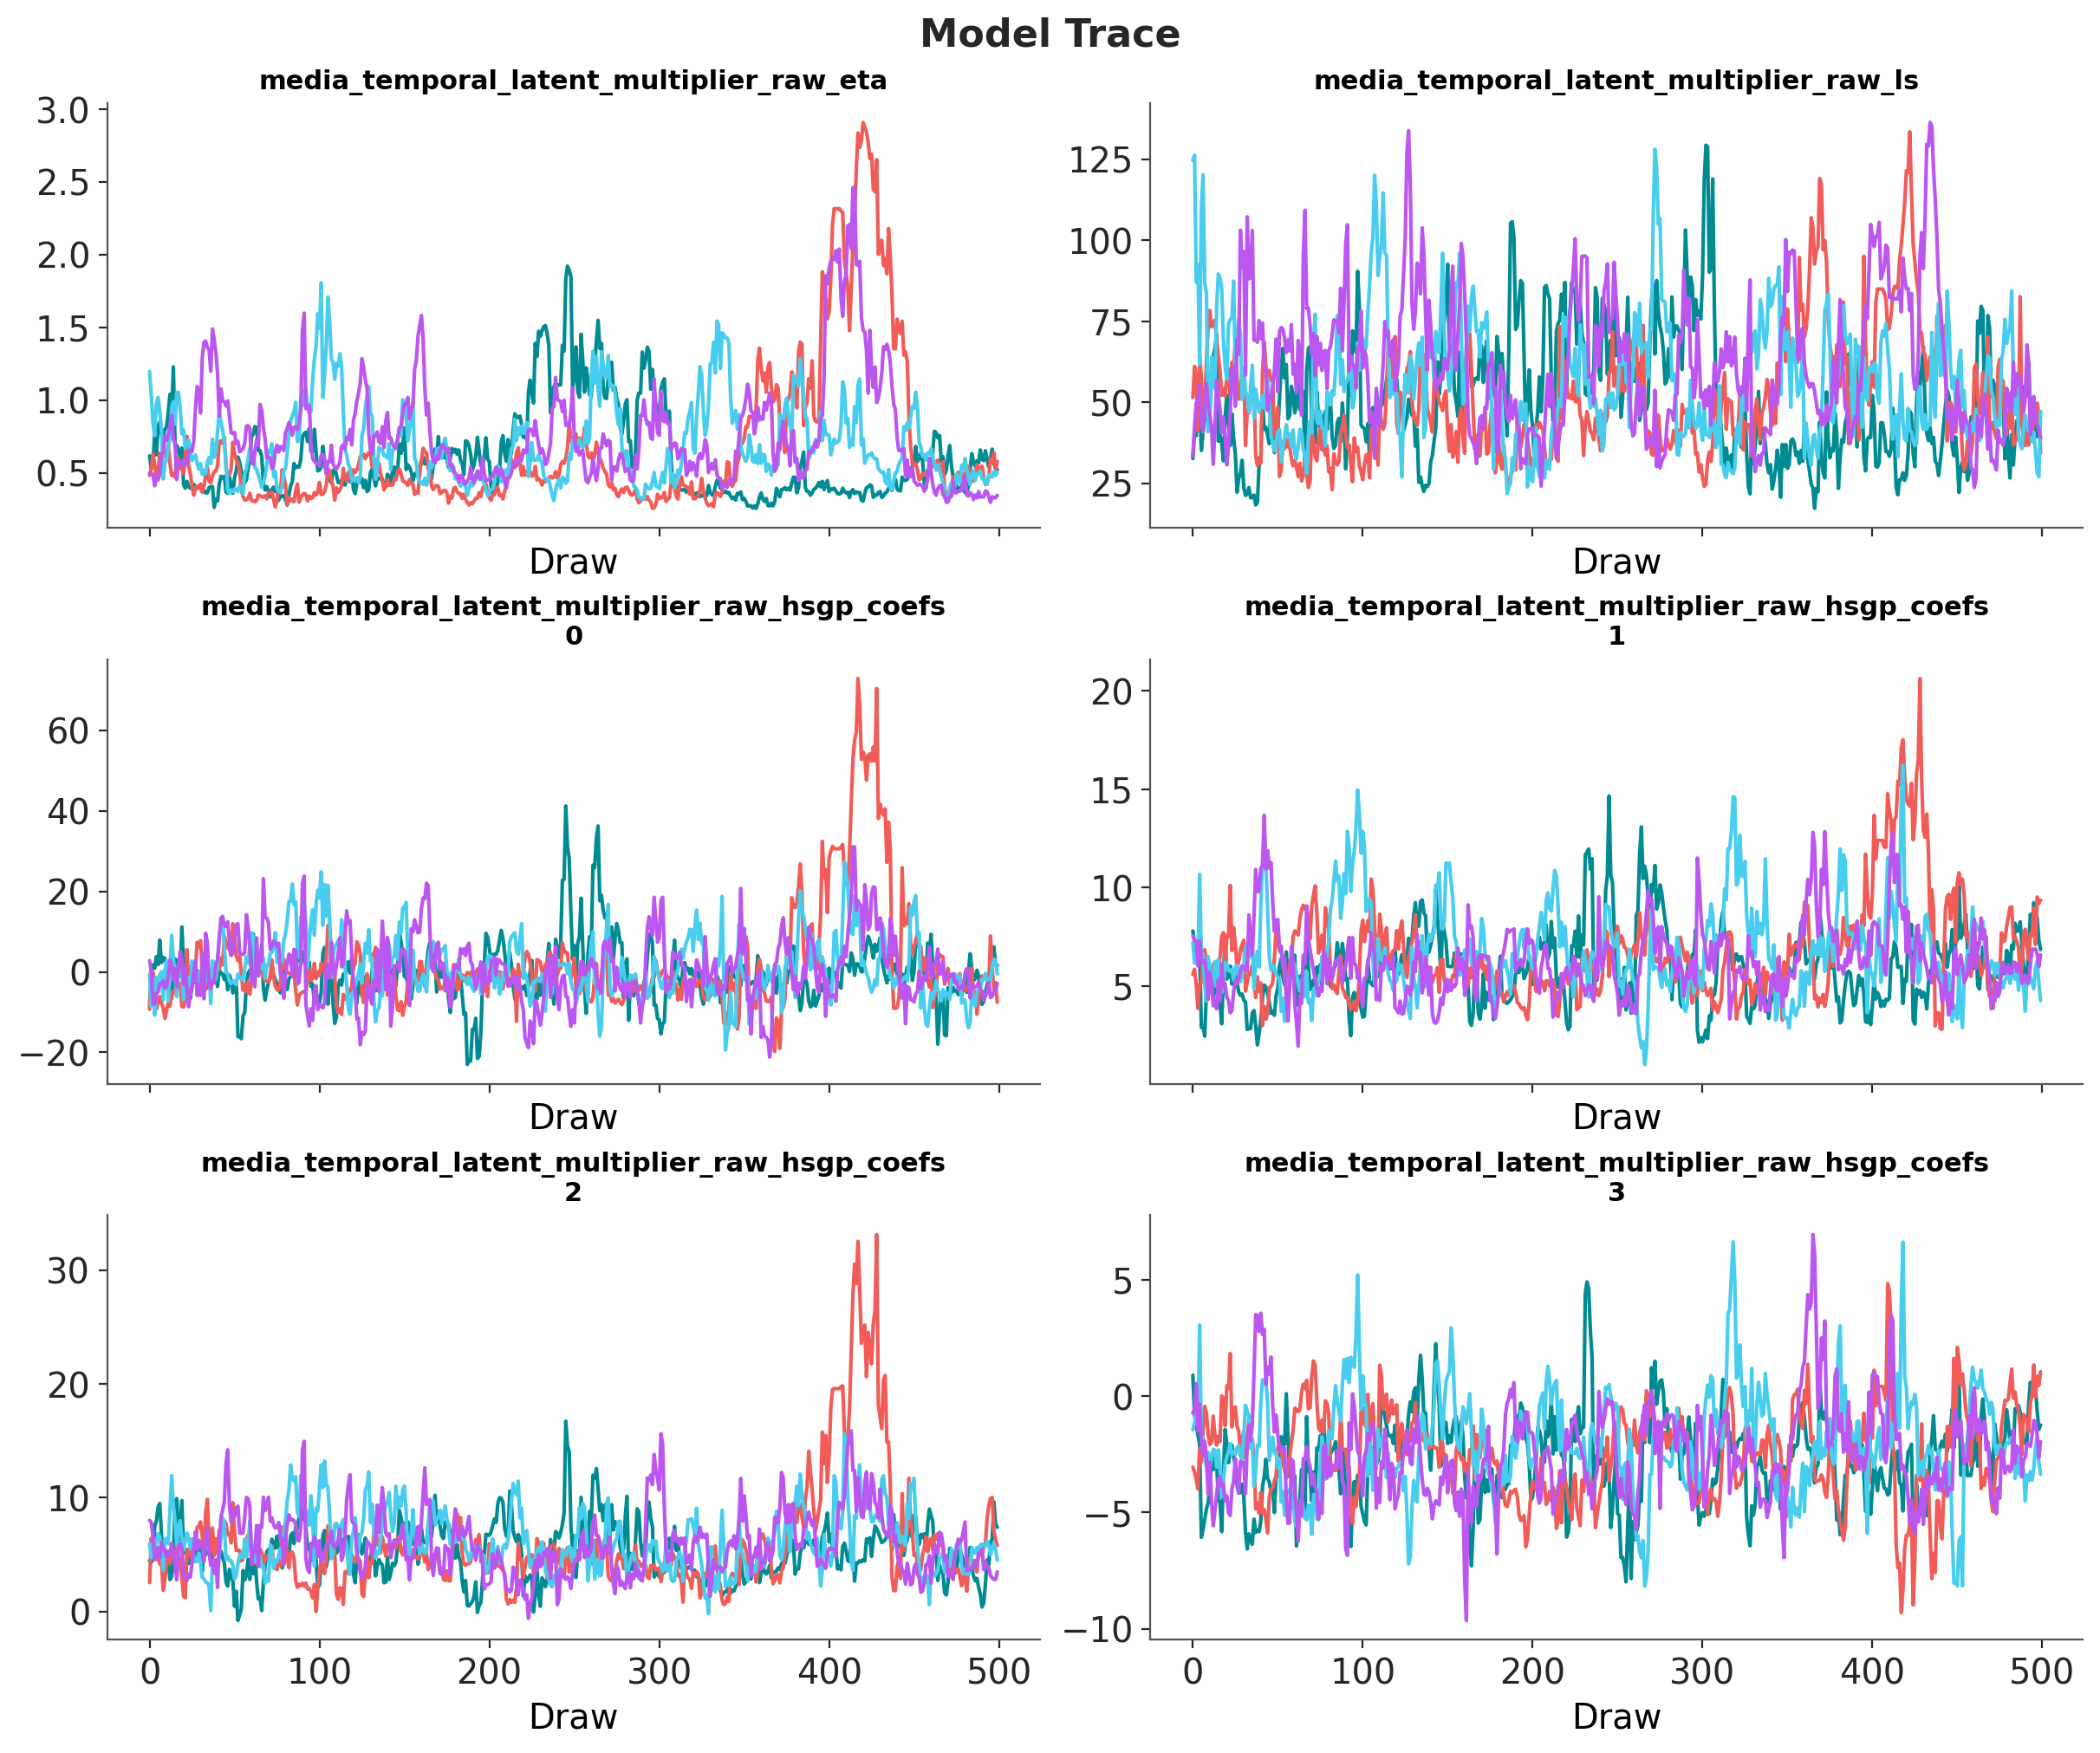

In [26]:
_ = azp.plot_trace(
    mmm.fit_result,
    var_names=[
        "media_temporal_latent_multiplier_raw_eta",
        "media_temporal_latent_multiplier_raw_ls",
        "media_temporal_latent_multiplier_raw_hsgp_coefs",
    ],
    coords={"media_temporal_latent_multiplier_raw_m": [0, 1, 2, 3]},
    col_wrap=2,
    visuals={"title": {"fontsize": 11}},
    figure_kwargs={"figsize": (12, 10), "layout": "constrained"},
)
plt.gcf().suptitle("Model Trace", fontsize=16);

Everything seems fine for now, there is nothing that raises red flags when analyzing our trace. But what about the decomposition?


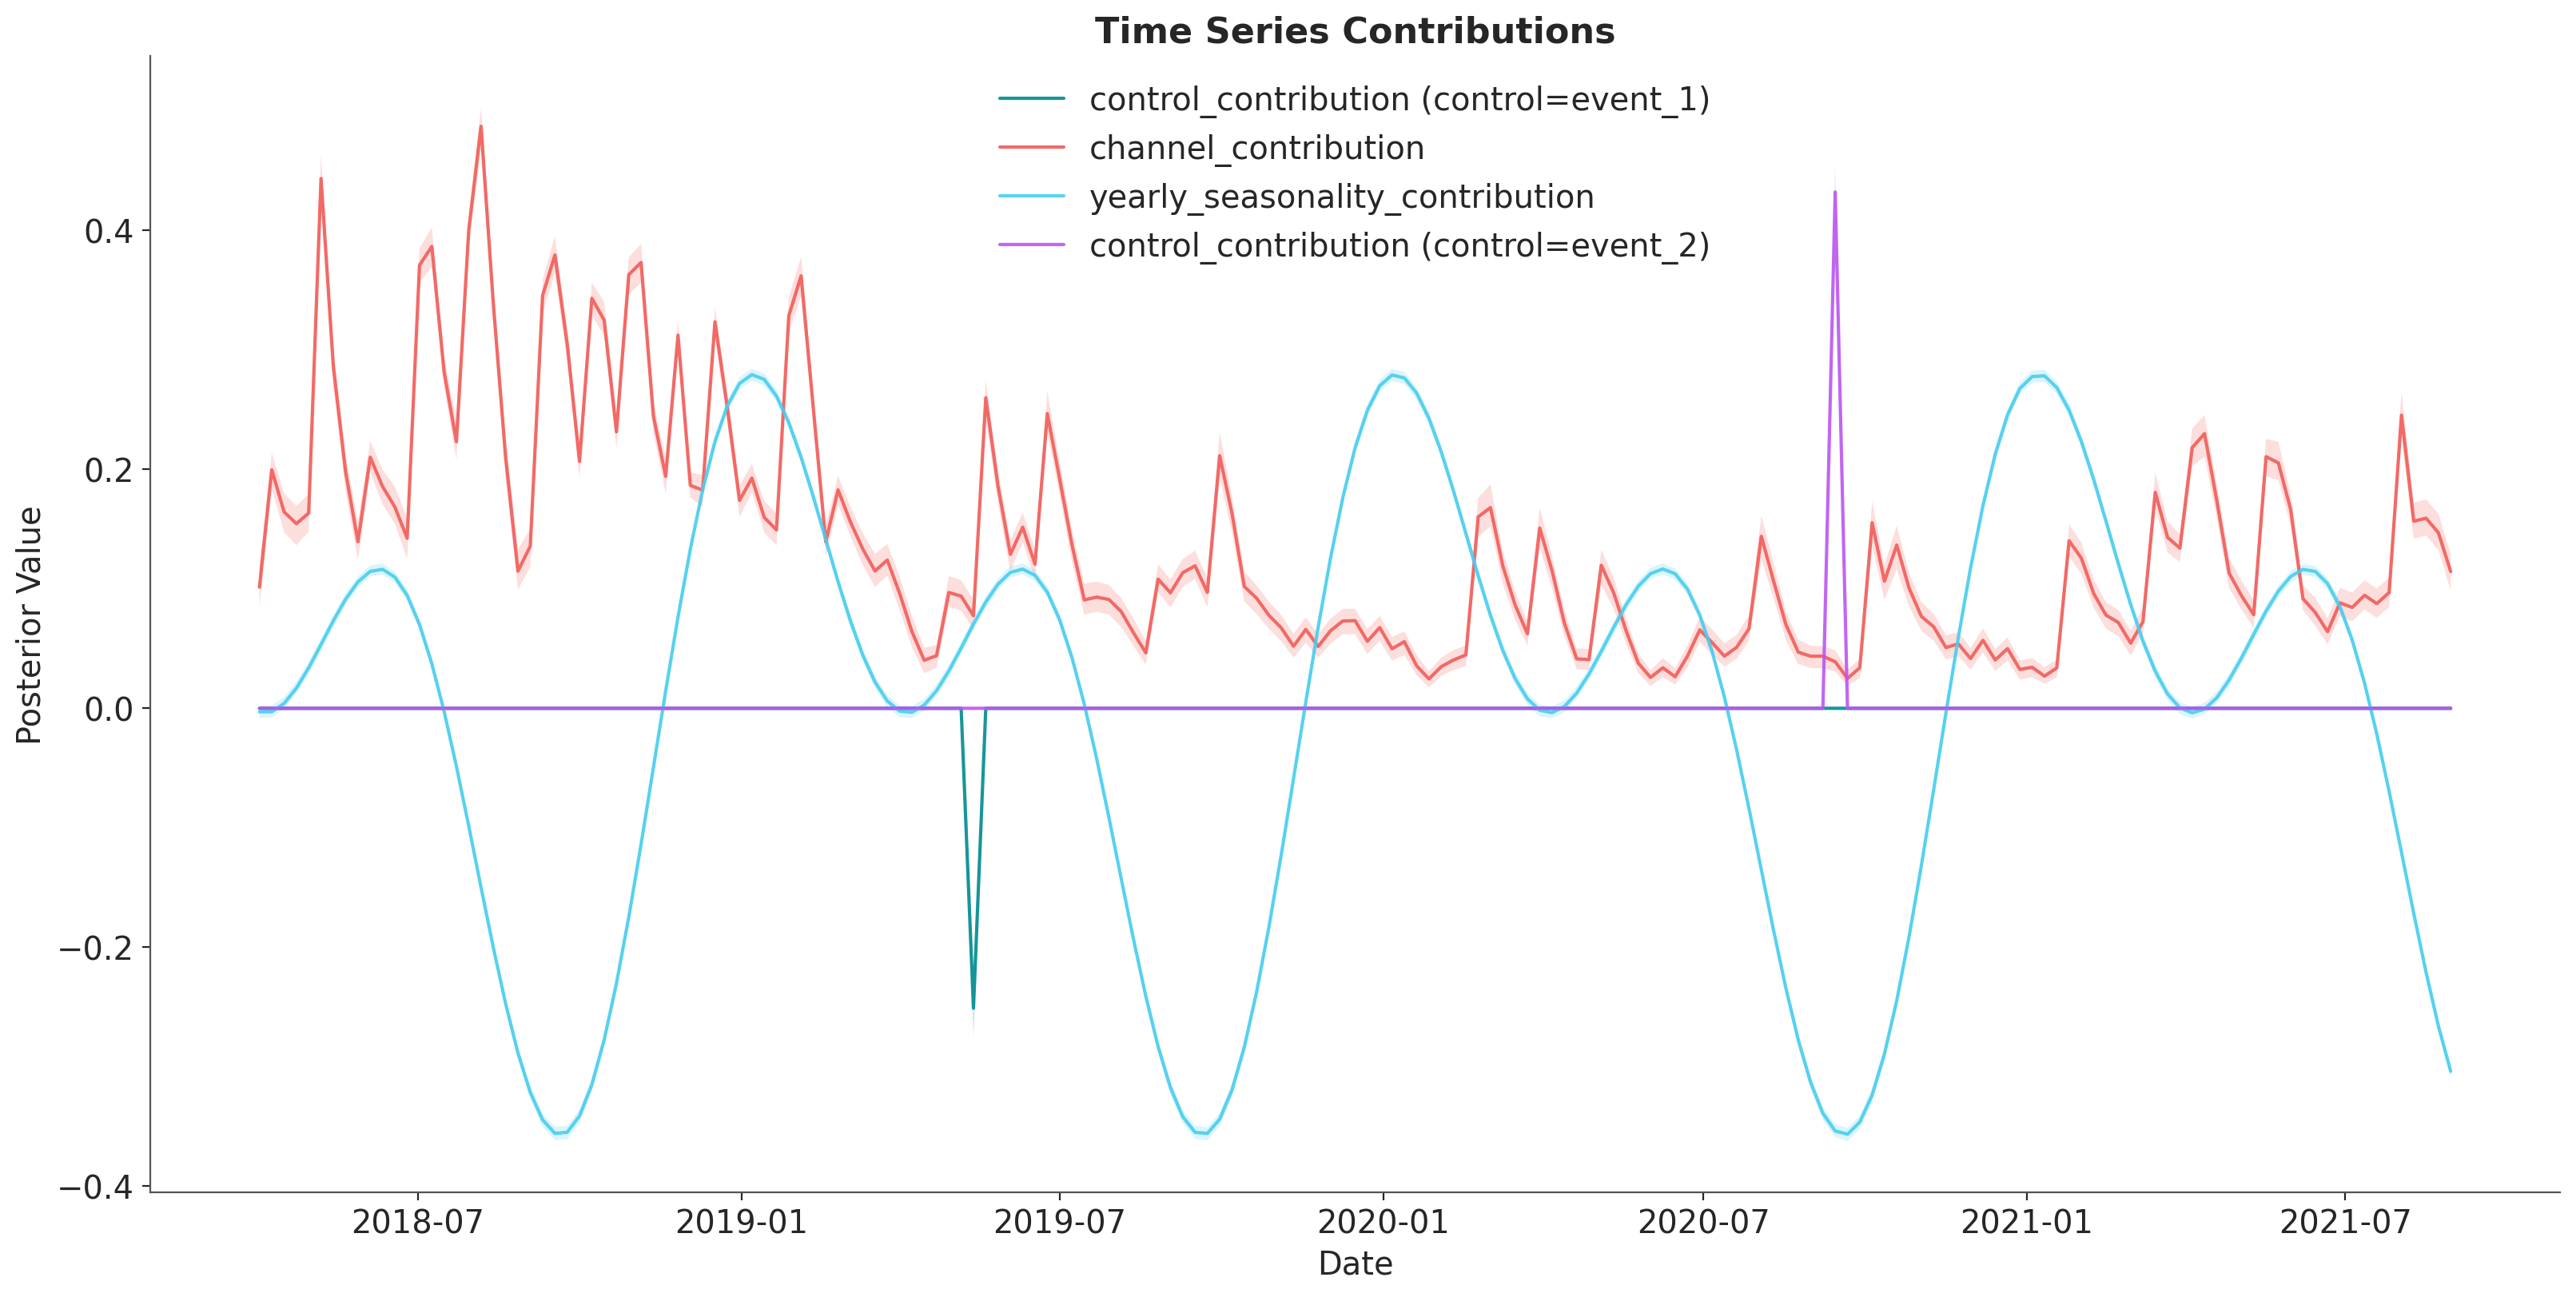

In [27]:
mmm.plot.contributions_over_time(
    var=[
        "control_contribution",
        "channel_contribution",
        "yearly_seasonality_contribution",
    ],
    combine_dims=True,
    figsize=(16, 8),
);

The decomposition looks much better now 🔥 It seems that we are estimating each parameter better, and there are no obvious trade-offs between components!
Let's see how well the original parameters have managed to be recovered?


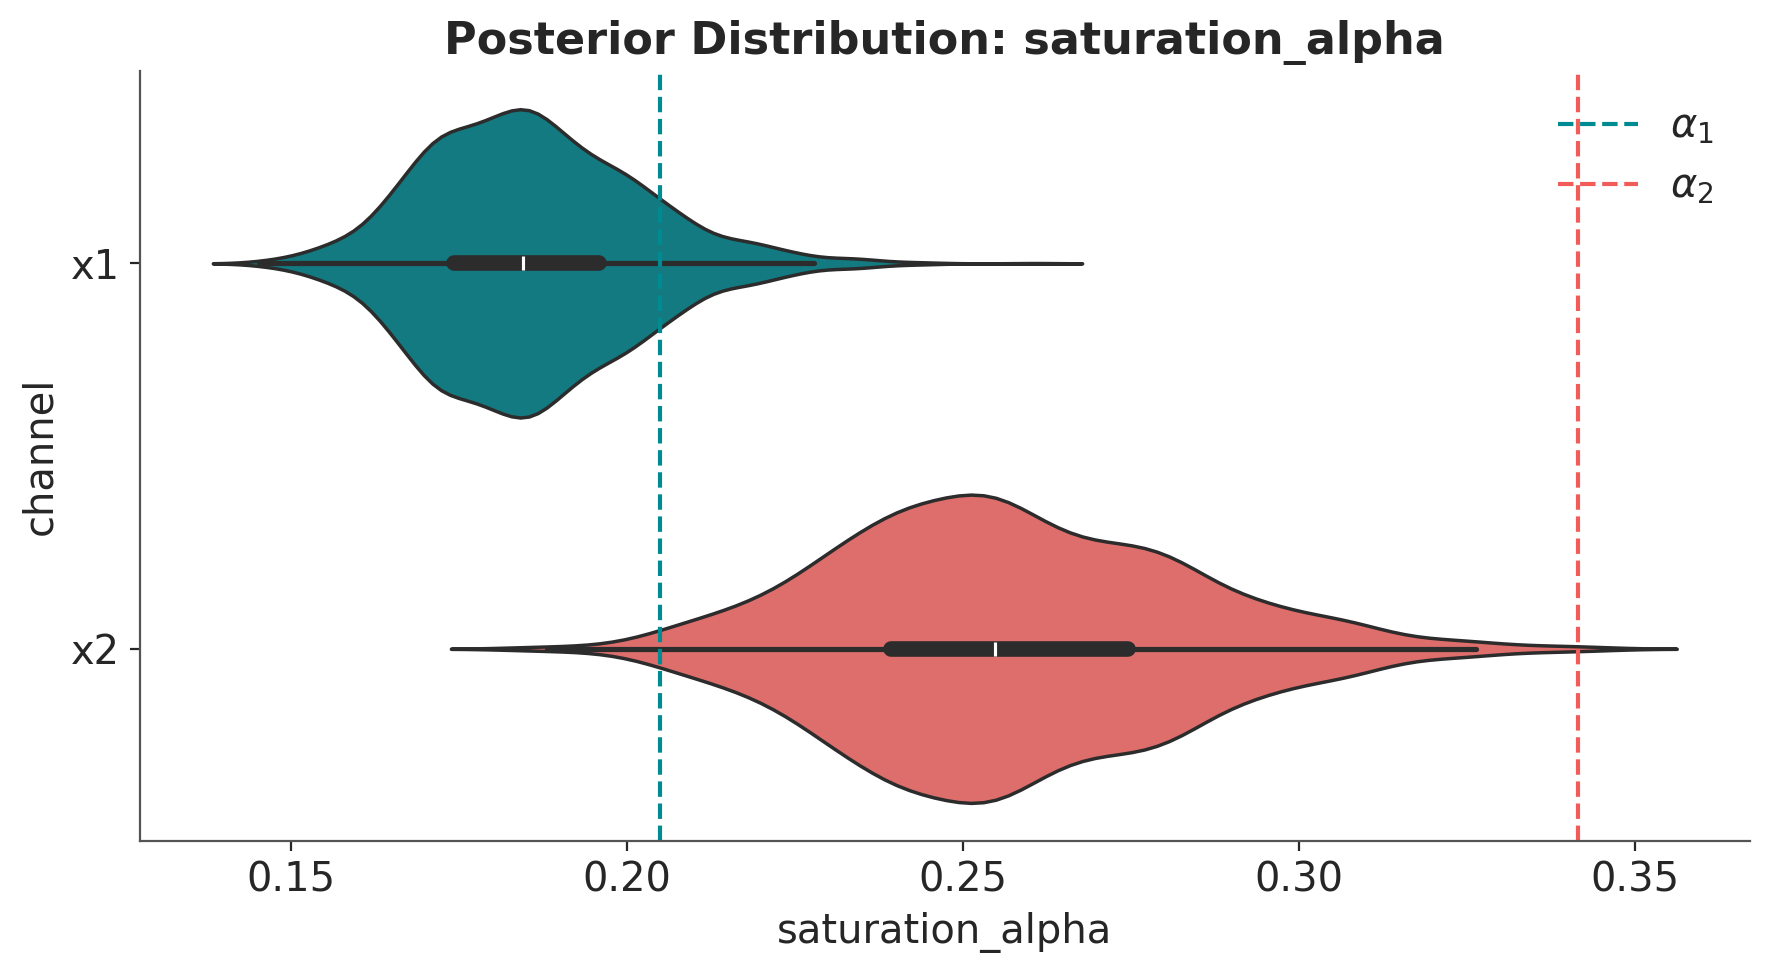

In [28]:
fig = mmm.plot.channel_parameter(param_name="saturation_alpha", figsize=(9, 5))
ax = fig.axes[0]
ax.axvline(
    x=(real_alpha[0] / df.y.max()), color="C0", linestyle="--", label=r"$\alpha_1$"
)
ax.axvline(
    x=(real_alpha[1] / df.y.max()), color="C1", linestyle="--", label=r"$\alpha_2$"
)
ax.legend(loc="upper right");

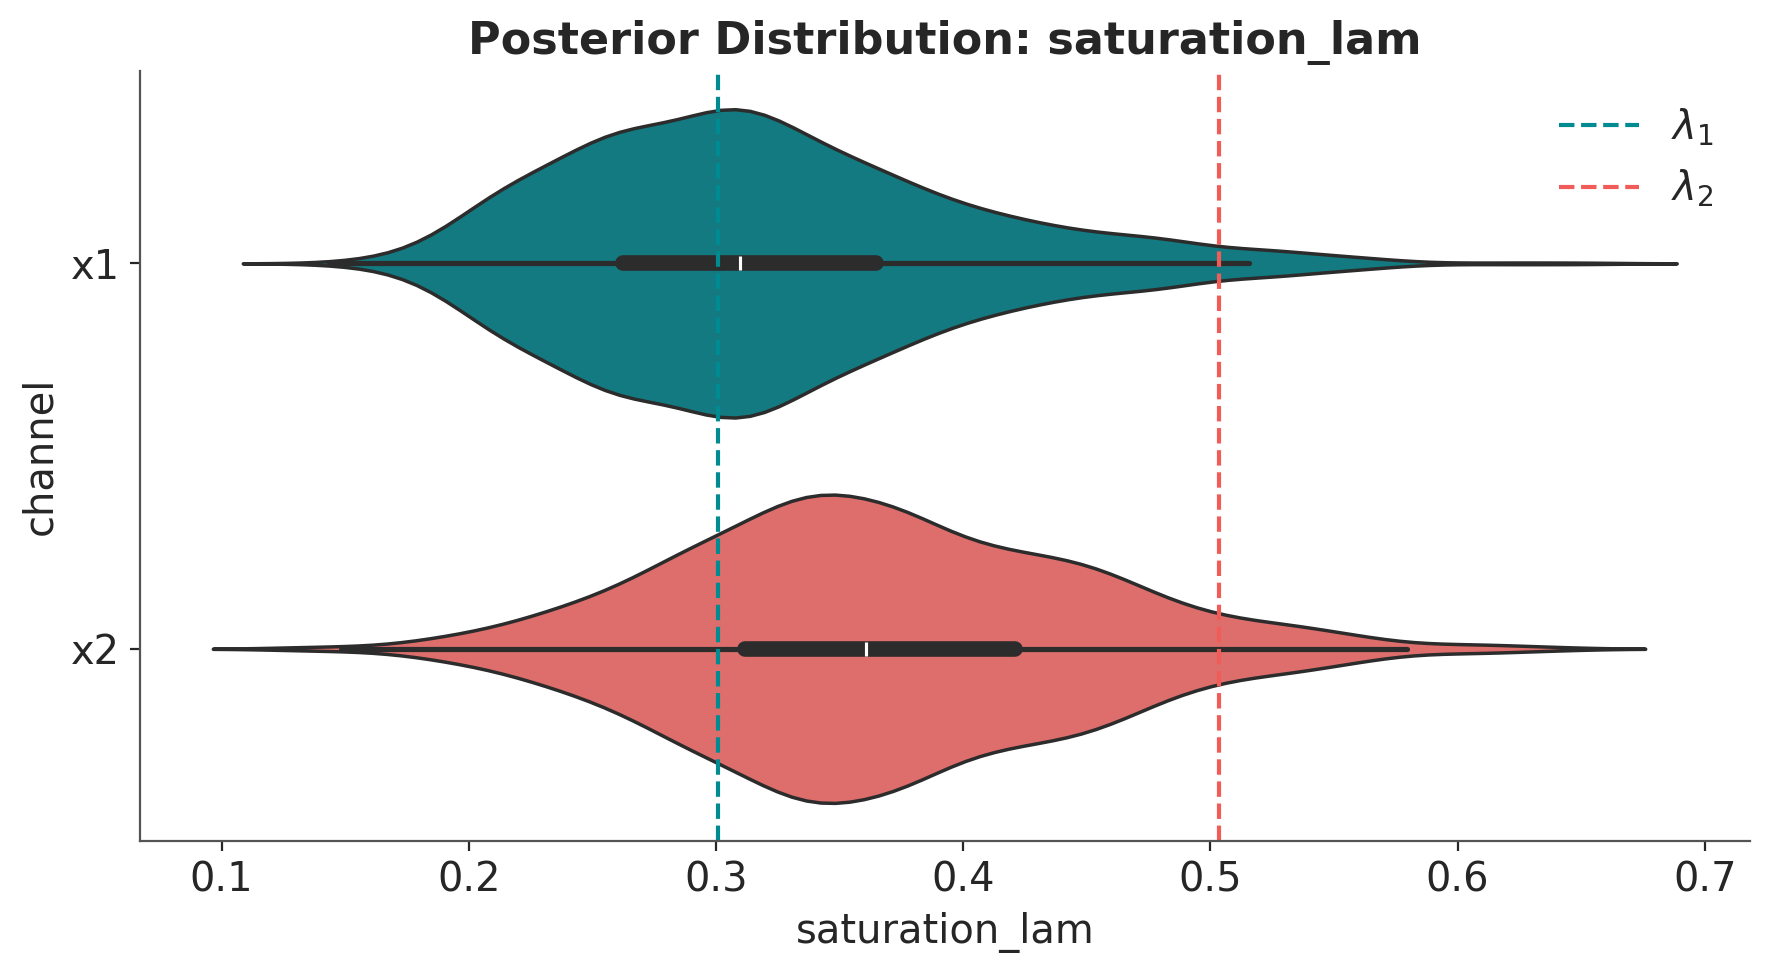

In [29]:
fig = mmm.plot.channel_parameter(param_name="saturation_lam", figsize=(9, 5))
ax = fig.axes[0]
ax.axvline(
    x=(real_lam[0] / df.x1.max()), color="C0", linestyle="--", label=r"$\lambda_1$"
)
ax.axvline(
    x=(real_lam[1] / df.x2.max()), color="C1", linestyle="--", label=r"$\lambda_2$"
)
ax.legend(loc="upper right");

The parameters of the saturation function seem to be recovered practically in their entirety for both channels! This is great 🎉
Let's see how much we manage to recover from the true variation. We can analyze the variable `media_temporal_latent_multiplier` and compare it against the original variable used in the original process.


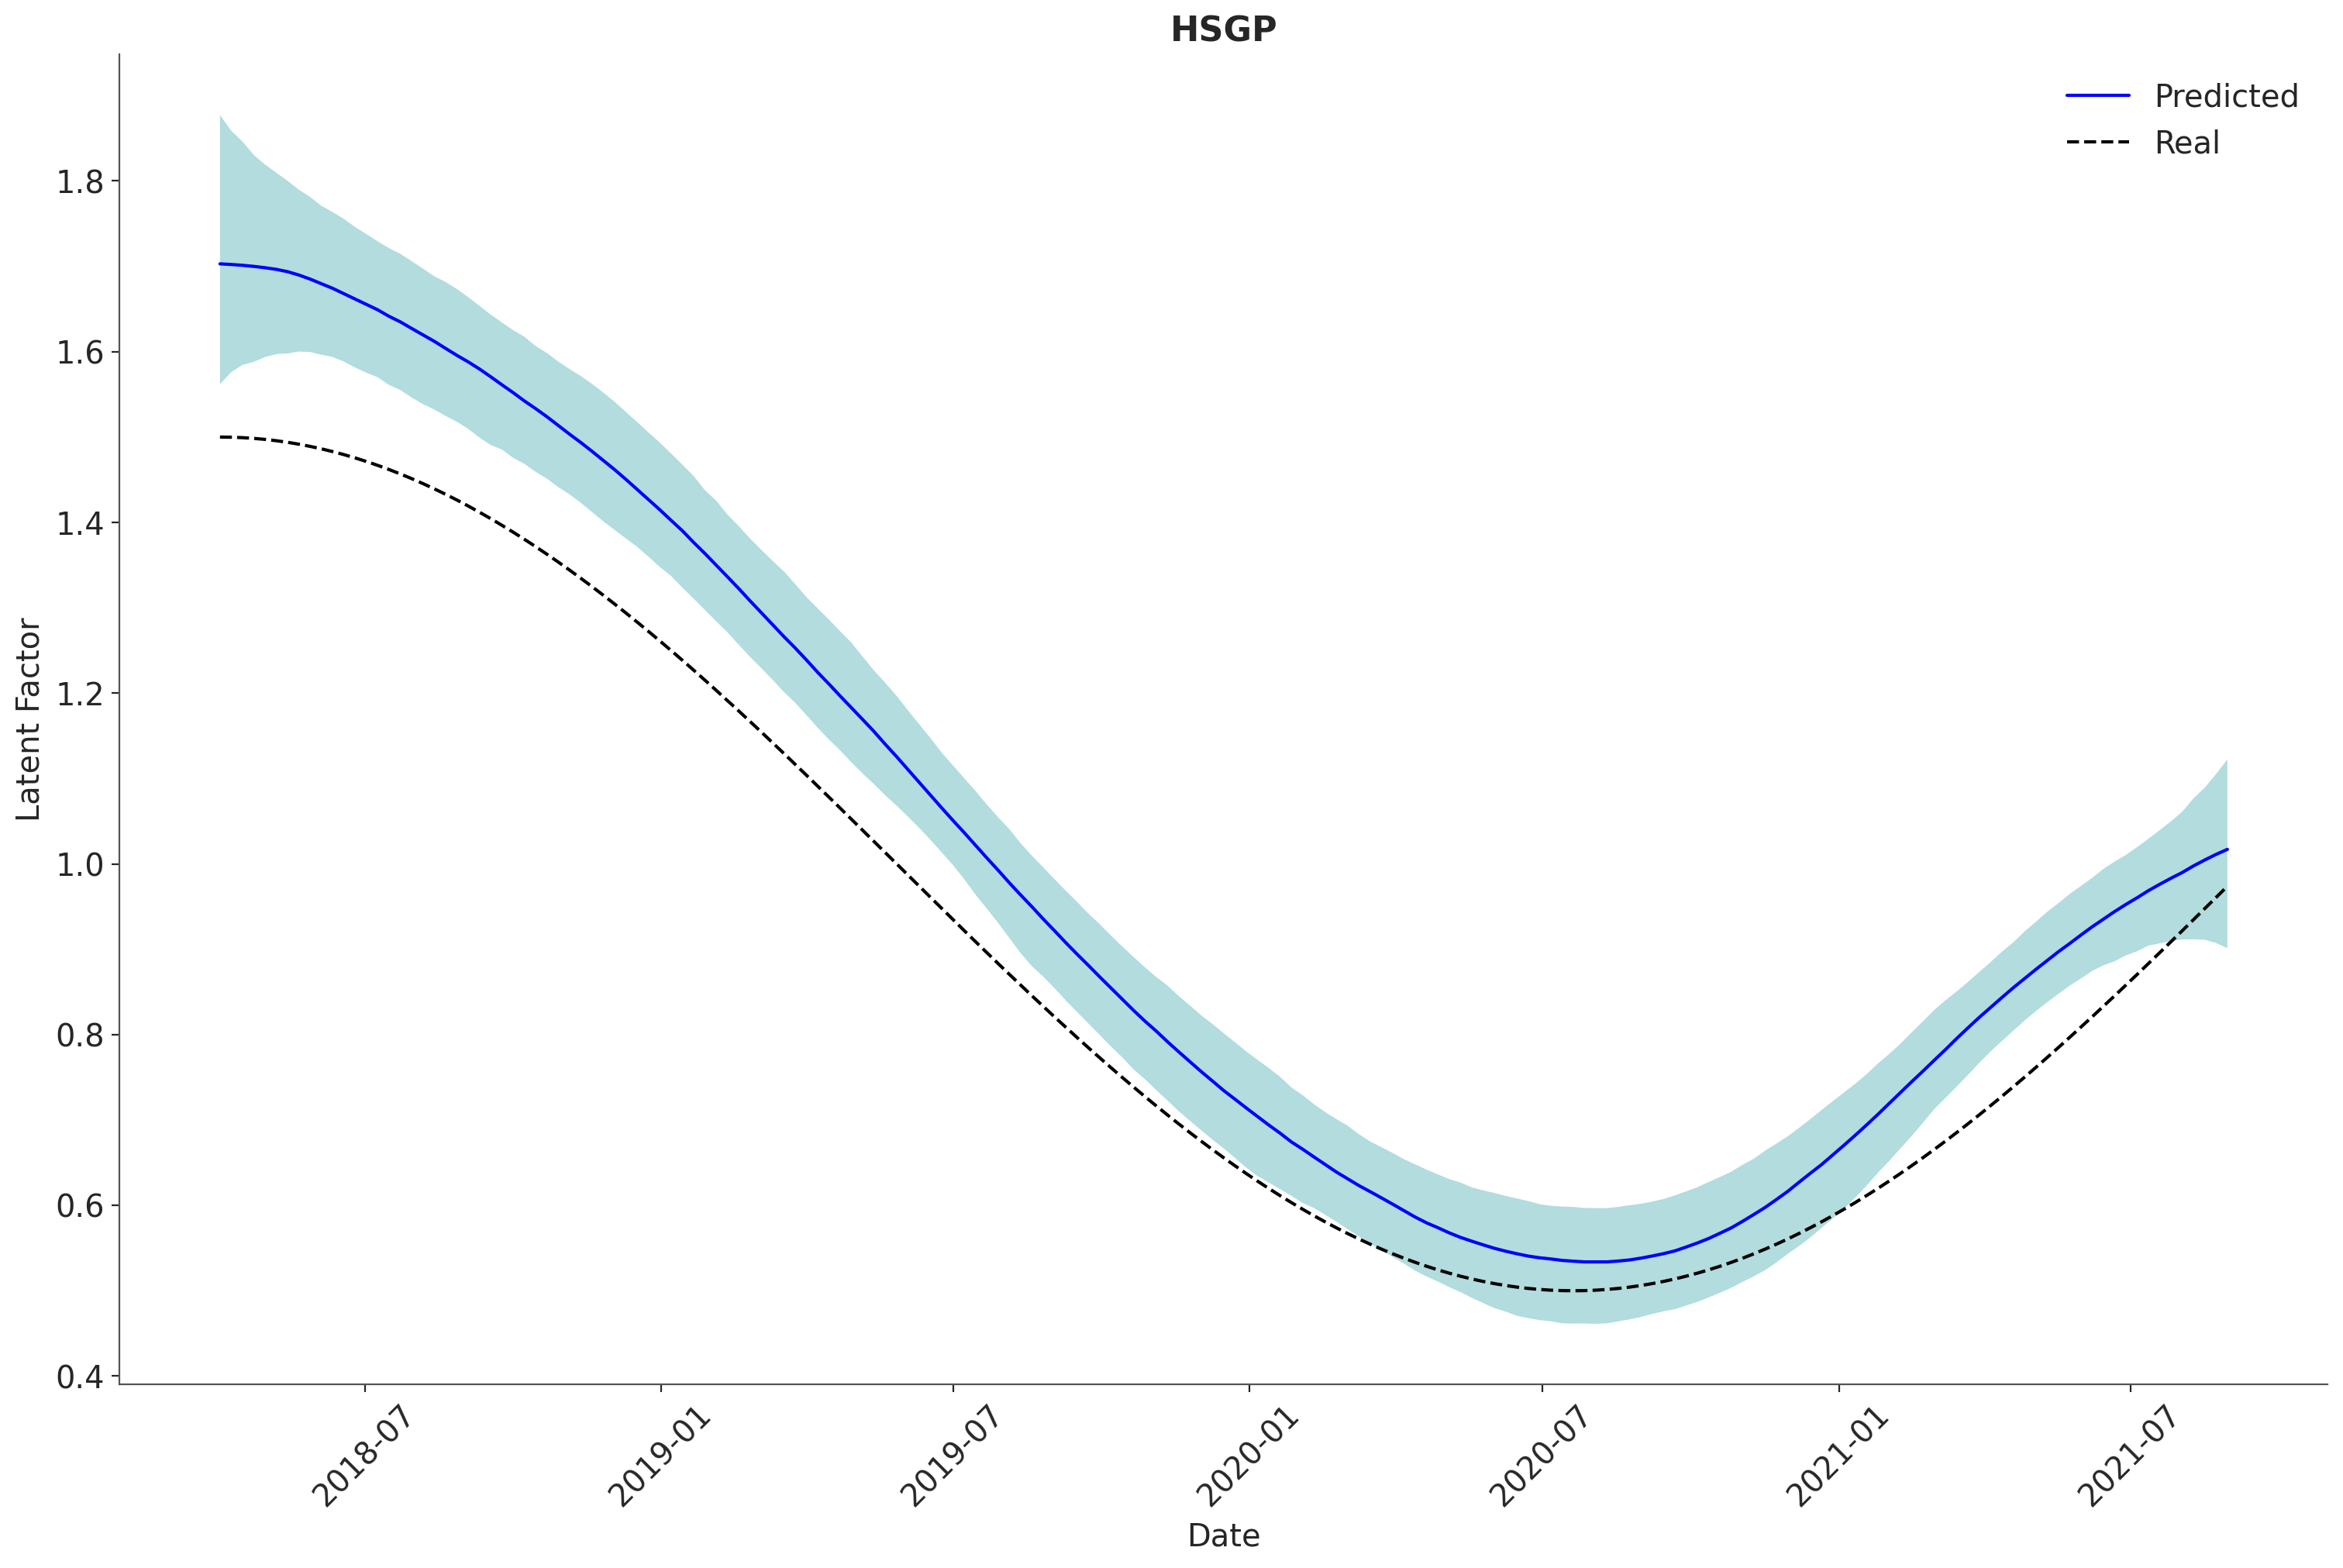

In [30]:
media_latent_factor = mmm.fit_result["media_temporal_latent_multiplier"].quantile(
    [0.025, 0.50, 0.975], dim=["chain", "draw"]
)
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(15, 10))
sns.lineplot(
    x=mmm.fit_result.coords["date"],
    y=media_latent_factor.sel(quantile=0.5),
    label="Predicted",
    color="blue",
)
sns.lineplot(
    x=mmm.fit_result.coords["date"],
    y=df["hidden_latent_media_fluctuation"],
    label="Real",
    color="Black",
    linestyle="--",
)
ax.fill_between(
    mmm.fit_result.coords["date"],
    media_latent_factor.sel(quantile=0.025),
    media_latent_factor.sel(quantile=0.975),
    alpha=0.3,
)
ax.set_title("HSGP")
ax.set_xlabel("Date")
ax.set_ylabel("Latent Factor")
ax.tick_params(axis="x", rotation=45)
ax.legend()
plt.show()

Incredible 🚀 we recovered the latent process almost perfectly. Although it seems a little overestimated, it is quite close to the real thing!


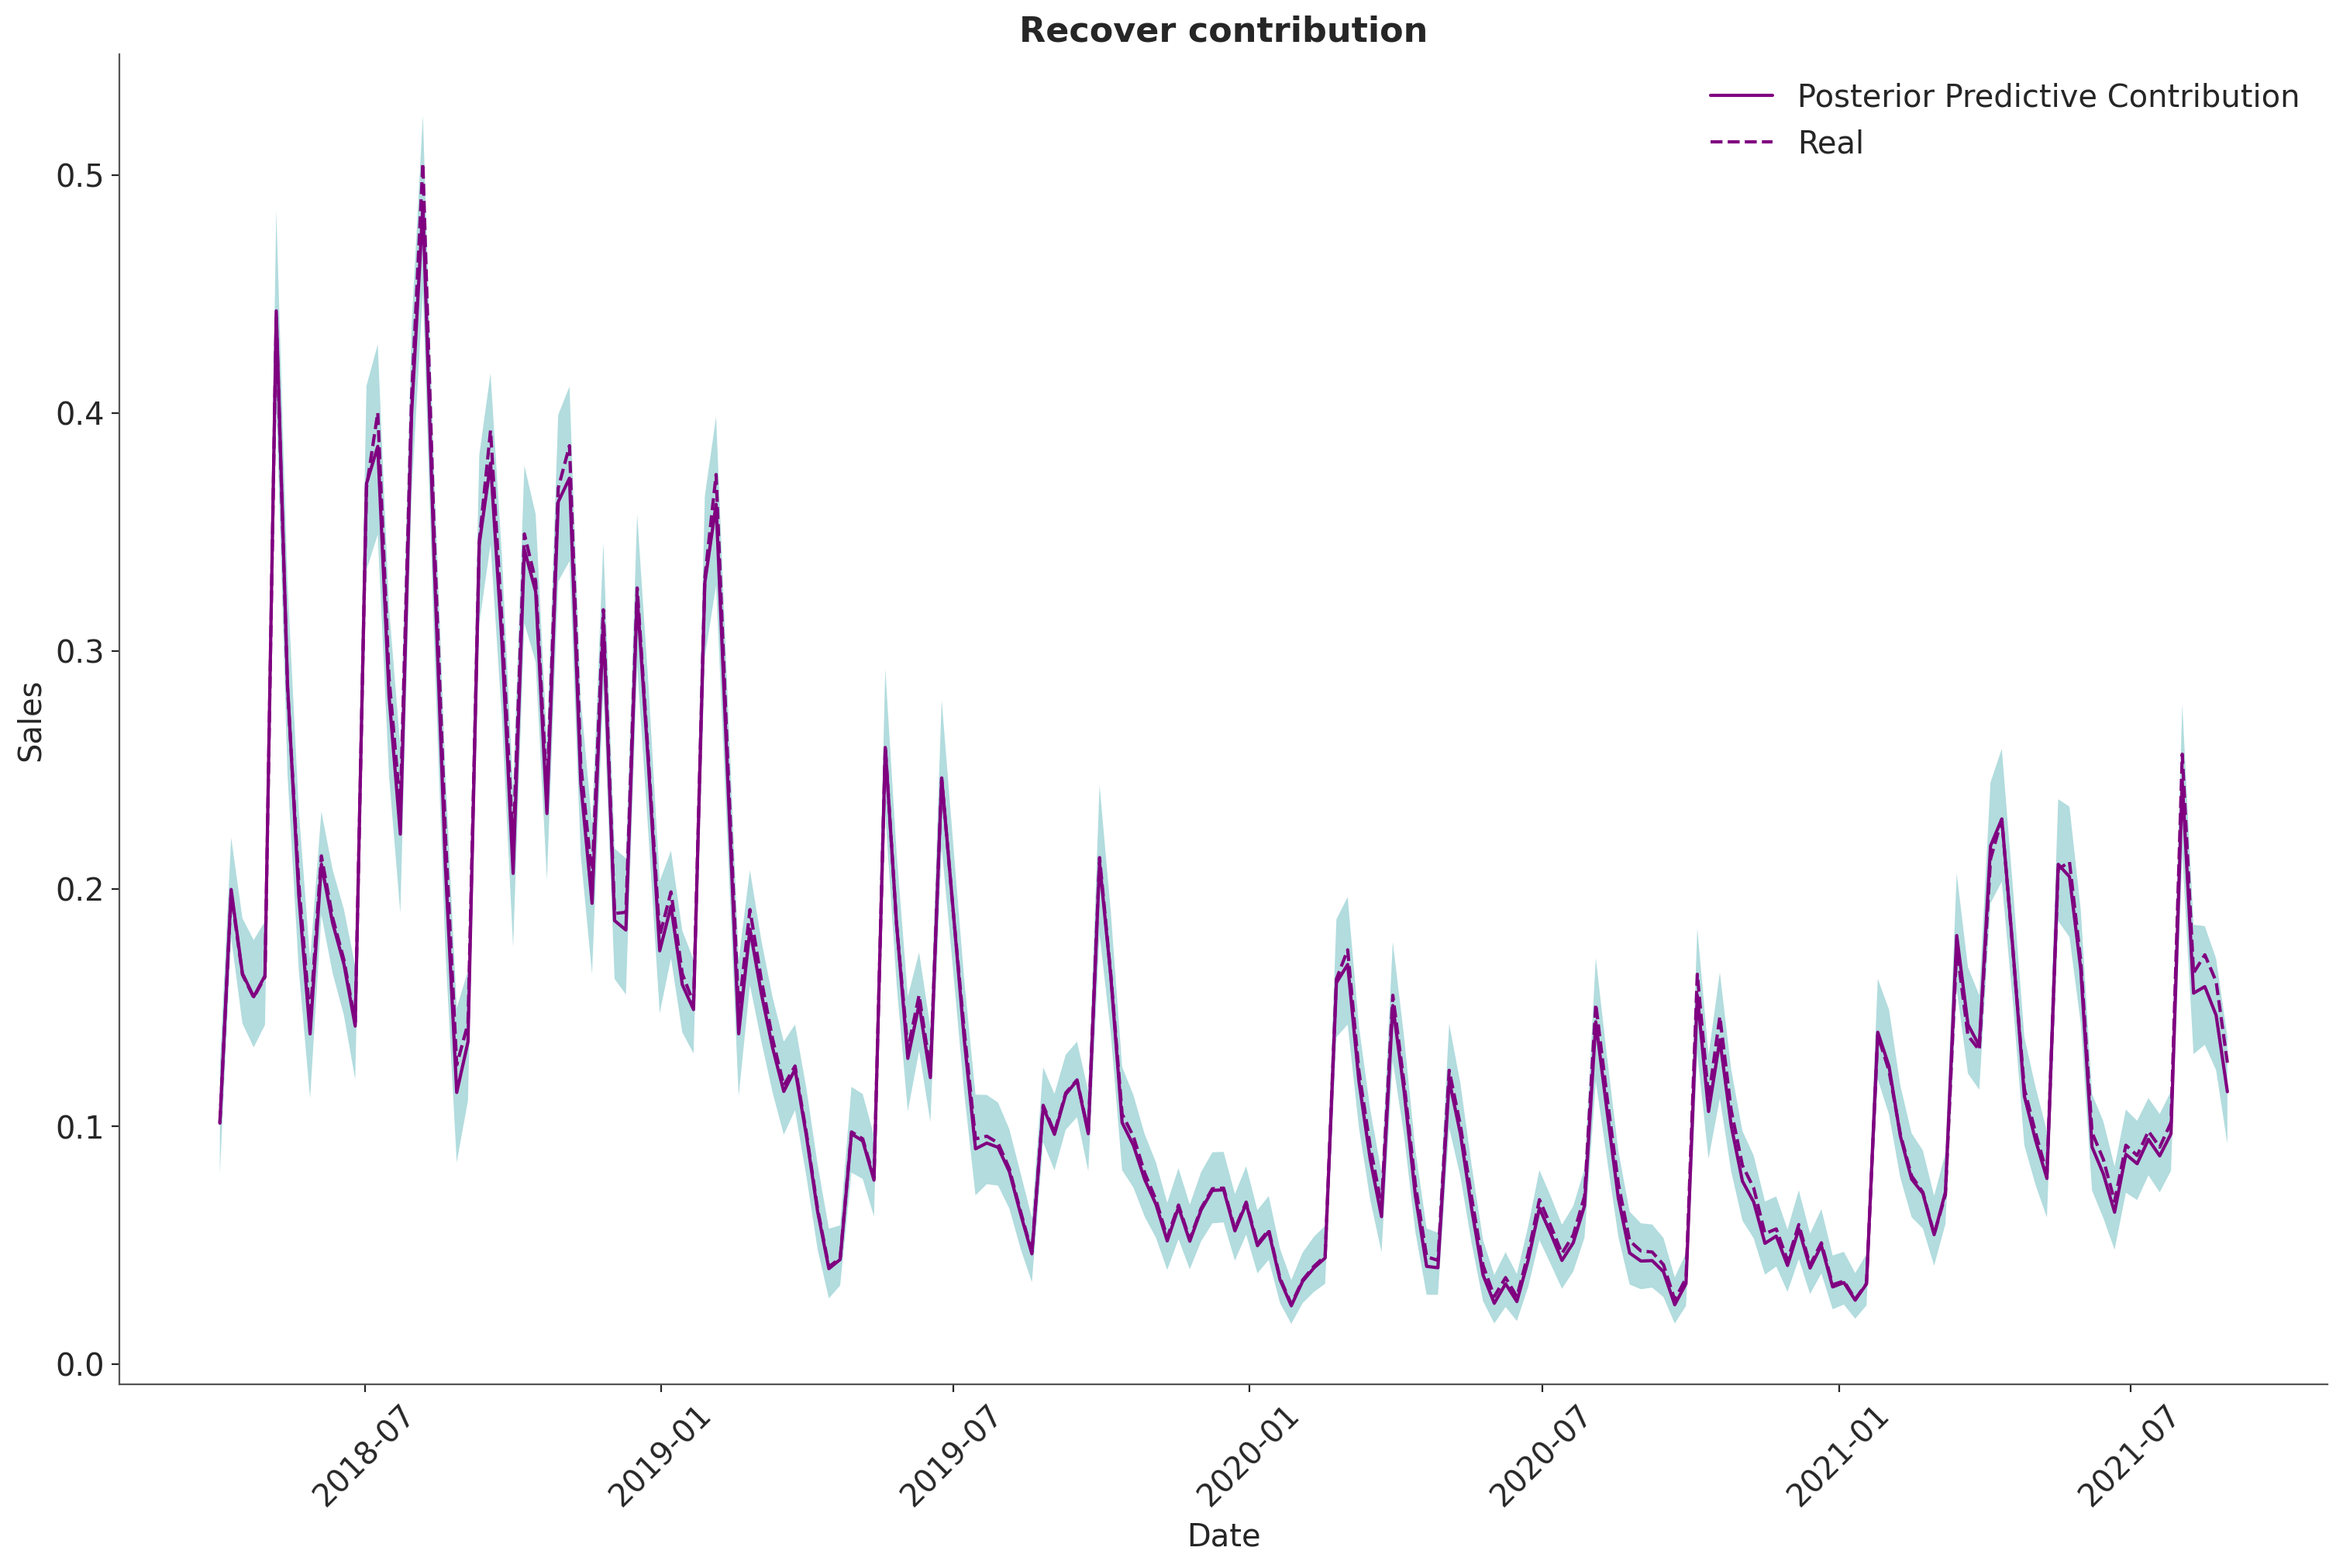

In [31]:
recover_channel_contribution = mmm.fit_result["channel_contribution"].quantile(
    [0.025, 0.50, 0.975], dim=["chain", "draw"]
)
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(15, 10))
sns.lineplot(
    x=mmm.fit_result.coords["date"],
    y=recover_channel_contribution.sel(quantile=0.5).sum(axis=-1),
    label="Posterior Predictive Contribution",
    color="purple",
)
sns.lineplot(
    x=mmm.fit_result.coords["date"],
    y=df["channel_contribution"] / df["y"].max(),
    label="Real",
    color="purple",
    linestyle="--",
)
ax.fill_between(
    mmm.fit_result.coords["date"],
    recover_channel_contribution.sel(quantile=0.025).sum(axis=-1),
    recover_channel_contribution.sel(quantile=0.975).sum(axis=-1),
    alpha=0.3,
)
ax.set_title("Recover contribution")
ax.set_xlabel("Date")
ax.set_ylabel("Sales")
ax.tick_params(axis="x", rotation=45)
ax.legend()
plt.show()

This is reflected when comparing the recovered contribution against the original. We can see that they are exactly the same!


We can compare now the contributions split by channel between our two models.        


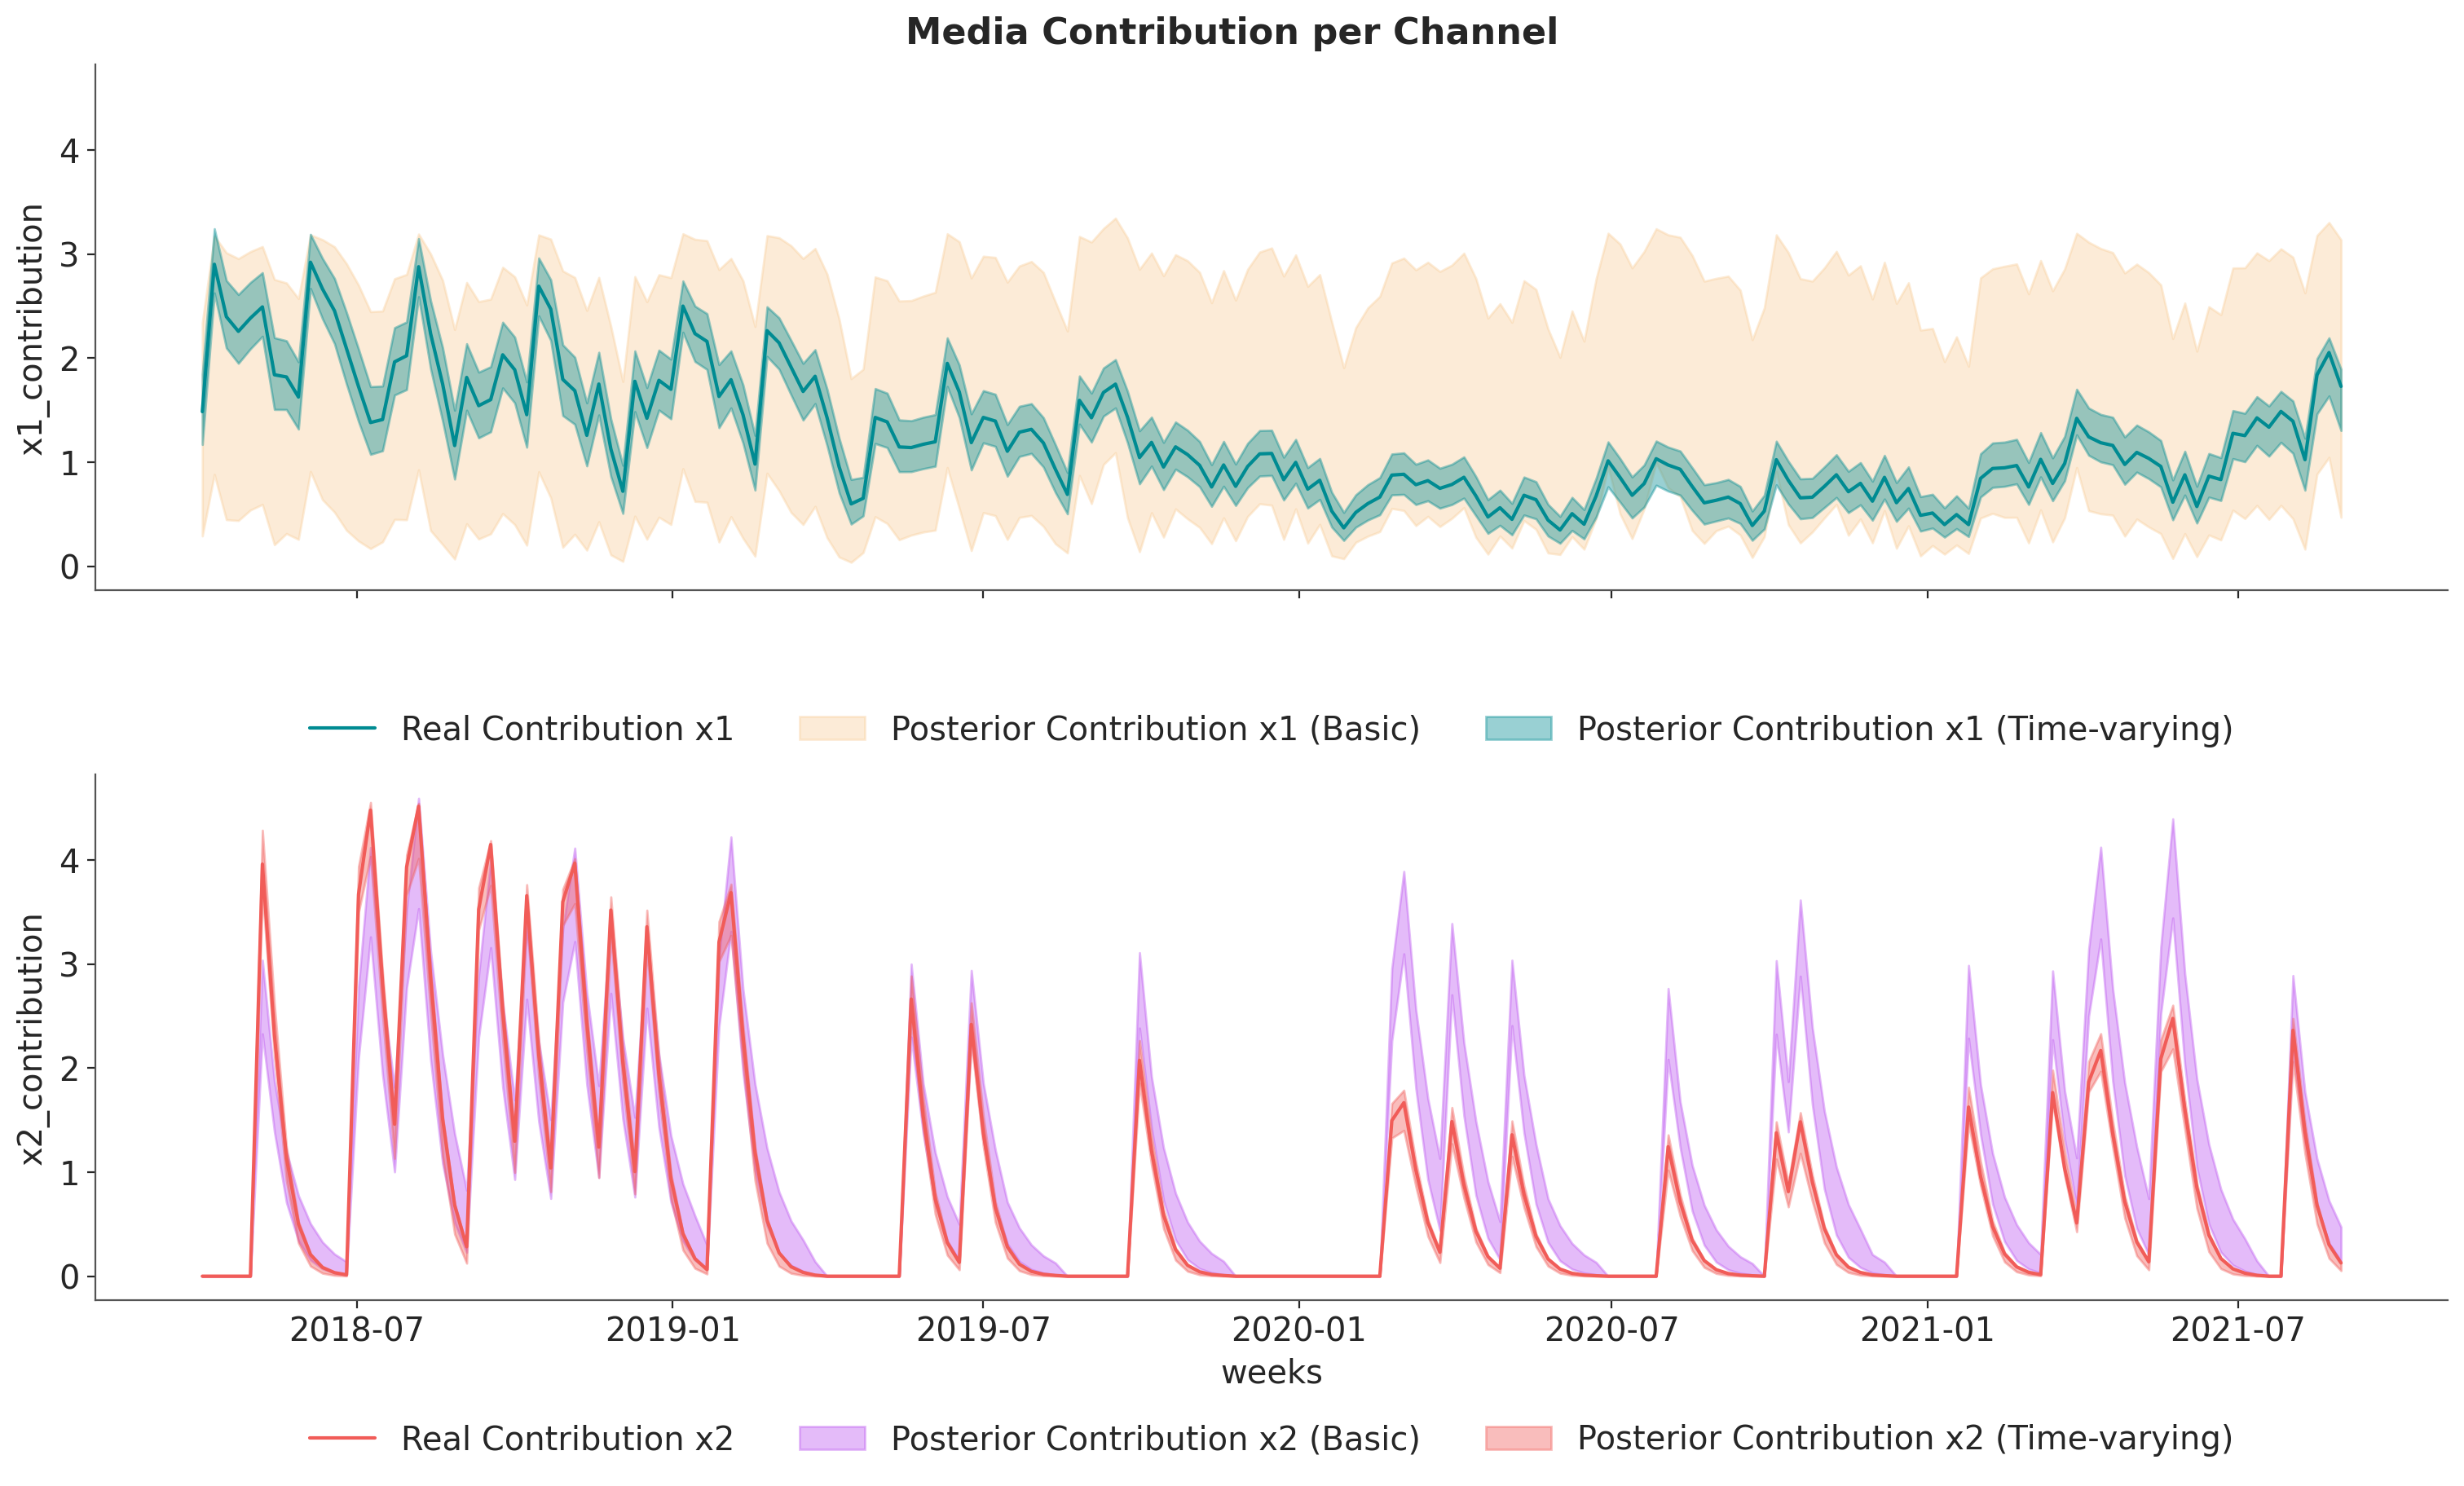

In [32]:
basic_recover_channel_contribution = basic_mmm.fit_result[
    "channel_contribution"
].quantile([0.025, 0.50, 0.975], dim=["chain", "draw"])
fig, ax = plt.subplots(
    nrows=2, ncols=1, figsize=(15, 9), sharex=True, sharey=True, layout="constrained"
)
sns.lineplot(
    x="date_week",
    y="x1_contribution",
    data=df,
    color="C0",
    ax=ax[0],
    label="Real Contribution x1",
)
ax[0].fill_between(
    basic_mmm.fit_result.coords["date"],
    basic_recover_channel_contribution.sel(quantile=0.025).sel(channel="x1")
    * df.y.max(),
    basic_recover_channel_contribution.sel(quantile=0.975).sel(channel="x1")
    * df.y.max(),
    alpha=0.4,
    color="C5",
    label="Posterior Contribution x1 (Basic)",
)
ax[0].fill_between(
    mmm.fit_result.coords["date"],
    recover_channel_contribution.sel(quantile=0.025).sel(channel="x1") * df.y.max(),
    recover_channel_contribution.sel(quantile=0.975).sel(channel="x1") * df.y.max(),
    alpha=0.4,
    color="C0",
    label="Posterior Contribution x1 (Time-varying)",
)
ax[0].legend(bbox_to_anchor=(0.5, -0.18), loc="upper center", ncols=3)
sns.lineplot(
    x="date_week",
    y="x2_contribution",
    data=df,
    color="C1",
    ax=ax[1],
    label="Real Contribution x2",
)
ax[1].fill_between(
    basic_mmm.fit_result.coords["date"],
    basic_recover_channel_contribution.sel(quantile=0.025).sel(channel="x2")
    * df.y.max(),
    basic_recover_channel_contribution.sel(quantile=0.975).sel(channel="x2")
    * df.y.max(),
    alpha=0.4,
    color="C3",
    label="Posterior Contribution x2 (Basic)",
)
ax[1].fill_between(
    mmm.fit_result.coords["date"],
    recover_channel_contribution.sel(quantile=0.025).sel(channel="x2") * df.y.max(),
    recover_channel_contribution.sel(quantile=0.975).sel(channel="x2") * df.y.max(),
    alpha=0.4,
    color="C1",
    label="Posterior Contribution x2 (Time-varying)",
)
ax[1].set(xlabel="weeks")
fig.suptitle("Media Contribution per Channel", fontsize=16)
ax[1].legend(bbox_to_anchor=(0.5, -0.18), loc="upper center", ncols=3);

Contributions per channel were also recovered correctly, unlike our first model! Actually, we see how the base model tries (and fails!) to capture the true variation. The reason is clear: lack of flexibility.


## Insights
The Bayesian approach not only facilitates hypothesis testing and model validation but also provides a structured way to incorporate prior knowledge and test various assumptions about the data-generating process. The occurrence of divergences, as observed in our initial model fitting, underscores the importance of model specification and alignment with the underlying data structure. These divergences serve as a diagnostic tool, guiding further refinement and improvement of the model.
In summary, using PyMC-Marketing to build time-aware MMM models enables marketers to gain deeper insights and achieve a more accurate understanding of the impact of their efforts. This methodology enhances the ability to make data-driven decisions, optimize marketing strategies, and ultimately drive better business outcomes.
## Conclusion
Throughout this notebook, we have explored the implementation of a Bayesian Marketing Mix Model (MMM) using PyMC, comparing the performance and insights gained from models with and without a time component. The key takeaway from our analysis is the significant advantage of incorporating time-varying factors into MMM. 
## Uncovering Real Causal Relationships
By integrating a time component, we can uncover the true causal relationships between our target variable (such as sales) and our marketing efforts. The traditional approach, which neglects temporal dynamics, often fails to capture the complex and fluctuating nature of real-world marketing performance. In contrast, the time-dependent model provides a more accurate and nuanced understanding of how marketing activities influence outcomes over time. 
## Advantages of PyMC-Marketing
PyMC-Marketing, offers powerful tools to implement these advanced methodologies. The new features and functionalities, including the handling differents adstock effects, saturation effects, and Hilbert Space Gaussian processes (HSGP) for modeling time-varying components, allow for more precise and reliable modeling of marketing data. 
We encourage practitioners to leverage these advanced techniques and the capabilities of PyMC-Marketing to improve their marketing analytics and gain a competitive edge in their strategic planning.


## Bonus
This notebook simulated a very simple variation, it is possible that the true time-dependent latent processes hidden in your data are more complex therefore, you will need to use `priors` to guide your model to find the real data.
One way to achieve this is through modifying the model configuration.


In [33]:
custom_config = {
    "intercept": Prior("HalfNormal", sigma=0.5),
    "saturation_alpha": Prior(
        "Gamma", mu=np.array([0.3, 0.4]), sigma=np.array([0.2, 0.2]), dims="channel"
    ),
    "saturation_lam": Prior("Beta", alpha=4, beta=4, dims="channel"),
}
media_tvp_config = {
    "media_tvp_config": {
        "m": 50,
        "L": 30,
        "eta_lam": 3,
        "ls_mu": 5,
        "ls_sigma": 5,
        "cov_func": None,
    }
}
custom_config = {**mmm.model_config, **custom_config, **media_tvp_config}
custom_config

{'intercept': Prior("HalfNormal", sigma=0.5),
 'likelihood': Prior("Normal", sigma=Prior("HalfNormal", sigma=2, dims=()), dims="date"),
 'gamma_control': Prior("Normal", mu=0, sigma=2, dims="control"),
 'gamma_fourier': Prior("Laplace", mu=0, b=1, dims="fourier_mode"),
 'media_tvp_config': {'m': 50,
  'L': 30,
  'eta_lam': 3,
  'ls_mu': 5,
  'ls_sigma': 5,
  'cov_func': None},
 'adstock_alpha': Prior("Beta", alpha=1, beta=3, dims="channel"),
 'saturation_alpha': Prior("Gamma", mu=[0.3 0.4], sigma=[0.2 0.2], dims="channel"),
 'saturation_lam': Prior("Beta", alpha=4, beta=4, dims="channel")}

In [34]:
mmm_calibrated = MMM(
    date_column="date_week",
    target_column="y",
    channel_columns=["x1", "x2"],
    control_columns=["event_1", "event_2"],
    yearly_seasonality=yearly_seasonality,
    adstock=GeometricAdstock(l_max=adstock_max_lag),
    saturation=MichaelisMentenSaturation(),
    time_varying_media=True,
    model_config=custom_config,
)

In [35]:
%load_ext watermark
%watermark -n -u -v -iv -w -p pymc,pymc_marketing,pytensor,numpyro

Last updated: Wed, 08 Jul 2026

Python implementation: CPython
Python version       : 3.13.9
IPython version      : 9.15.0

pymc          : 6.0.1
pymc_marketing: 1.0.0.dev0
pytensor      : 3.0.7
numpyro       : 0.21.0

arviz         : 1.2.0
arviz_base    : 1.2.0
arviz_plots   : 1.2.0
matplotlib    : 3.10.9
numpy         : 2.4.6
pandas        : 2.3.3
pymc_extras   : 0.12.2.dev1+gee8cc37df
pymc_marketing: 1.0.0.dev0
seaborn       : 0.13.2

Watermark: 2.6.0

